# Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler, LabelEncoder
import umap
import os
from matplotlib.lines import Line2D
import numpy as np

c:\Users\tjwil\anaconda3\envs\opto\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# UMAP Figure Code

Successfully loaded 'fitted_data/fitted_data_final_no_err_S2N_wide.csv'.
Particle types have been renamed.
Data has been scaled.
Generating plots for neighbor values: [5, 10, 20, 30, 40, 50]...
  -> Running UMAP with n_neighbors=5


c:\Users\tjwil\anaconda3\envs\opto\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  -> Running UMAP with n_neighbors=10


c:\Users\tjwil\anaconda3\envs\opto\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  -> Running UMAP with n_neighbors=20


...

c:\Users\tjwil\anaconda3\envs\opto\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  -> Running UMAP with n_neighbors=40


c:\Users\tjwil\anaconda3\envs\opto\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  -> Running UMAP with n_neighbors=50


c:\Users\tjwil\anaconda3\envs\opto\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


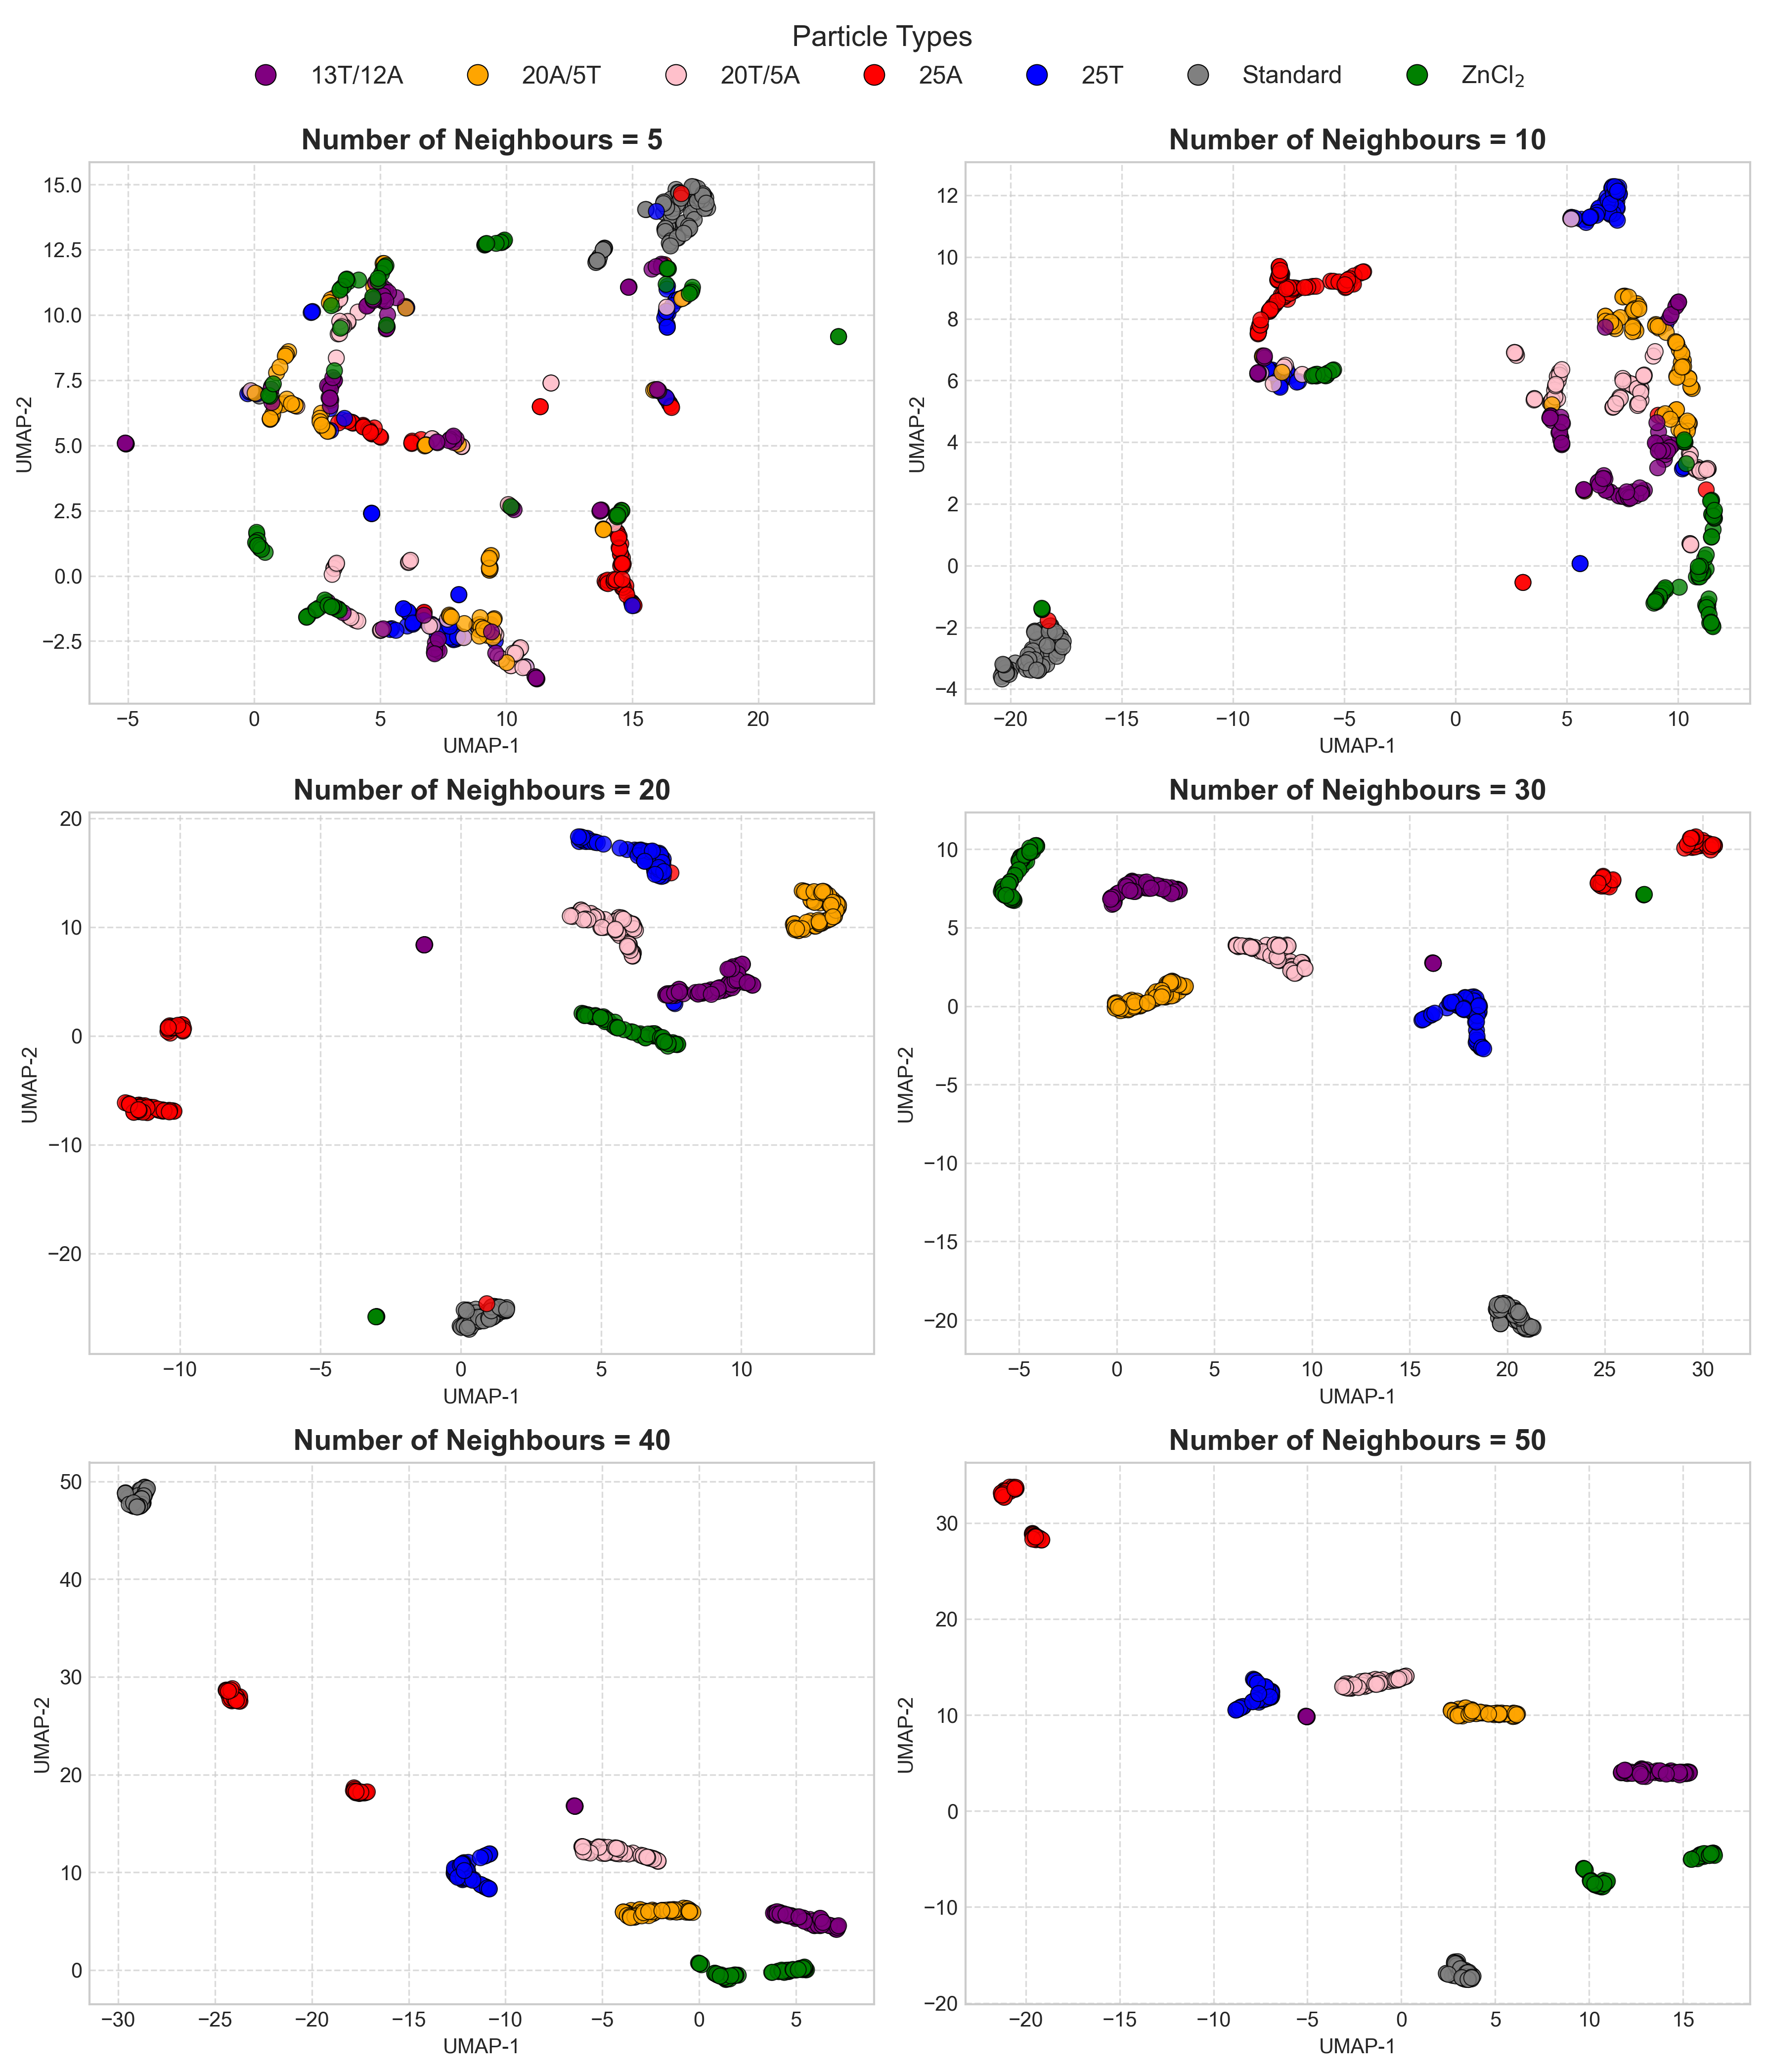

In [6]:
def plot_supervised_umap_grid(input_filepath):
    """
    Loads cleaned data, RENAMES particle types, and performs supervised UMAP 
    with varying n_neighbors, plotting a 3x2 grid of visualizations.
    Legend is placed at the TOP with reduced whitespace.
    """
    # --- 1. File Loading and Safety Checks ---
    try:
        if not os.path.exists(input_filepath):
            base_filename = os.path.basename(input_filepath)
            print(f"Warning: '{input_filepath}' not found.")
            if os.path.exists(base_filename):
                print(f"Found '{base_filename}' in the current directory, using that instead.")
                input_filepath = base_filename
            else:
                print(f"Error: Could not find '{base_filename}' either.")
                return

        df = pd.read_csv(input_filepath)
        print(f"Successfully loaded '{input_filepath}'.")

    except FileNotFoundError:
        print(f"Error: The file '{input_filepath}' was not found.")
        return
    except Exception as e:
        print(f"An error occurred while loading the file: {e}")
        return
        
    if 'Particle Type' not in df.columns:
        print("Error: 'Particle Type' column not found. Cannot proceed with supervision.")
        return
        
    # Drop rows where 'Particle Type' is missing
    df = df.dropna(subset=['Particle Type'])

    name_mapping = {
        "Standard SiNP": "Standard",
        "25A 1000uM ZnCl2 SiNP": "25A",
        "25T 1000uM ZnCl2 SiNP": "25T",
        "20T/5A 1000uM ZnCl2 SiNP": "20T/5A",
        "20A/5T 1000uM ZnCl2 SiNP": "20A/5T",
        "13T/12A 1000uM ZnCl2 SiNP": "13T/12A",
        "1000uM ZnCl2 SiNP": "ZnCl$_2$"
    }
    # Apply the renaming
    df['Particle Type'] = df['Particle Type'].replace(name_mapping)
    print("Particle types have been renamed.")
    # ==========================================

    # --- 2. Prepare Data (Scale & Encode) ---
    particle_labels = df['Particle Type']
    
    le = LabelEncoder()
    particle_labels_encoded = le.fit_transform(particle_labels)
    
    features = df.drop(['Particle Type', 'Particle ID'], axis=1, errors='ignore').select_dtypes(include=['number'])
    
    if features.isnull().values.any():
        print("Warning: Missing values found in features. Filling with column mean.")
        features = features.fillna(features.mean())

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    print("Data has been scaled.")

    n_samples = scaled_features.shape[0]
    if n_samples <= 1:
        print("Error: Not enough data points to perform UMAP.")
        return

    # --- 3. Define Custom Color Palette ---
    color_map = {
        "Standard": "grey",
        "25A": "red",
        "25T": "blue",
        "20T/5A": "pink",
        "20A/5T": "orange",
        "13T/12A": "purple",
        "ZnCl$_2$": "green"
    }
    
    unique_labels = sorted(df['Particle Type'].unique())
    plot_palette = {label: color_map.get(label, 'black') for label in unique_labels}
    
    # --- 4. Setup Plot Grid ---
    neighbor_values = [5, 10, 20, 30, 40, 50]
    
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 14), dpi=300)
    axes = axes.flatten() 
    
    # Use seaborn whitegrid style
    plt.style.use('seaborn-v0_8-whitegrid')

    # --- 5. Loop Through Neighbors and Plot ---
    print(f"Generating plots for neighbor values: {neighbor_values}...")
    
    for i, n_val in enumerate(neighbor_values):
        print(f"  -> Running UMAP with n_neighbors={n_val}")
        
        # Run UMAP
        umap_model = umap.UMAP(
            n_neighbors=n_val,
            n_components=2, 
            random_state=42
        )
        embedding = umap_model.fit_transform(scaled_features, y=particle_labels_encoded)
        
        # Create Temp DataFrame
        plot_df = pd.DataFrame({
            'UMAP-1': embedding[:, 0],
            'UMAP-2': embedding[:, 1],
            'Particle Type': particle_labels
        })
        
        ax = axes[i]
        
        # Plot
        sns.scatterplot(
            ax=ax,
            x='UMAP-1', y='UMAP-2',
            hue='Particle Type',
            hue_order=unique_labels,
            data=plot_df,
            palette=plot_palette,
            s=60,
            alpha=0.8,
            edgecolor='black',
            linewidth=0.5,
            legend=False 
        )
        
        # EXPLICITLY TURN ON GRIDLINES
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_axisbelow(True) # Ensures grid is behind the dots
        
        ax.set_title(f'Number of Neighbours = {n_val}', fontsize=14, fontweight='bold')
        ax.set_xlabel('UMAP-1', fontsize=10)
        ax.set_ylabel('UMAP-2', fontsize=10)

    # --- 6. Create Unified Legend at TOP ---
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor=color, markersize=10, markeredgecolor='black', markeredgewidth=0.5)
        for label, color in plot_palette.items()
        if label in unique_labels 
    ]
    
    # Place legend at the very top
    fig.legend(
        handles=legend_handles,
        title="Particle Types",
        loc='upper center',          
        bbox_to_anchor=(0.5, 1), # Pushed slightly higher (0.99)
        ncol=7, 
        fontsize=12,
        title_fontsize=14,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    input_file = 'fitted_data/fitted_data_final_no_err_S2N_wide.csv'
    plot_supervised_umap_grid(input_file)

# Salzburg Boxplot and McNemar Pariwise Comparisons Figure

Data loaded successfully.


C:\Users\tjwil\AppData\Local\Temp\ipykernel_14376\845385463.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\tjwil\AppData\Local\Temp\ipykernel_14376\845385463.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_yticklabels(annotated_labels, fontsize=11)
C:\Users\tjwil\AppData\Local\Temp\ipykernel_14376\845385463.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_yticklabels(annotated_labels, fontsize=14)
C:\Users\tjwil\AppData\Local\Temp\ipykernel_14376\845385463.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


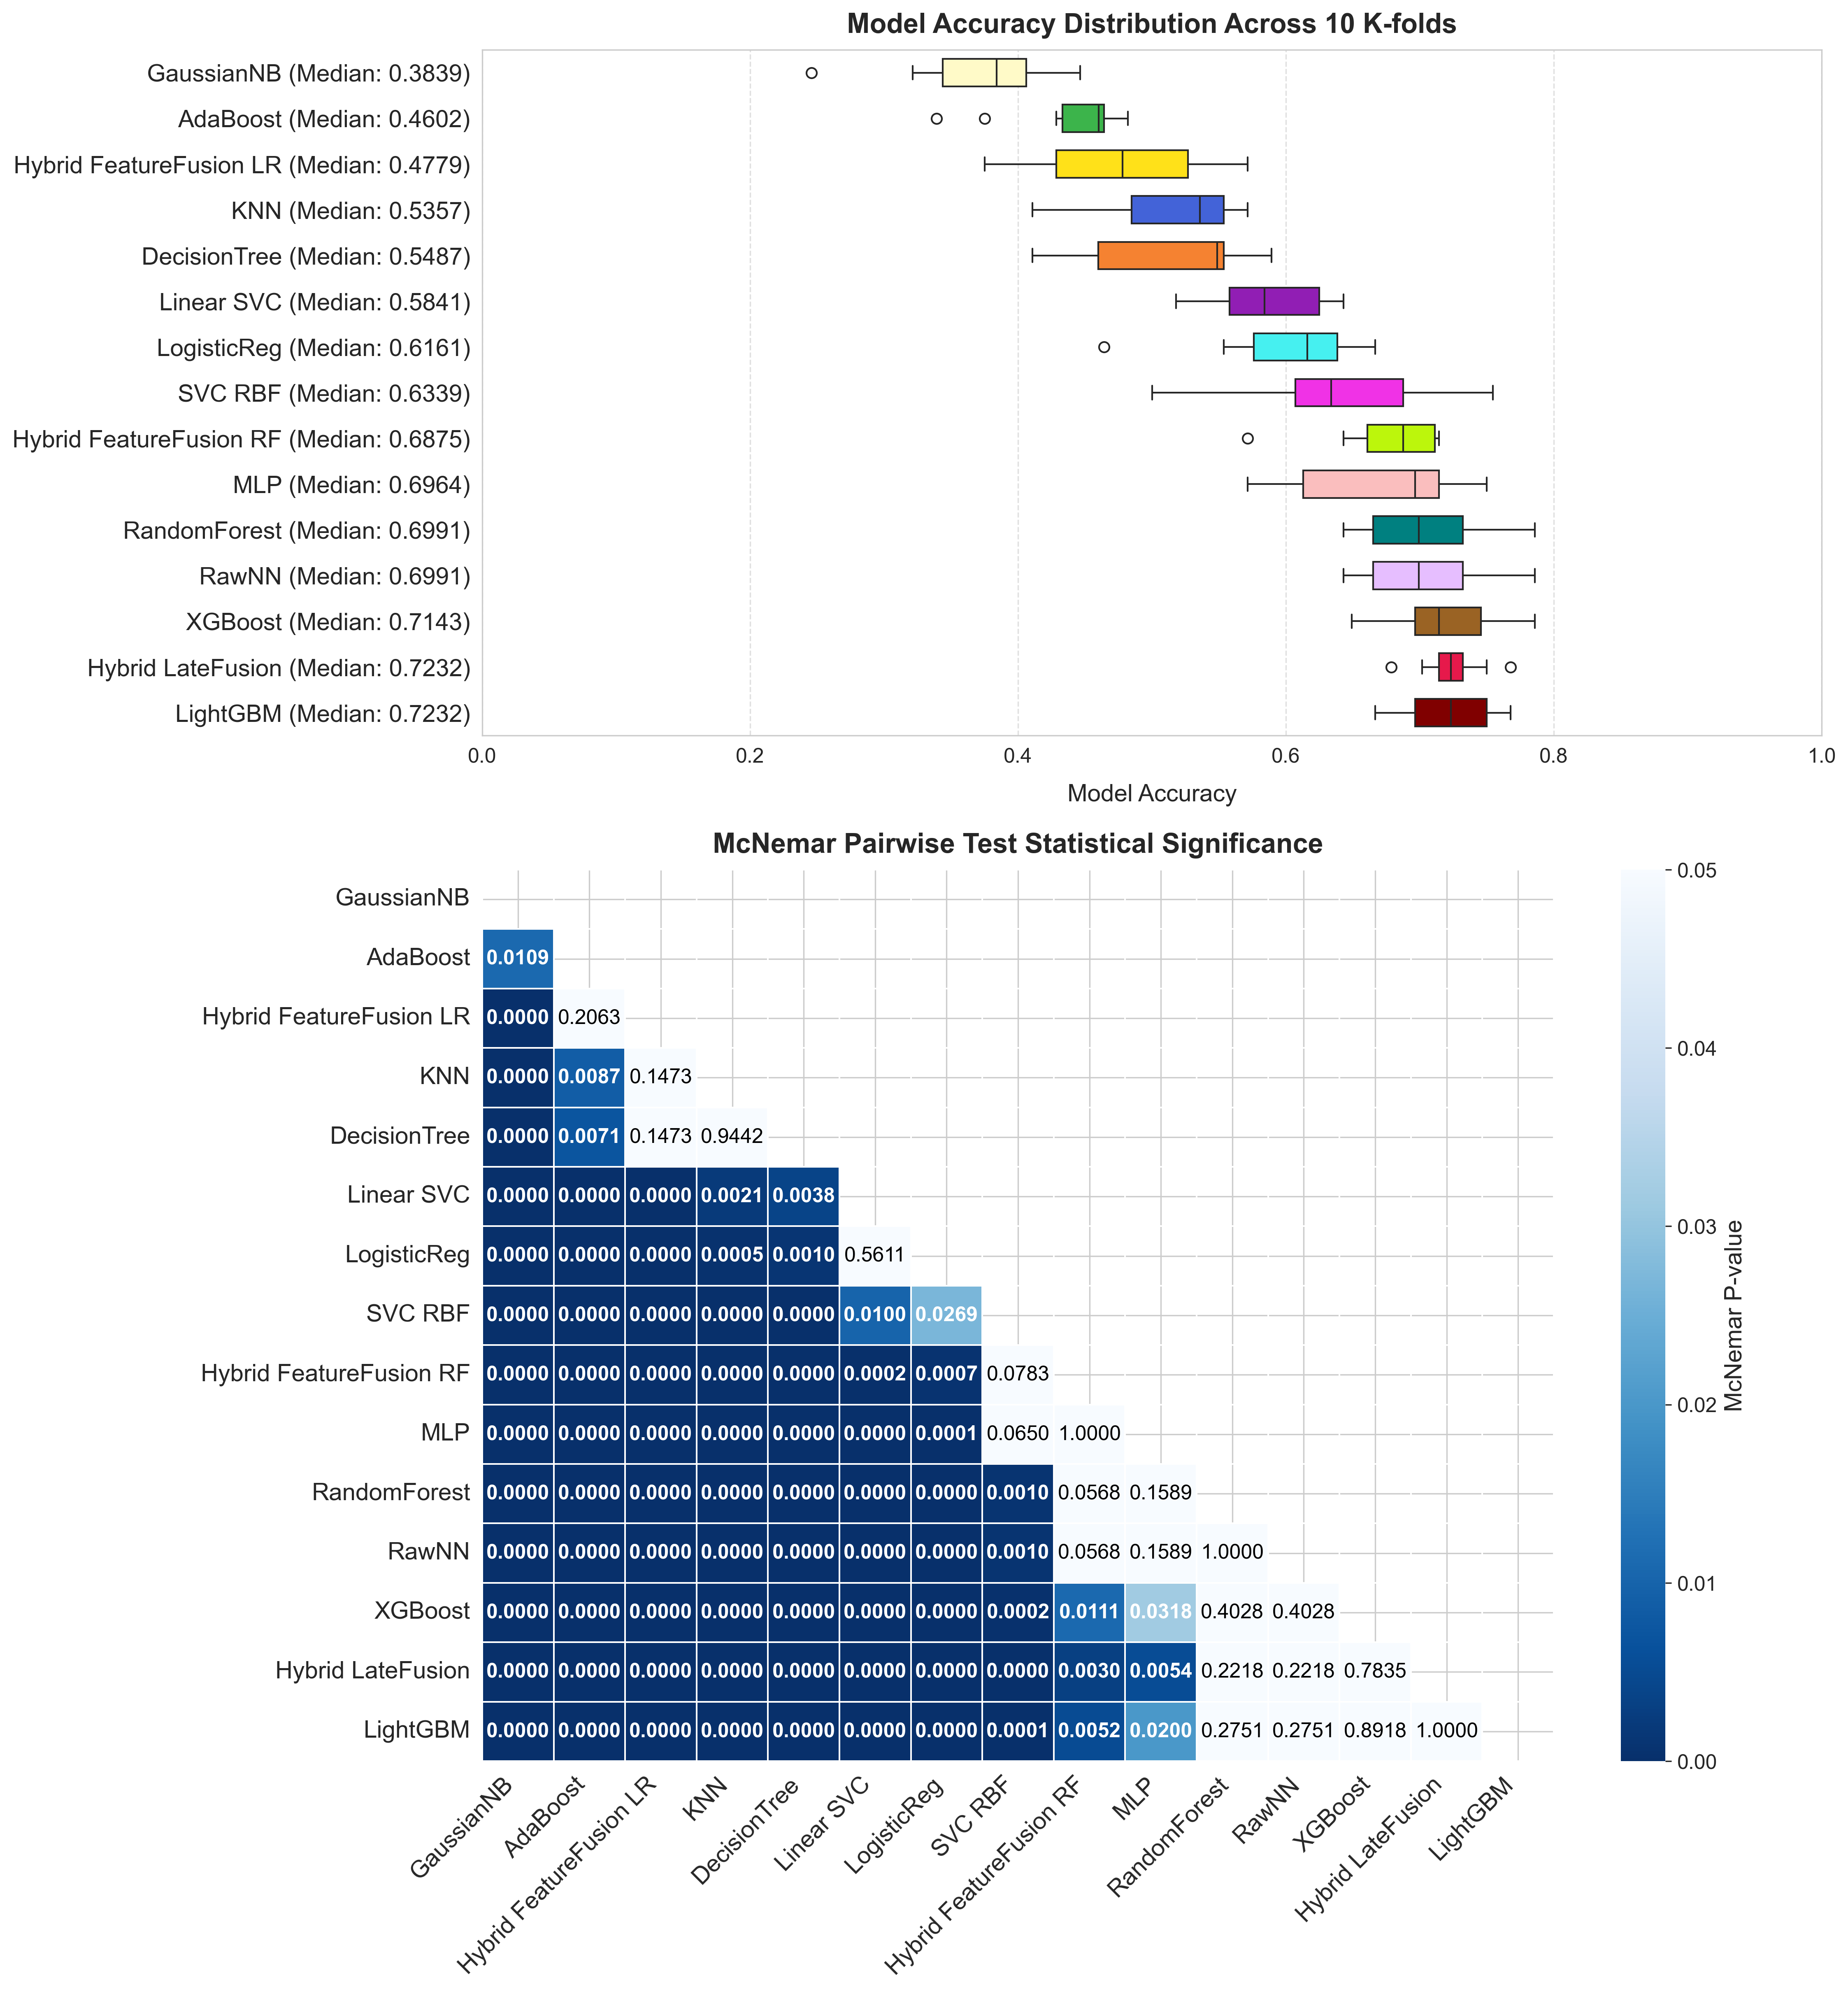

In [2]:
# --- CONFIGURATION ---
ALPHA = 0.05 # Significance threshold

# Explicitly defined distinct HEX codes
UNIQUE_HEX_PALETTE = [
    "#FFFAC8", # Beige GaussianNB #FFFAC8
    "#3CB44B", # Green AdaBoost
    "#FFE119", # Yellow Hybrid FeatureFusion LR
    "#4363D8", # Blue KNN
    "#F58231", # Orange DecisionTree
    "#911EB4", # Purple Linear SVC
    "#46F0F0", # Cyan LogisticReg
    "#F032E6", # Magenta SVC RBF
    "#BCF60C", # Lime Hybrid FeatureFusion RF
    "#FABEBE", # Pink MLP
    "#008080", # Teal RandomForest
    "#E6BEFF", # Lavender RawNN
    "#9A6324", # Brown XGBoost
    "#E6194B", # Red Hybrid LateFusion
    "#800000", # Maroon LightGBM
]

# --- DATA LOADING ---
try:
    df_acc = pd.read_csv('kfold_accuracies.csv')
    df_pvals = pd.read_csv('mcnemar_p_values.csv')
    
    if 'Unnamed: 0' in df_pvals.columns:
        df_pvals = df_pvals.set_index('Unnamed: 0')
    df_pvals.index.name = None
    
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: Input files not found.")

# --- 1. PREPARATION ---

# Boxplot Data
df_melted = df_acc.melt(var_name='model', value_name='accuracy')
median_accuracies = df_melted.groupby('model')['accuracy'].median()
sorted_model_names = median_accuracies.sort_values(ascending=True).index
annotated_labels = [f"{m} (Median: {median_accuracies[m]:.4f})" for m in sorted_model_names]

# P-value Data
common_models = [m for m in sorted_model_names if m in df_pvals.index]
p_values_matrix = df_pvals.loc[common_models, common_models]

# --- 2. VISUALIZATION ---

# Define figure
fig = plt.figure(figsize=(14, 18), dpi=300)
gs = fig.add_gridspec(2, 1, hspace=0.17, height_ratios=[1, 1.3]) 
sns.set_style("whitegrid")

# --- PLOT 1: BOXPLOT ---
ax_box = fig.add_subplot(gs[0])
palette_map = dict(zip(sorted_model_names, UNIQUE_HEX_PALETTE))

sns.boxplot(
    data=df_melted,
    x='accuracy',
    y='model',
    order=sorted_model_names,
    palette=palette_map,
    saturation=1.0, 
    width=0.6,
    orient='h',
    ax=ax_box
)

ax_box.set_yticklabels(annotated_labels, fontsize=11)
ax_box.set_xlim(0.0, 1.0)
ax_box.set_ylabel('')
ax_box.set_xlabel('Model Accuracy', fontsize=14, labelpad=10)
ax_box.set_title('Model Accuracy Distribution Across 10 K-folds', fontsize=16, fontweight='bold', pad=10)
ax_box.grid(axis='x', linestyle='--', alpha=0.6)
ax_box.set_yticklabels(annotated_labels, fontsize=14)
ax_box.tick_params(axis='x', labelsize=12)

# --- PLOT 2: HEATMAP (Triangle, Blues) ---
ax_heat = fig.add_subplot(gs[1])

# Create a mask for the upper triangle (True = hidden)
mask = np.triu(np.ones_like(p_values_matrix, dtype=bool))

sns.heatmap(
    p_values_matrix,
    mask=mask,           # Hides upper triangle
    annot=True,
    fmt=".4f",
    cmap='Blues_r',      # Dark Blue = Significant (Low p-value), White = Not significant
    vmin=0,
    vmax=ALPHA,          # Cap color scale at 0.05 to make significant values distinct
    cbar_kws={'label': 'McNemar P-value'},
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 12},
    ax=ax_heat
)

for text in ax_heat.texts:
    try:
        val_text = text.get_text()
        if val_text and val_text != 'nan':
            p_val = float(val_text)
            if p_val < ALPHA:
                text.set_weight('bold')
                text.set_color('white') # White text on dark blue background
            else:
                text.set_color('black') # Black text on light/white background
    except ValueError:
        pass

ax_heat.set_yticklabels(common_models, rotation=0, fontsize=14)
ax_heat.set_xticklabels(common_models, rotation=45, ha='right', fontsize=14)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('')
ax_heat.set_title('McNemar Pairwise Test Statistical Significance', fontsize=16, fontweight='bold', pad=10)
cbar = ax_heat.collections[0].colorbar
cbar.set_label('McNemar P-value', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

# Confusion Matrix Plots

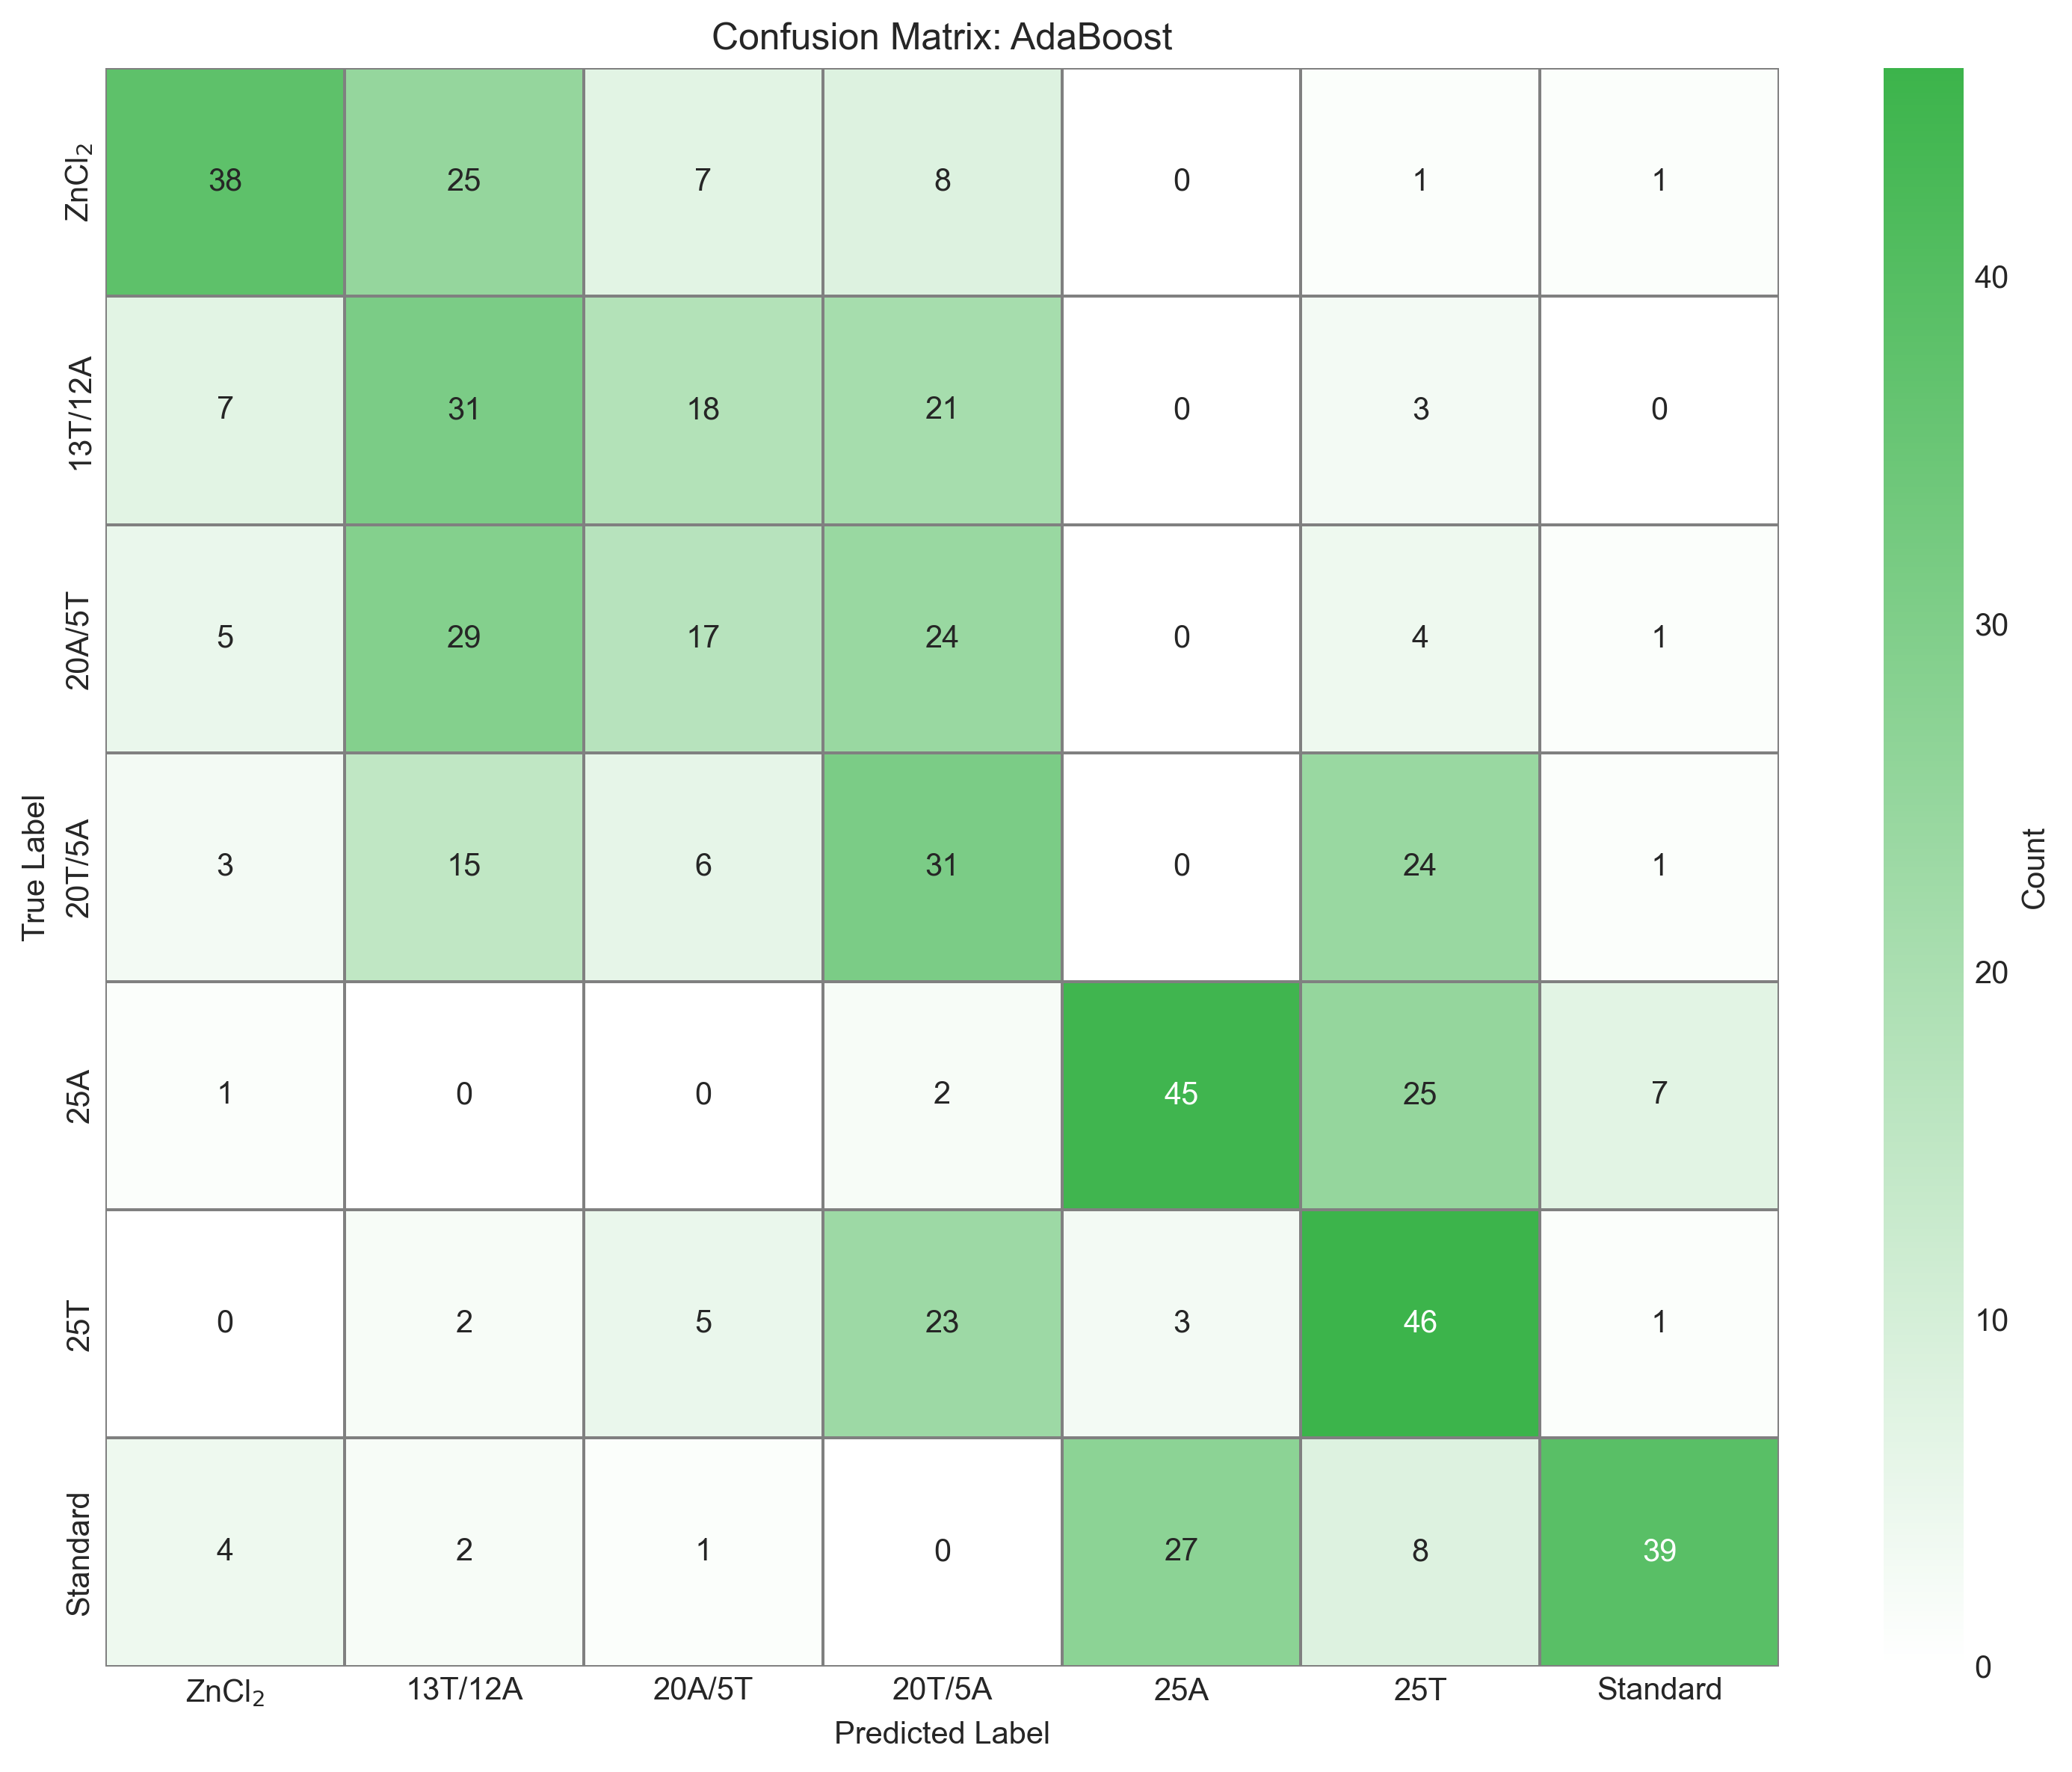

In [4]:
df = pd.read_csv("confusion_matrices/AdaBoost_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#3CB44B' 
custom_colors = ["#FFFFFF", darkest_color_hex] # Gradient from white to your darkest color
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

# Use the custom colormap
cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: AdaBoost')
plt.tight_layout()

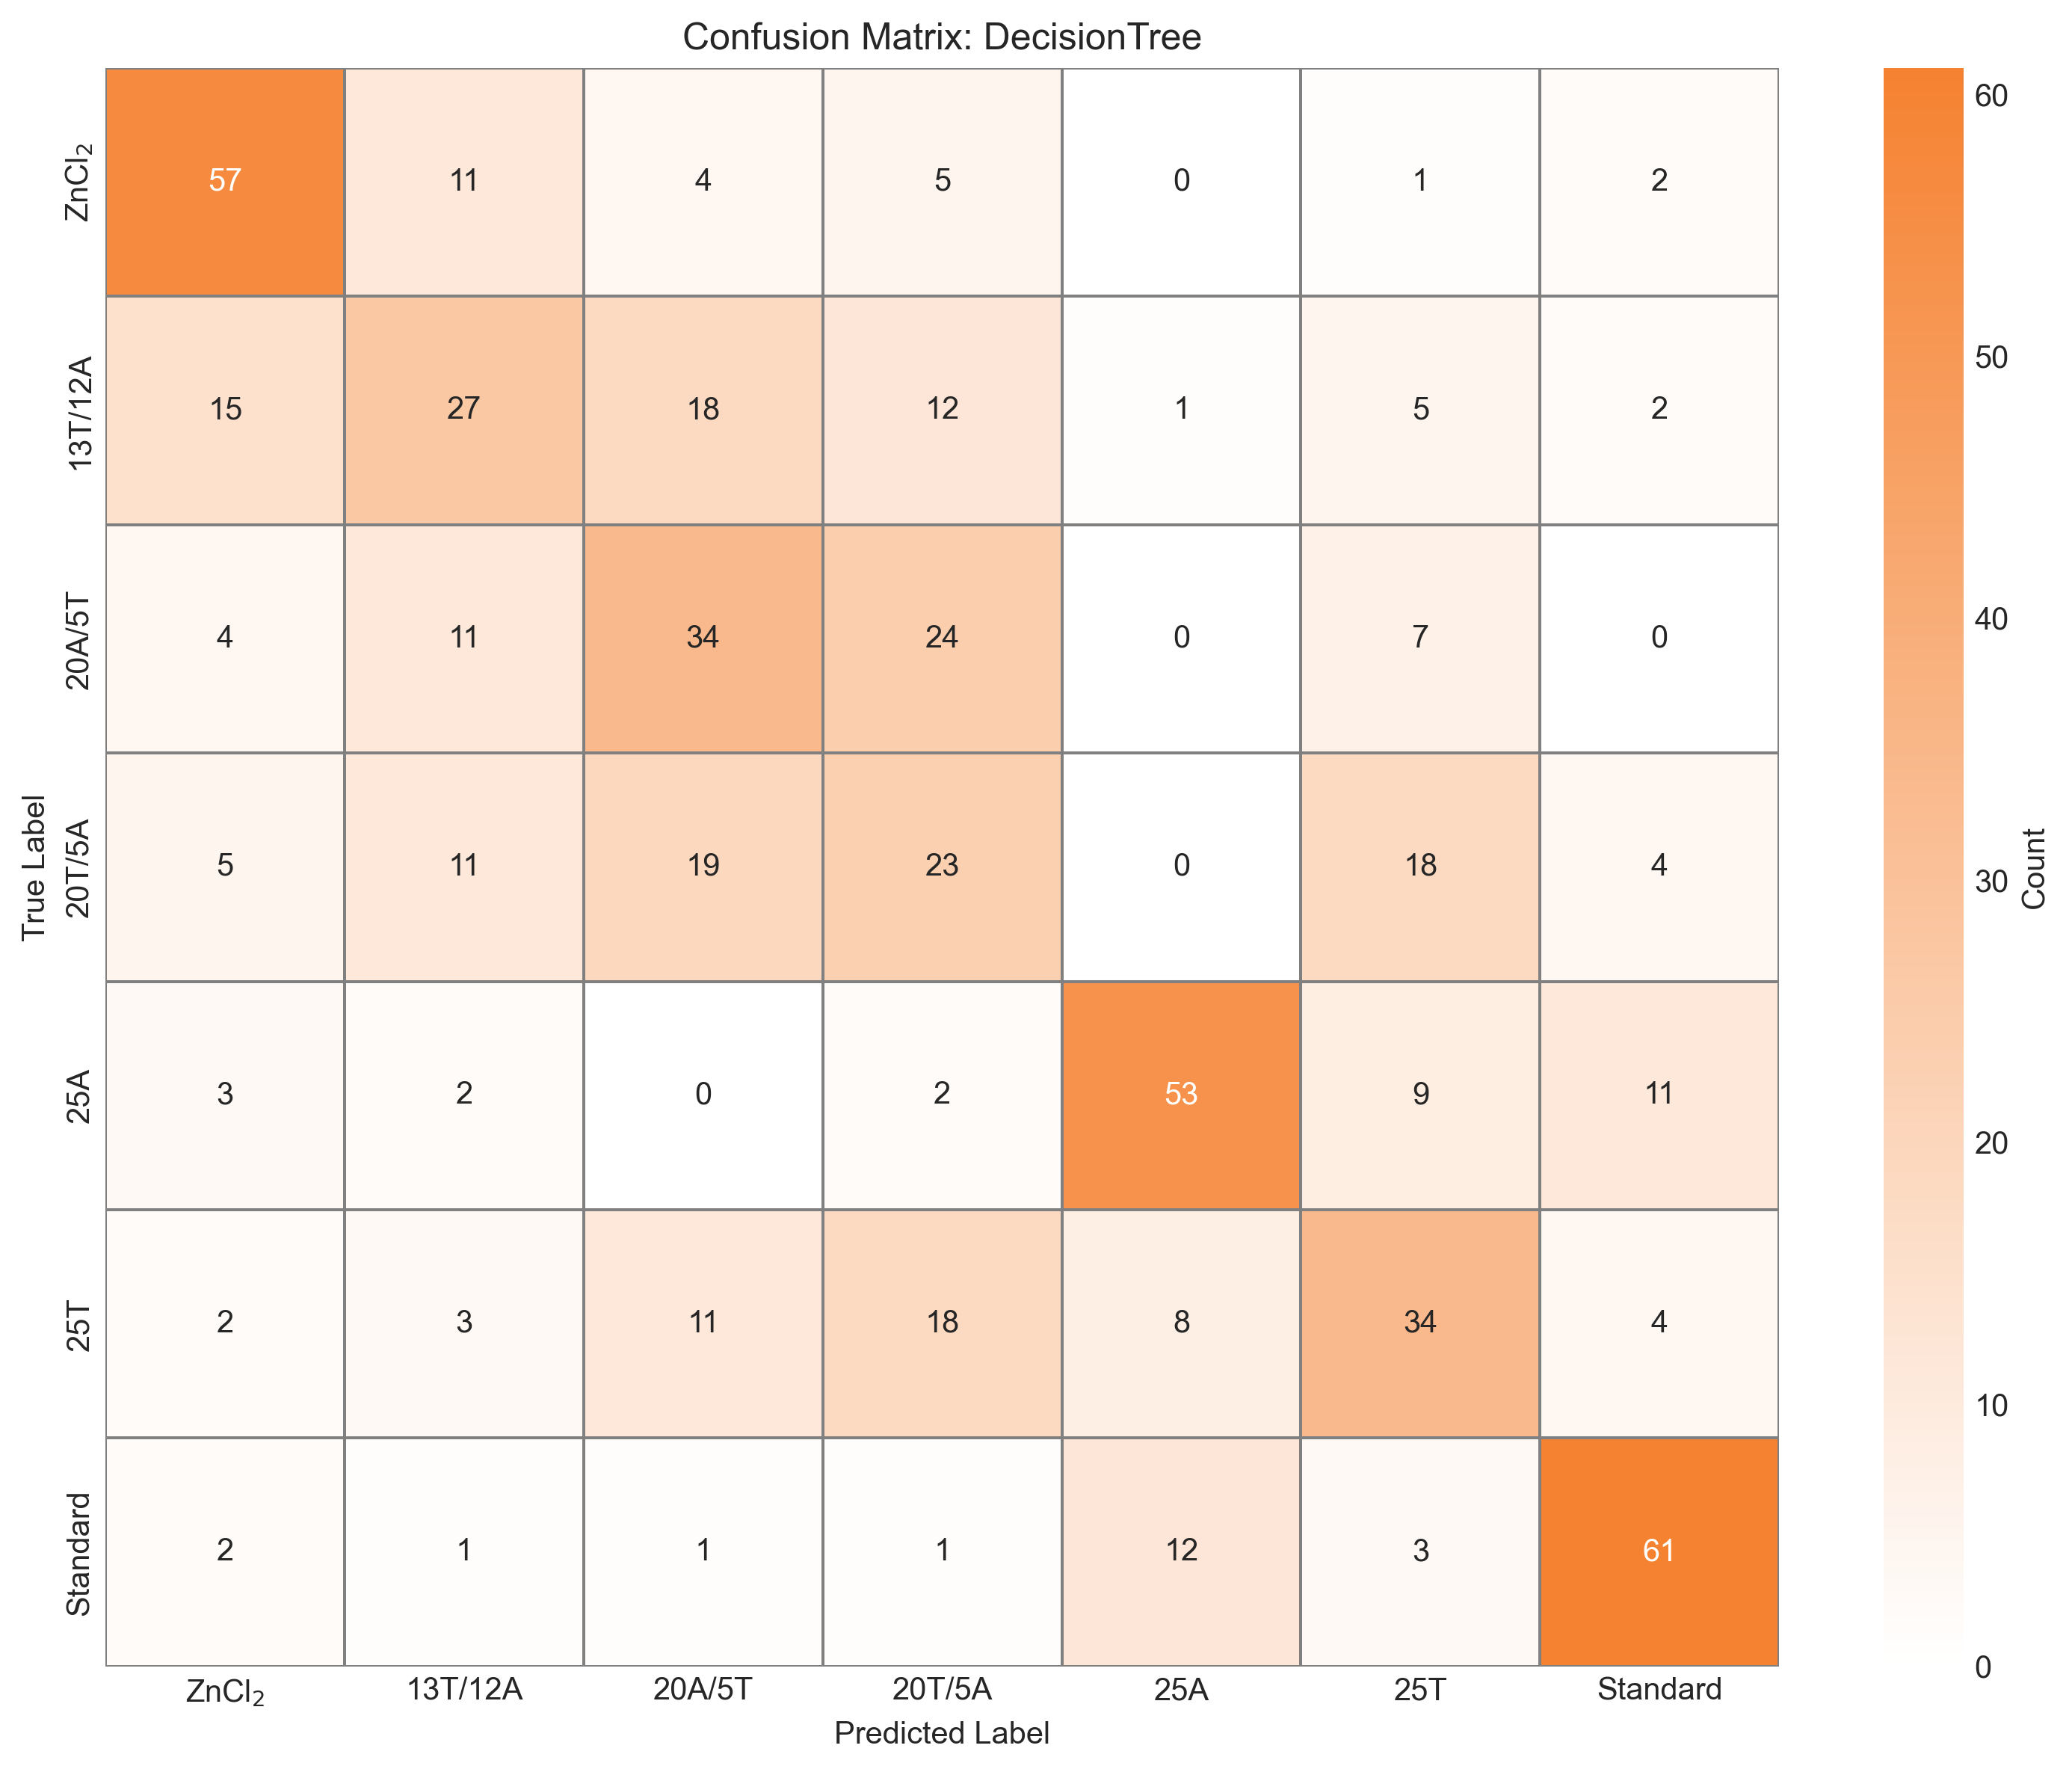

In [5]:
df = pd.read_csv("confusion_matrices/DecisionTree_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#F58231' 
custom_colors = ["#FFFFFF", darkest_color_hex] # Gradient from white to your darkest color
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: DecisionTree')
plt.tight_layout()

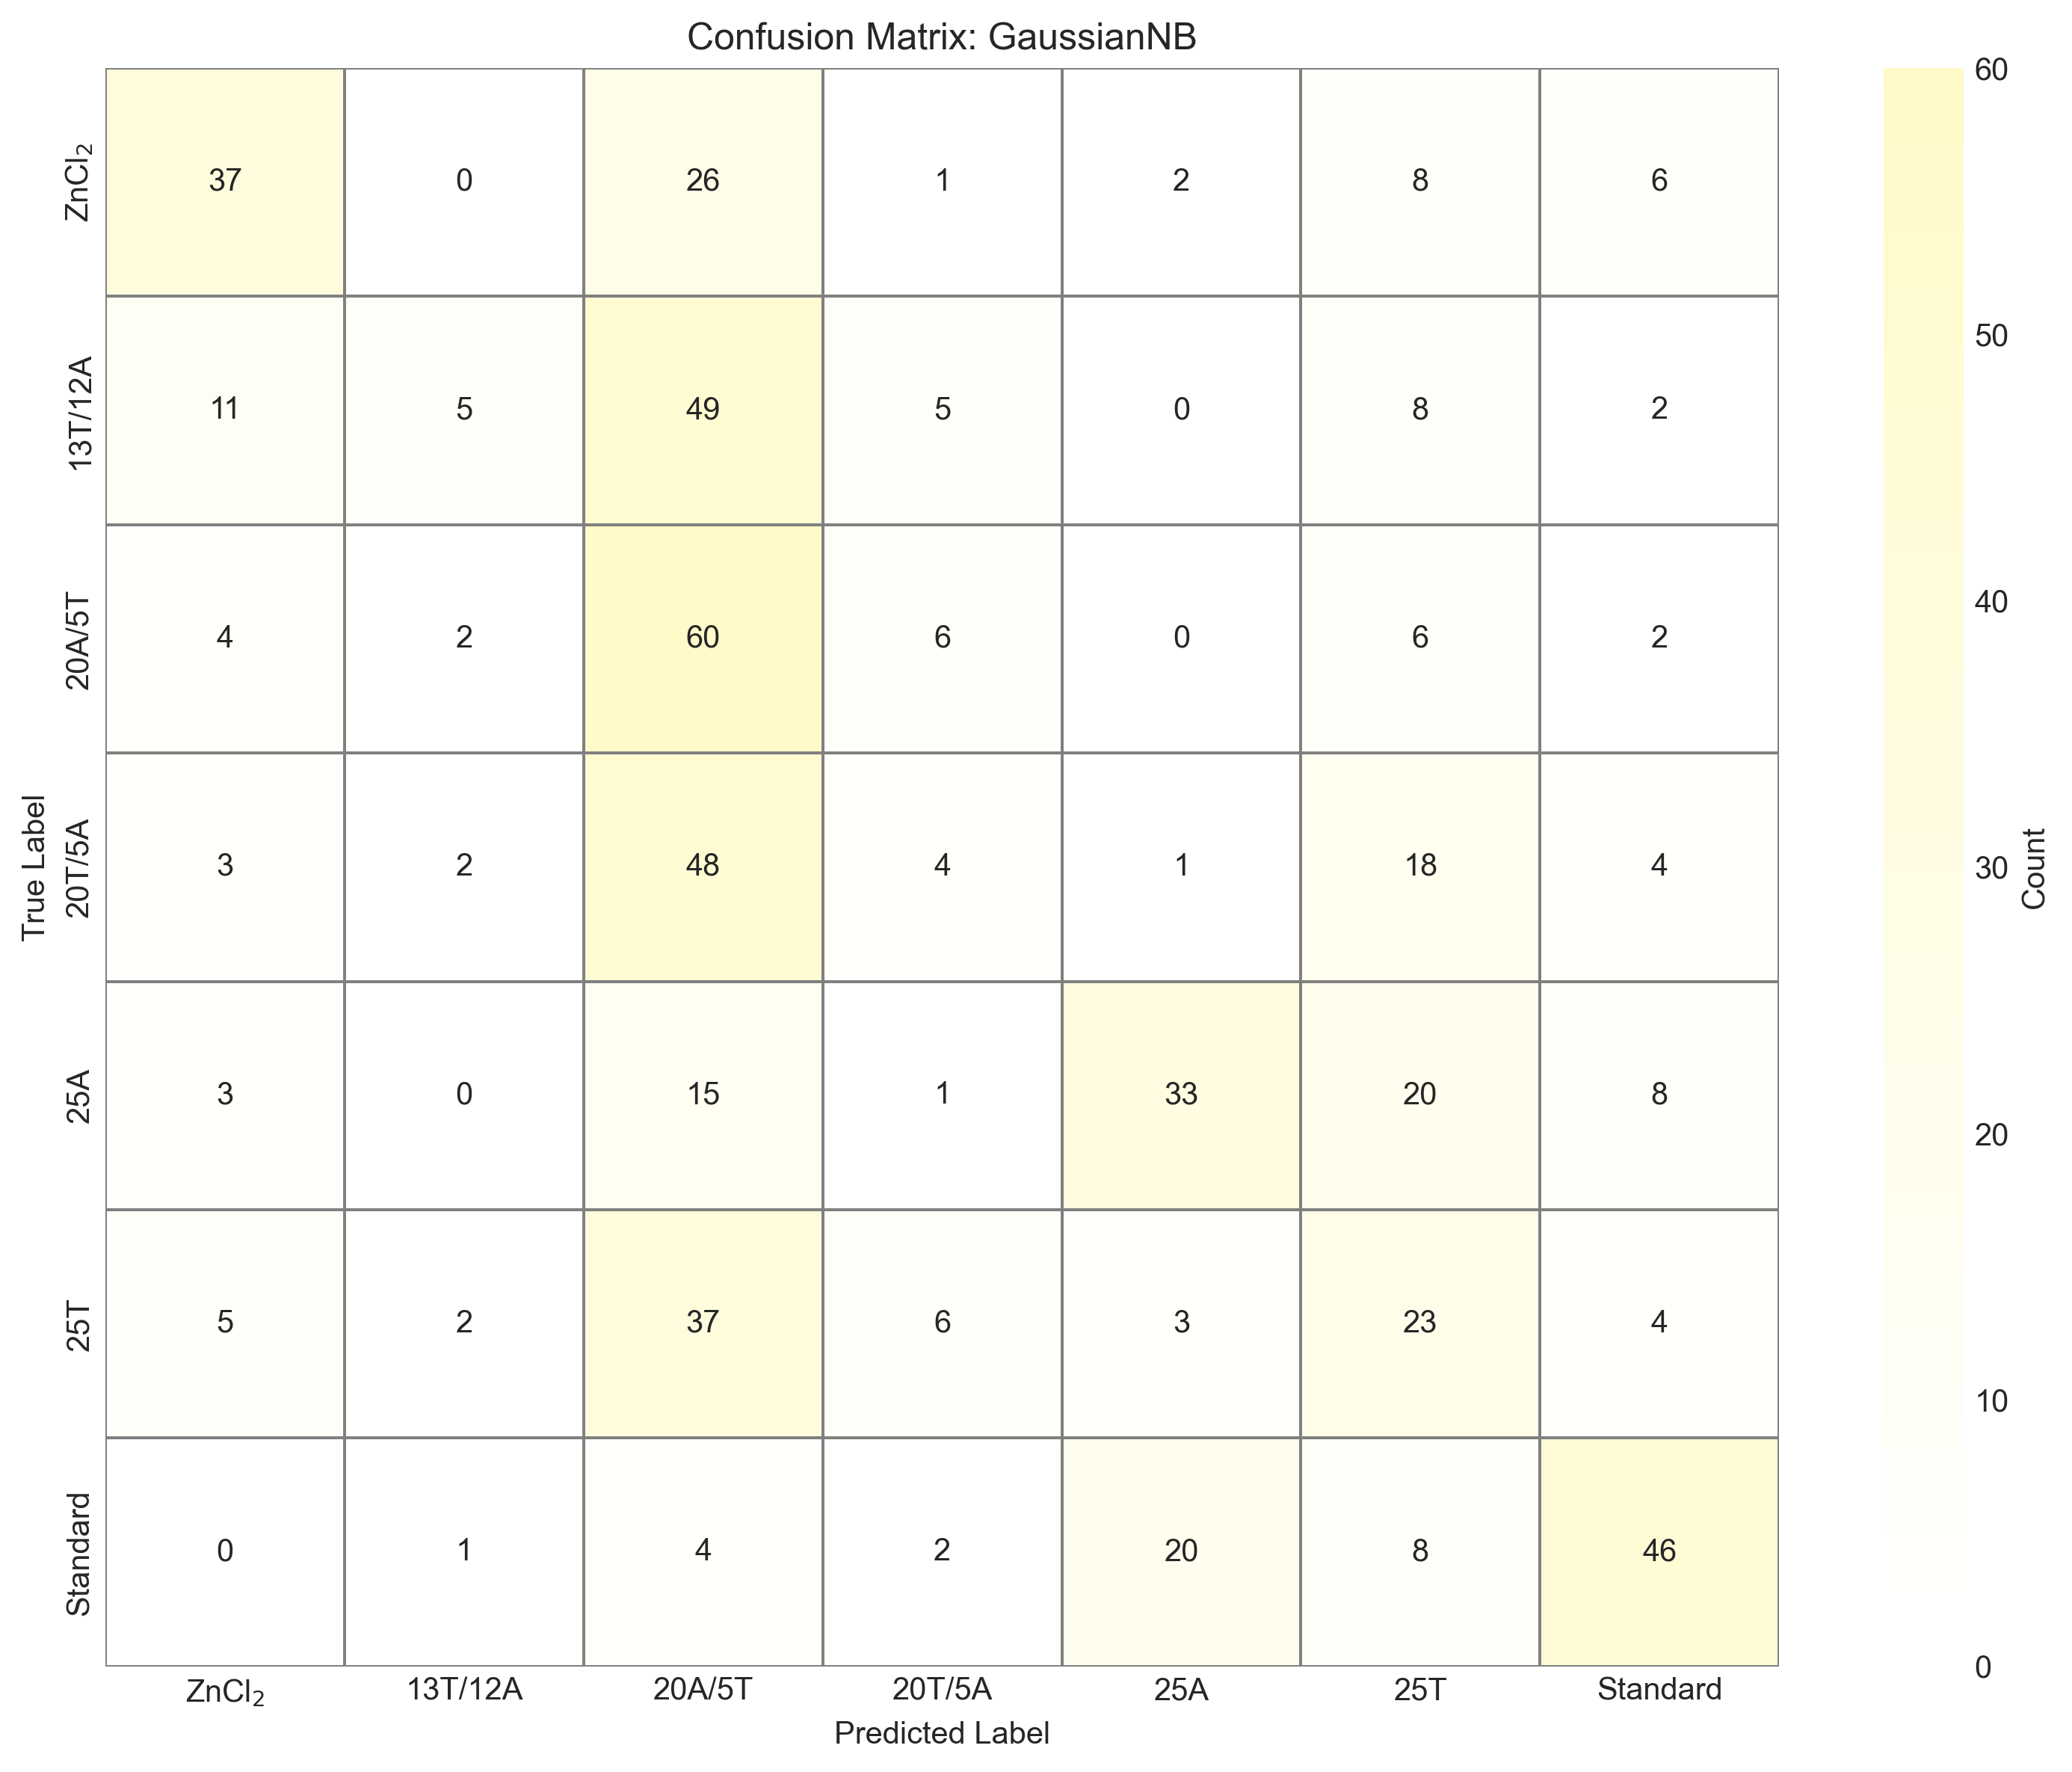

In [6]:
df = pd.read_csv("confusion_matrices/GaussianNB_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#FFFAC8' 
custom_colors = ["#FFFFFF", darkest_color_hex] # Gradient from white to your darkest color
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: GaussianNB')
plt.tight_layout()

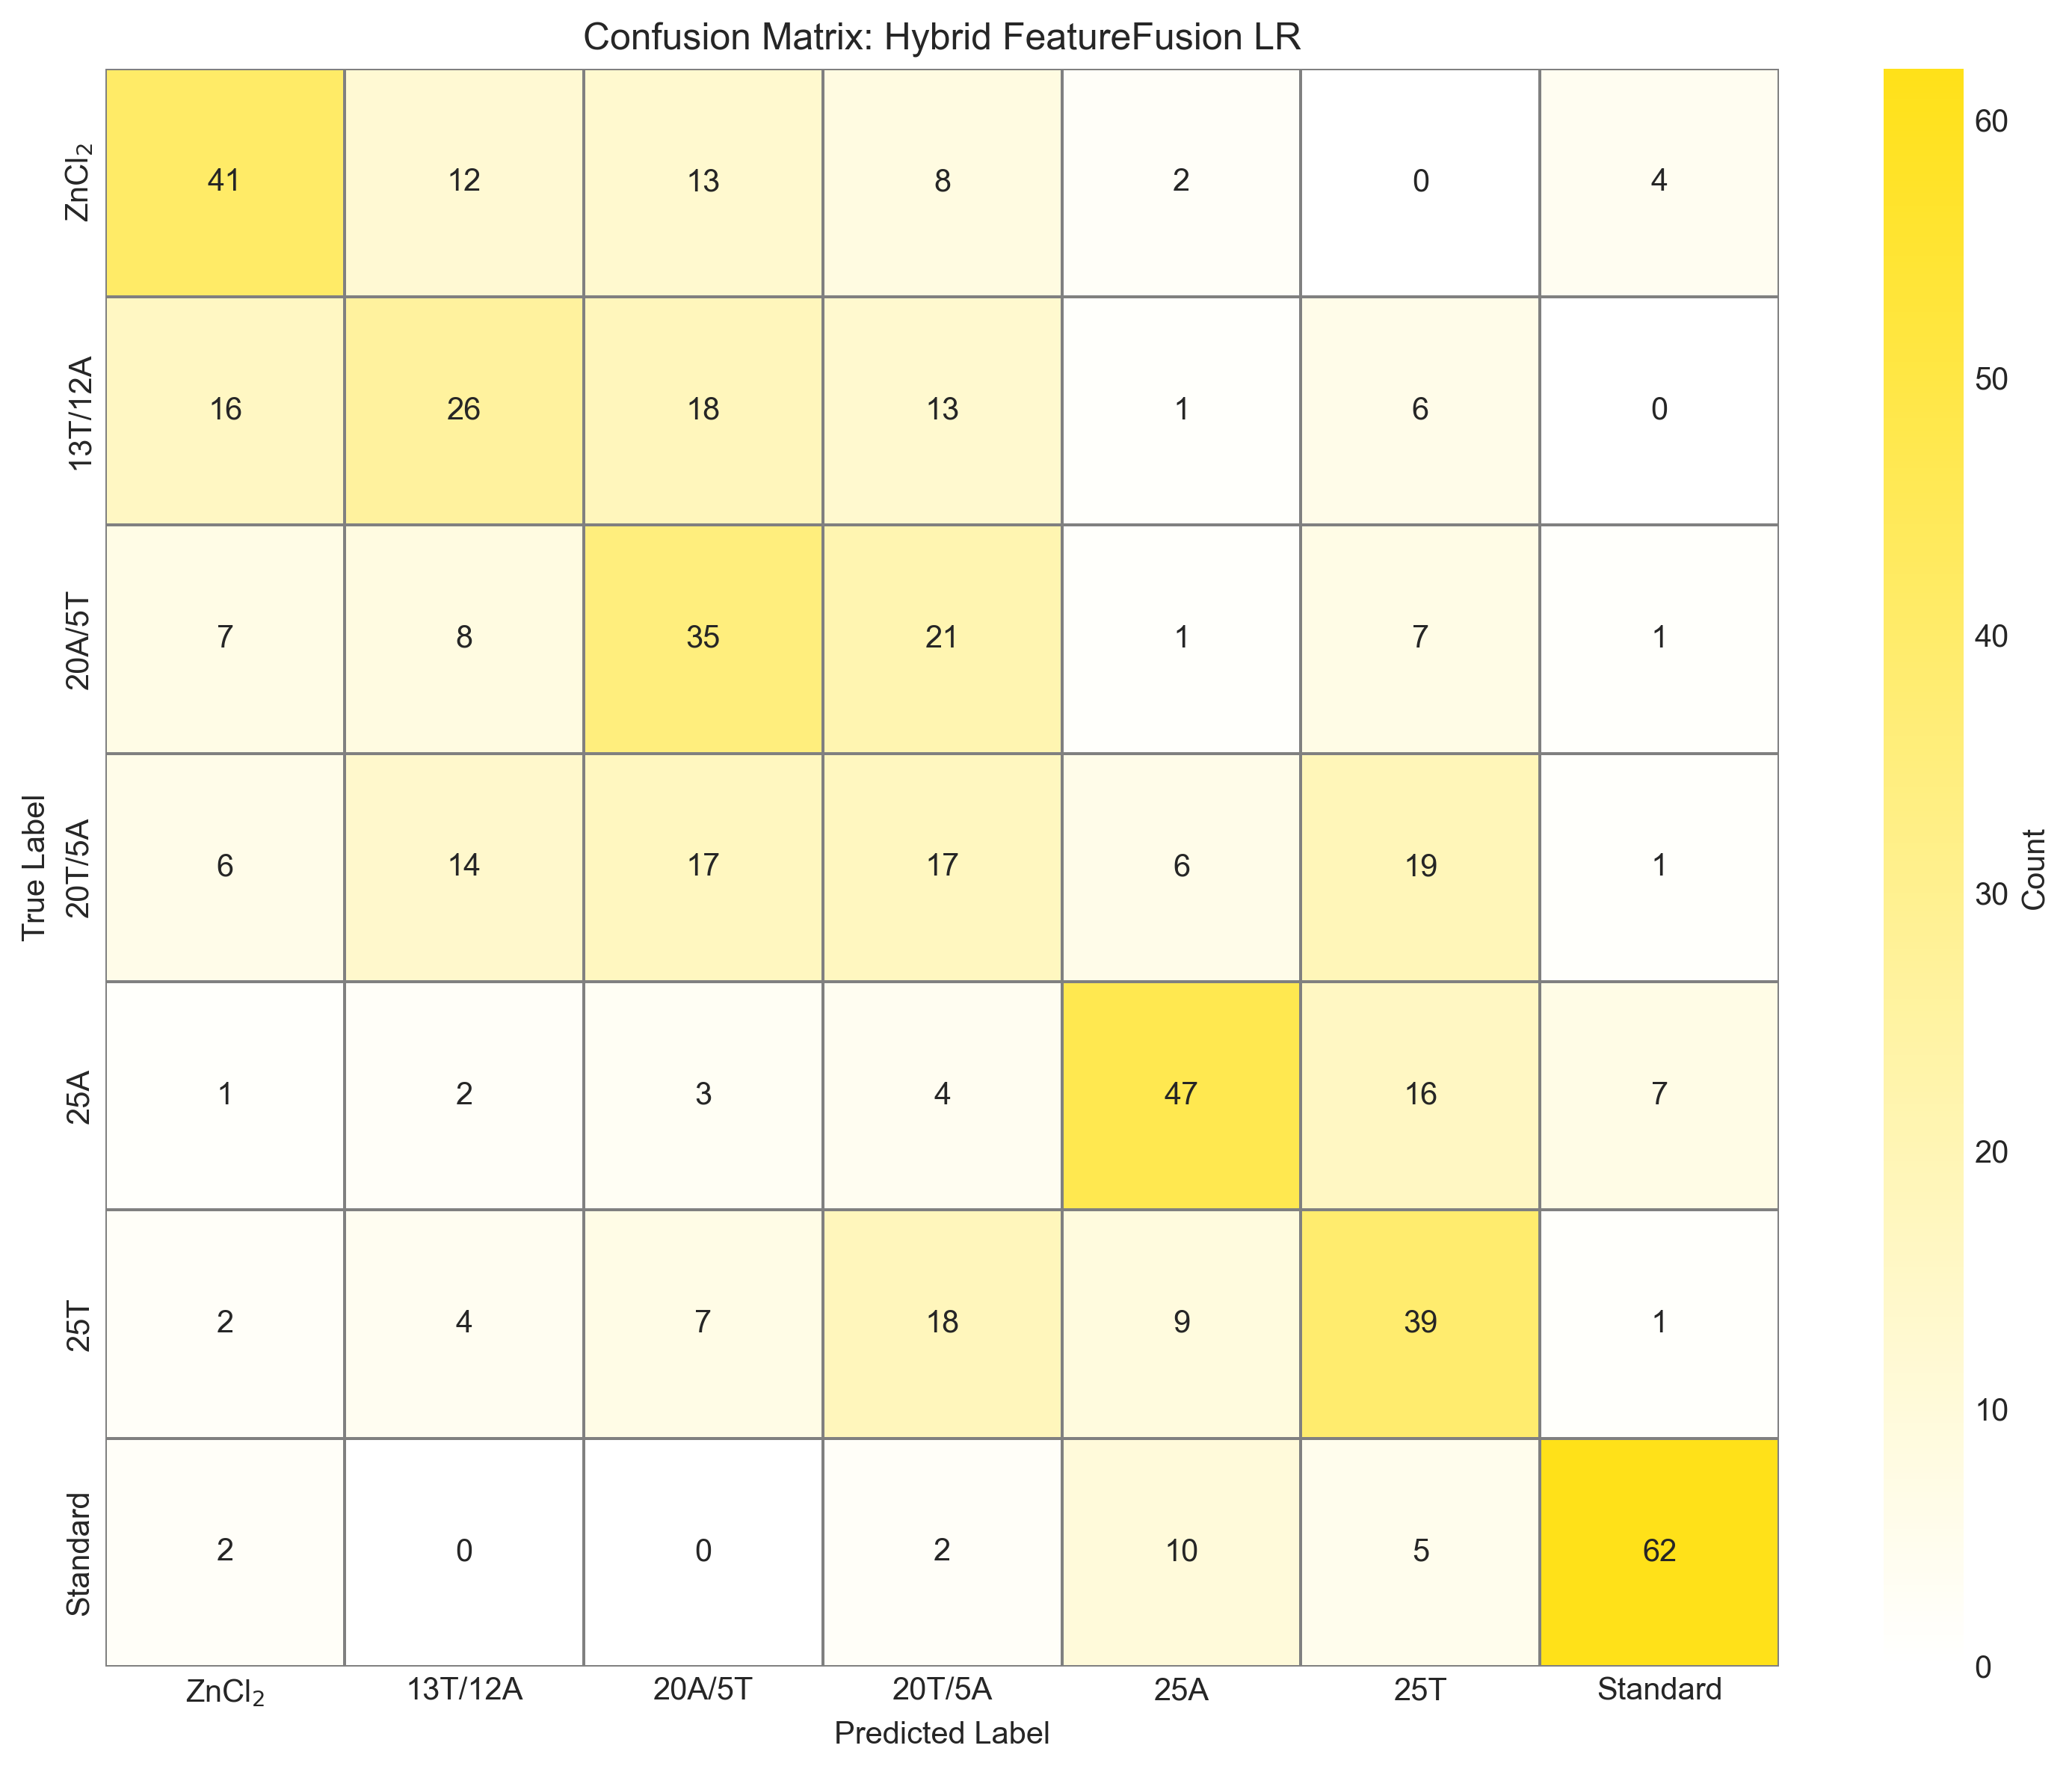

In [7]:
df = pd.read_csv("confusion_matrices/Hybrid_FF_LR_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#FFE119' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Hybrid FeatureFusion LR')
plt.tight_layout()

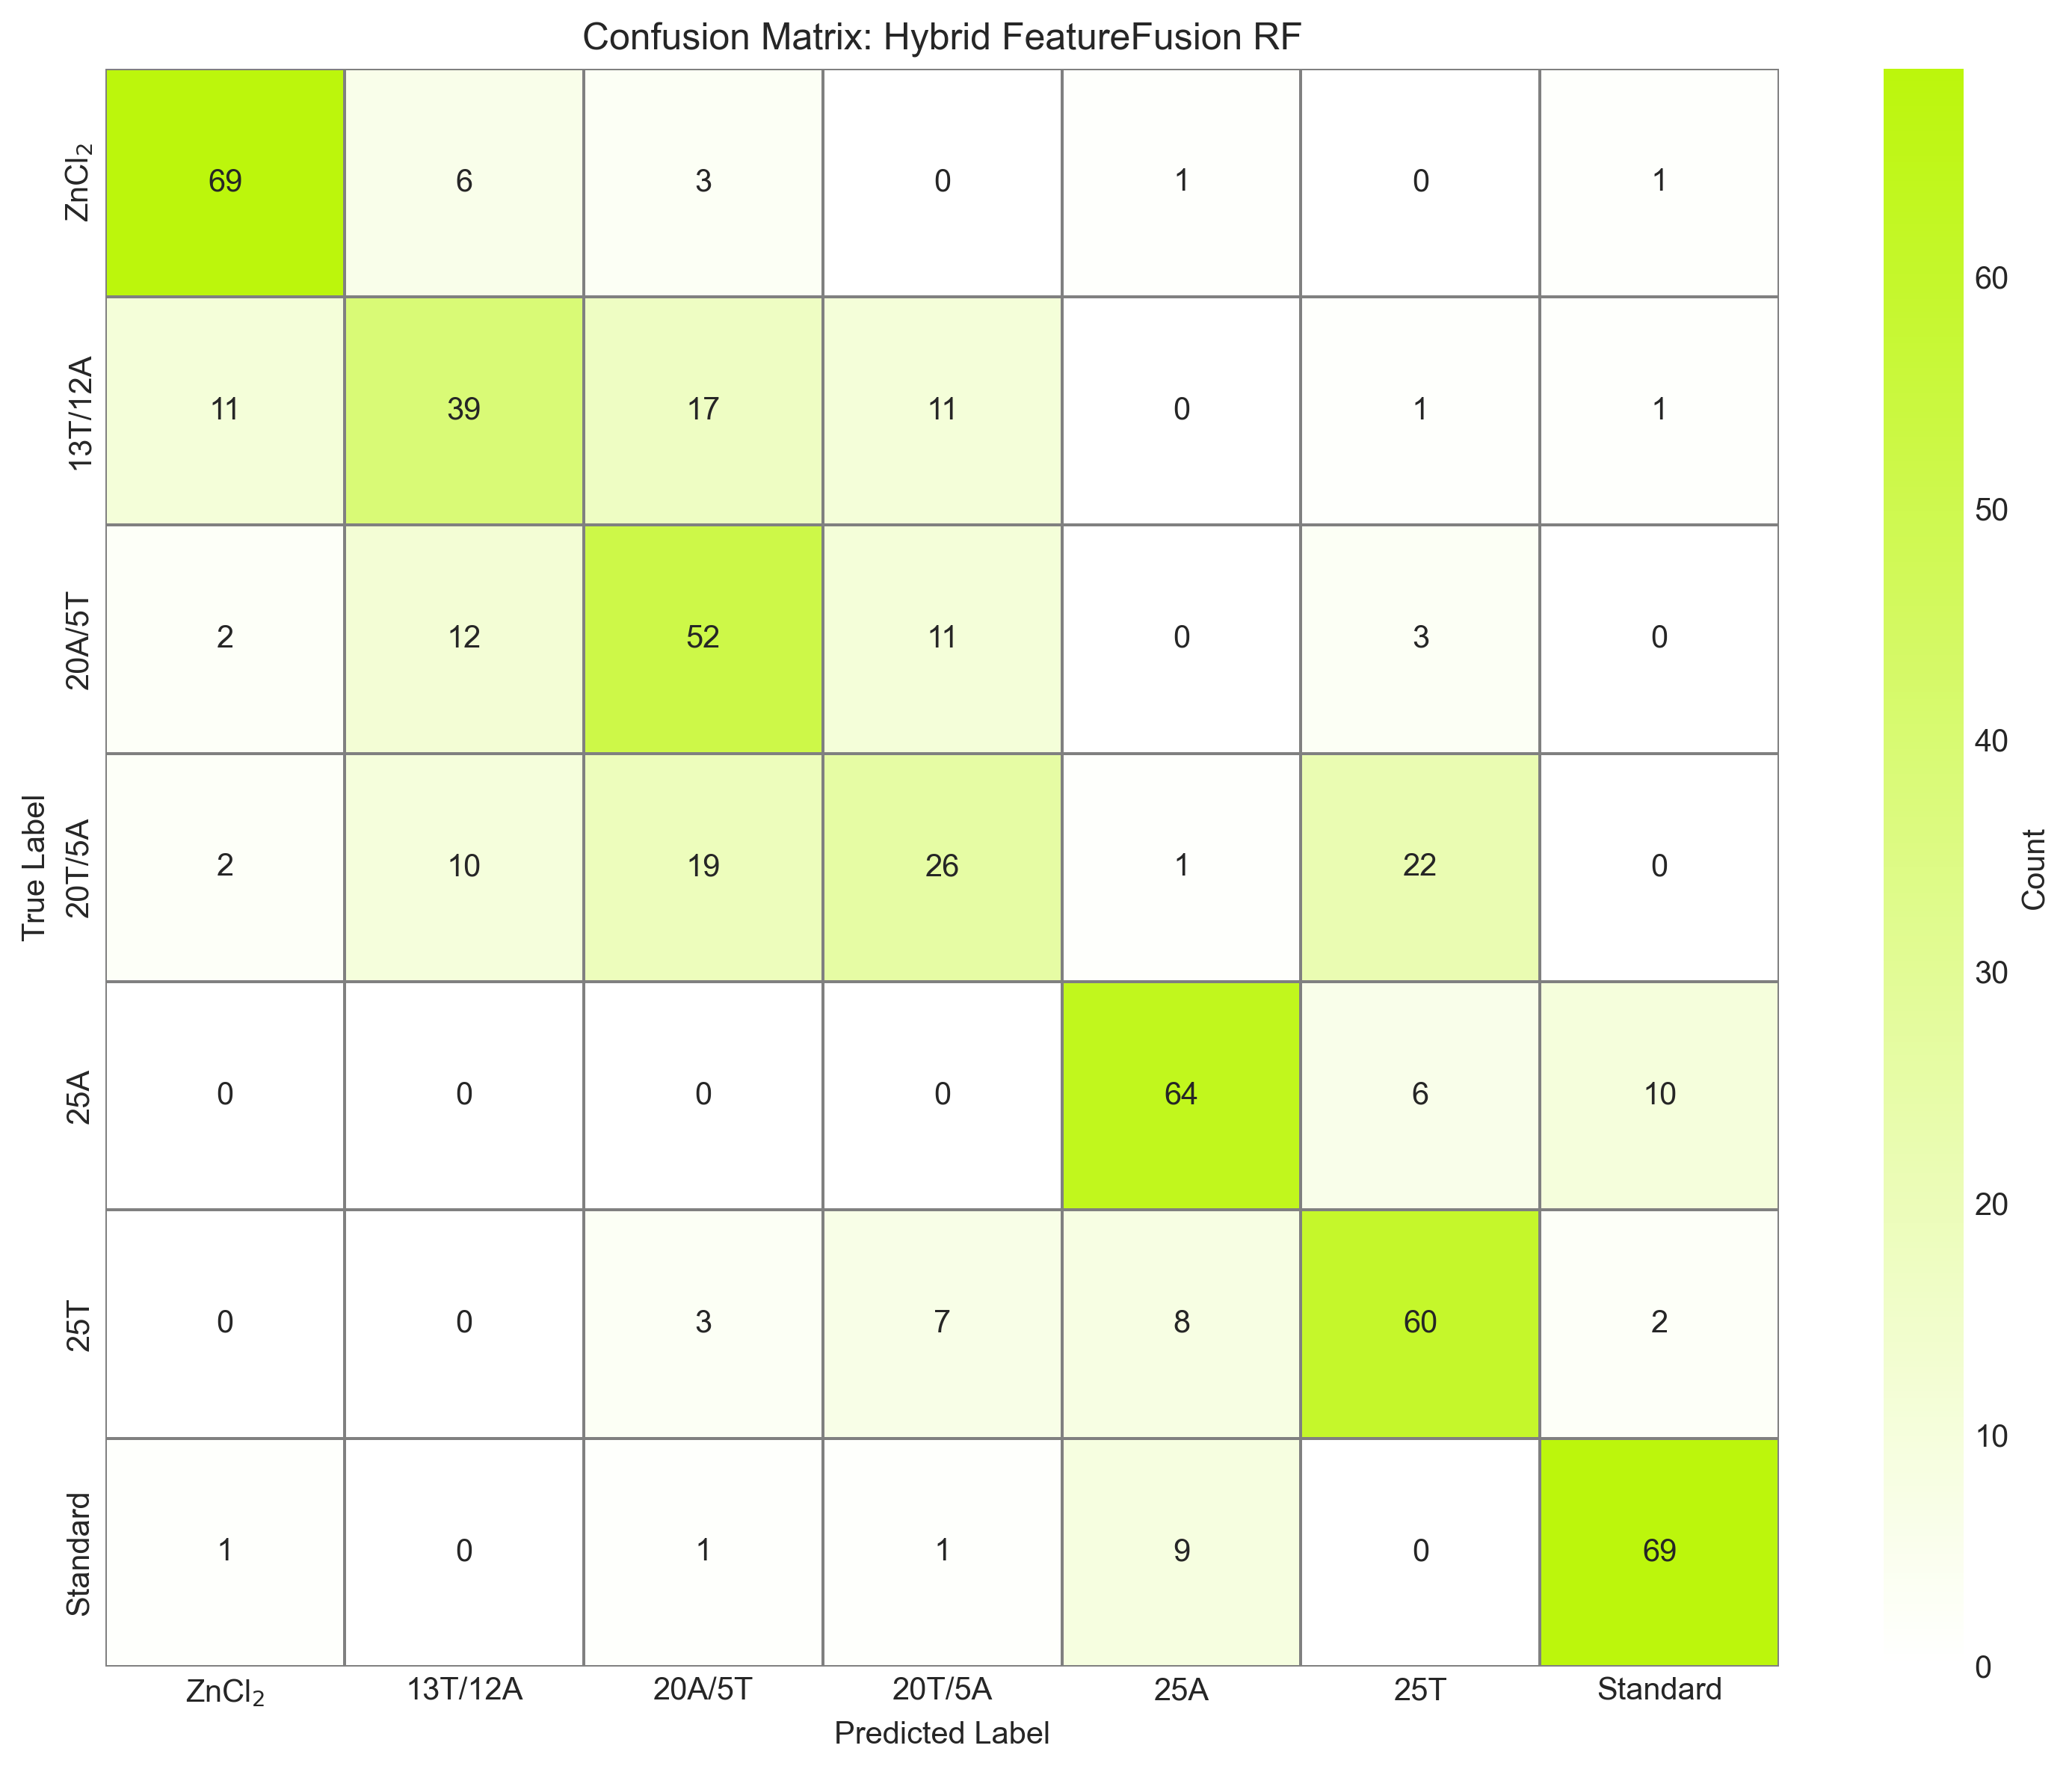

In [8]:
df = pd.read_csv("confusion_matrices/Hybrid_FF_RF_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#BCF60C' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Hybrid FeatureFusion RF')
plt.tight_layout()

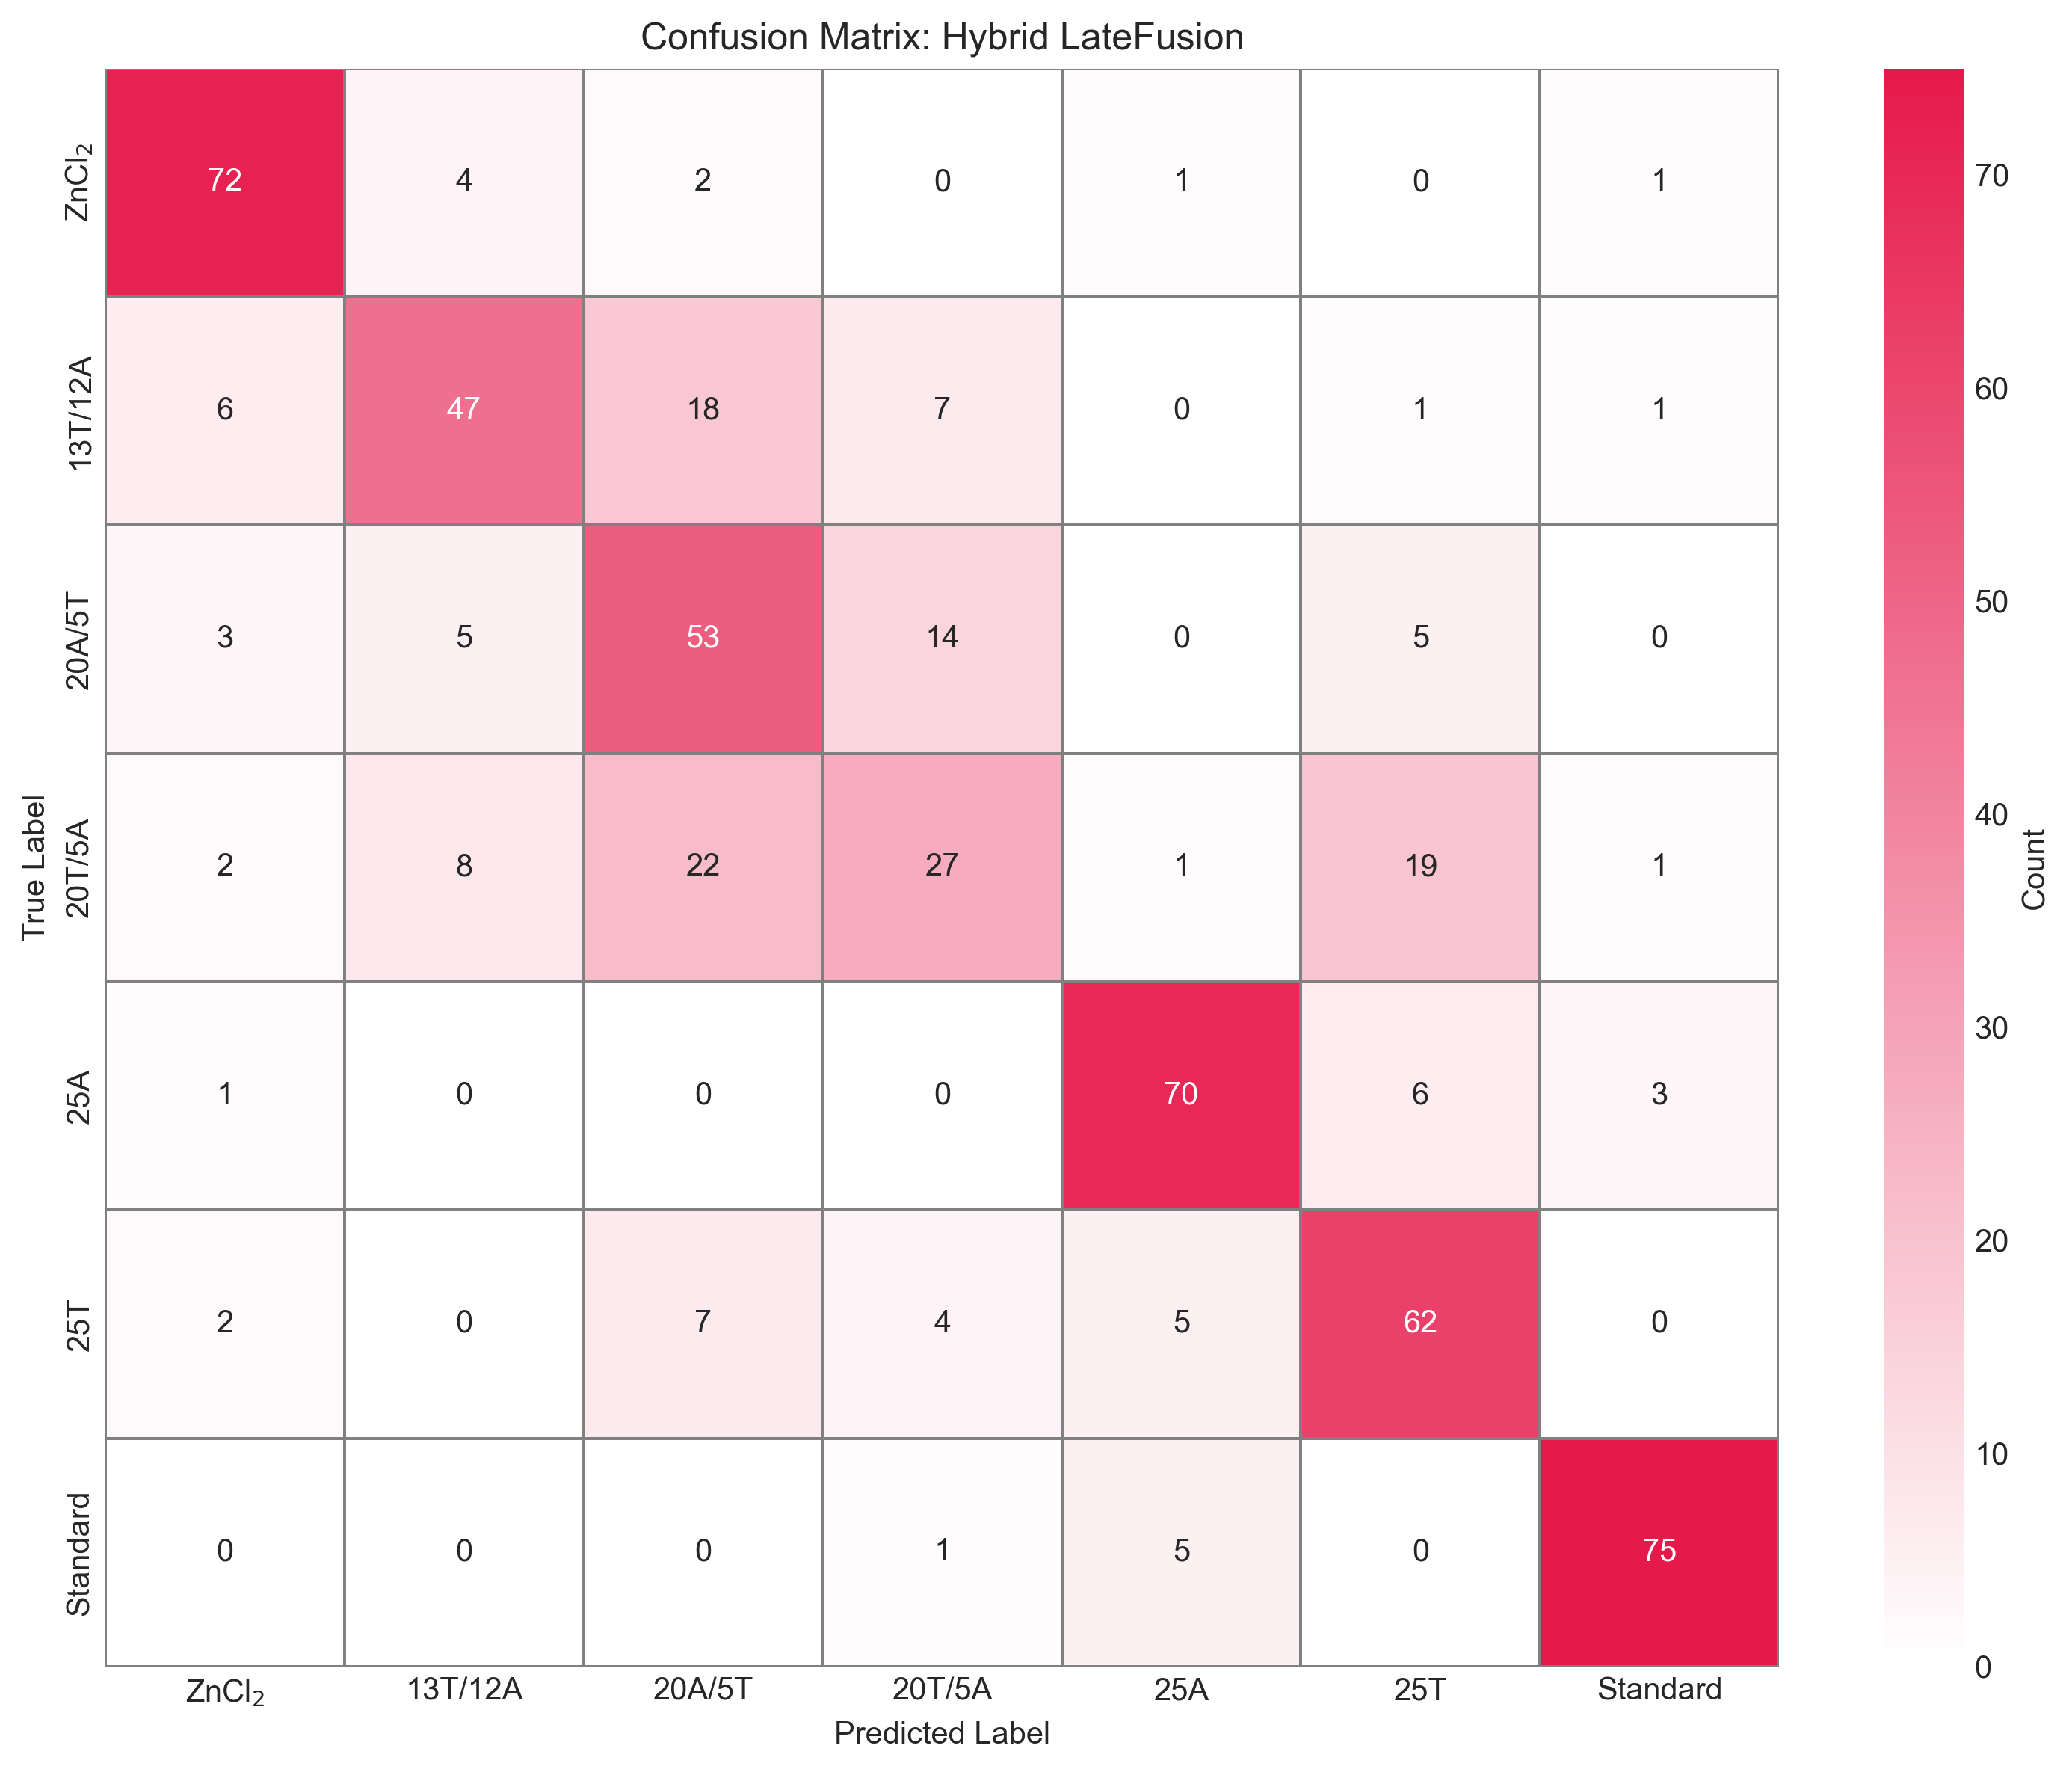

In [9]:
df = pd.read_csv("confusion_matrices/Hybrid_LateFusion_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#E6194B' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Hybrid LateFusion')
plt.tight_layout()

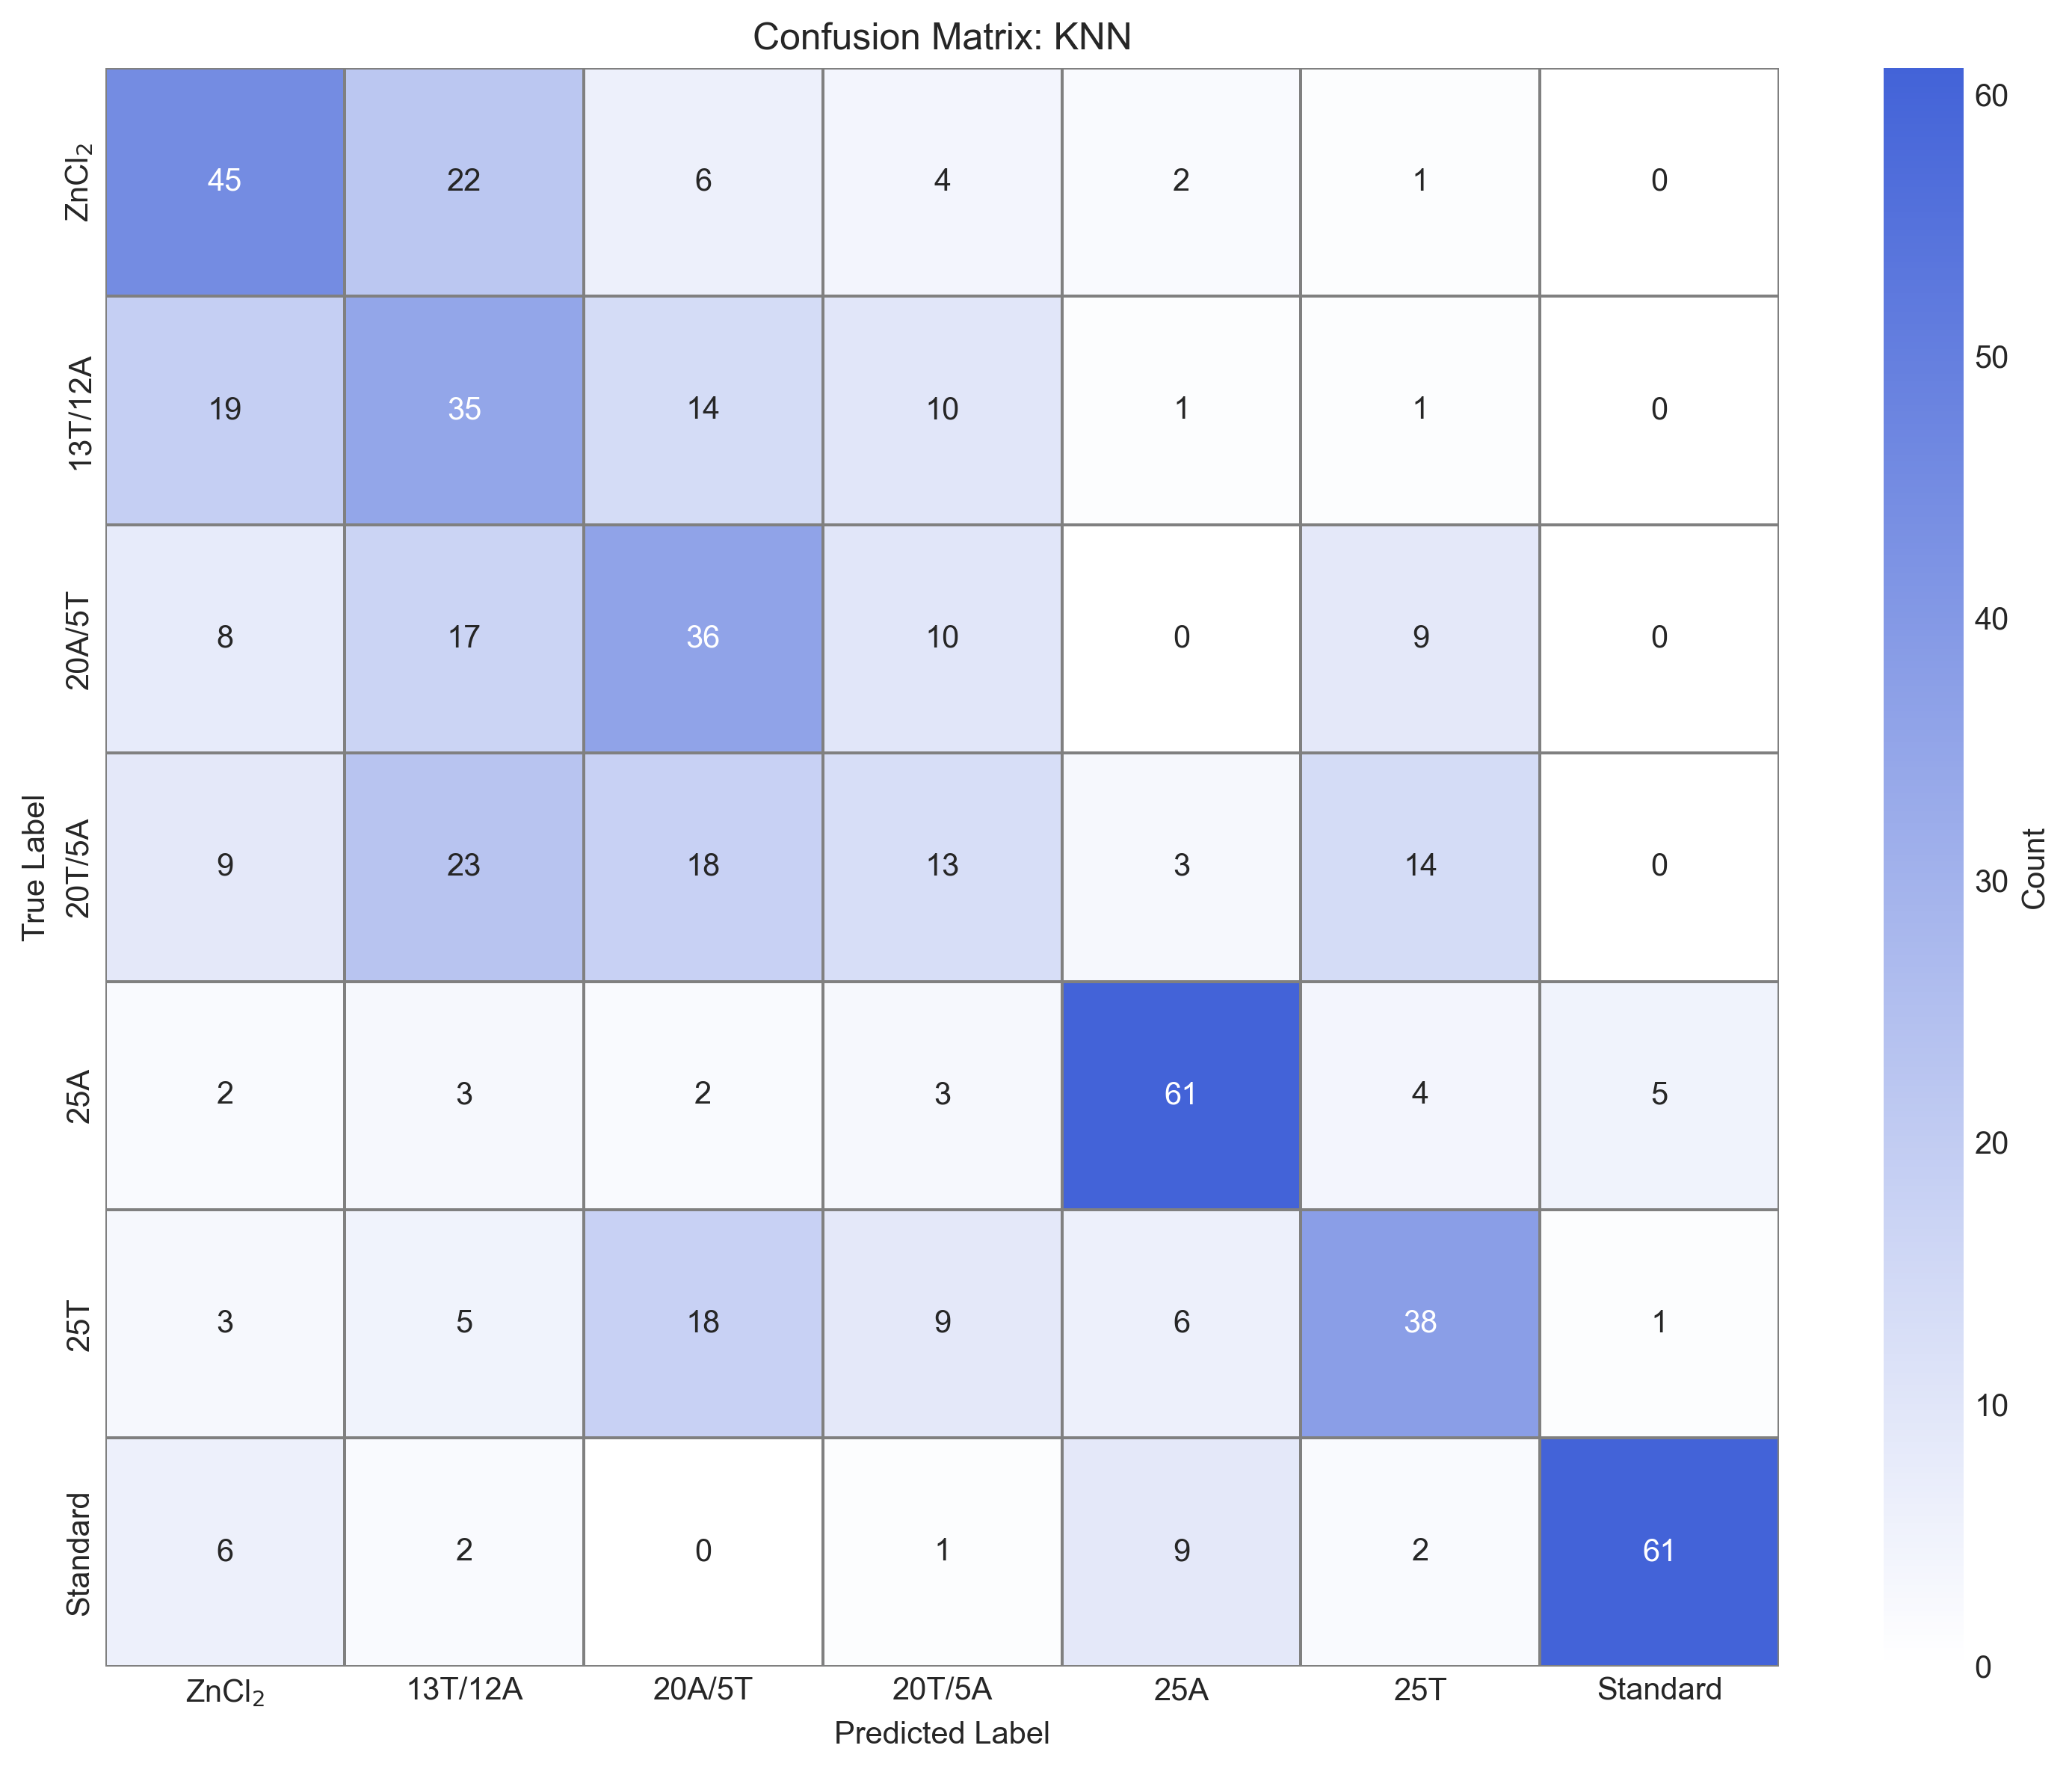

In [10]:
df = pd.read_csv("confusion_matrices/KNN_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#4363D8' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: KNN')
plt.tight_layout()

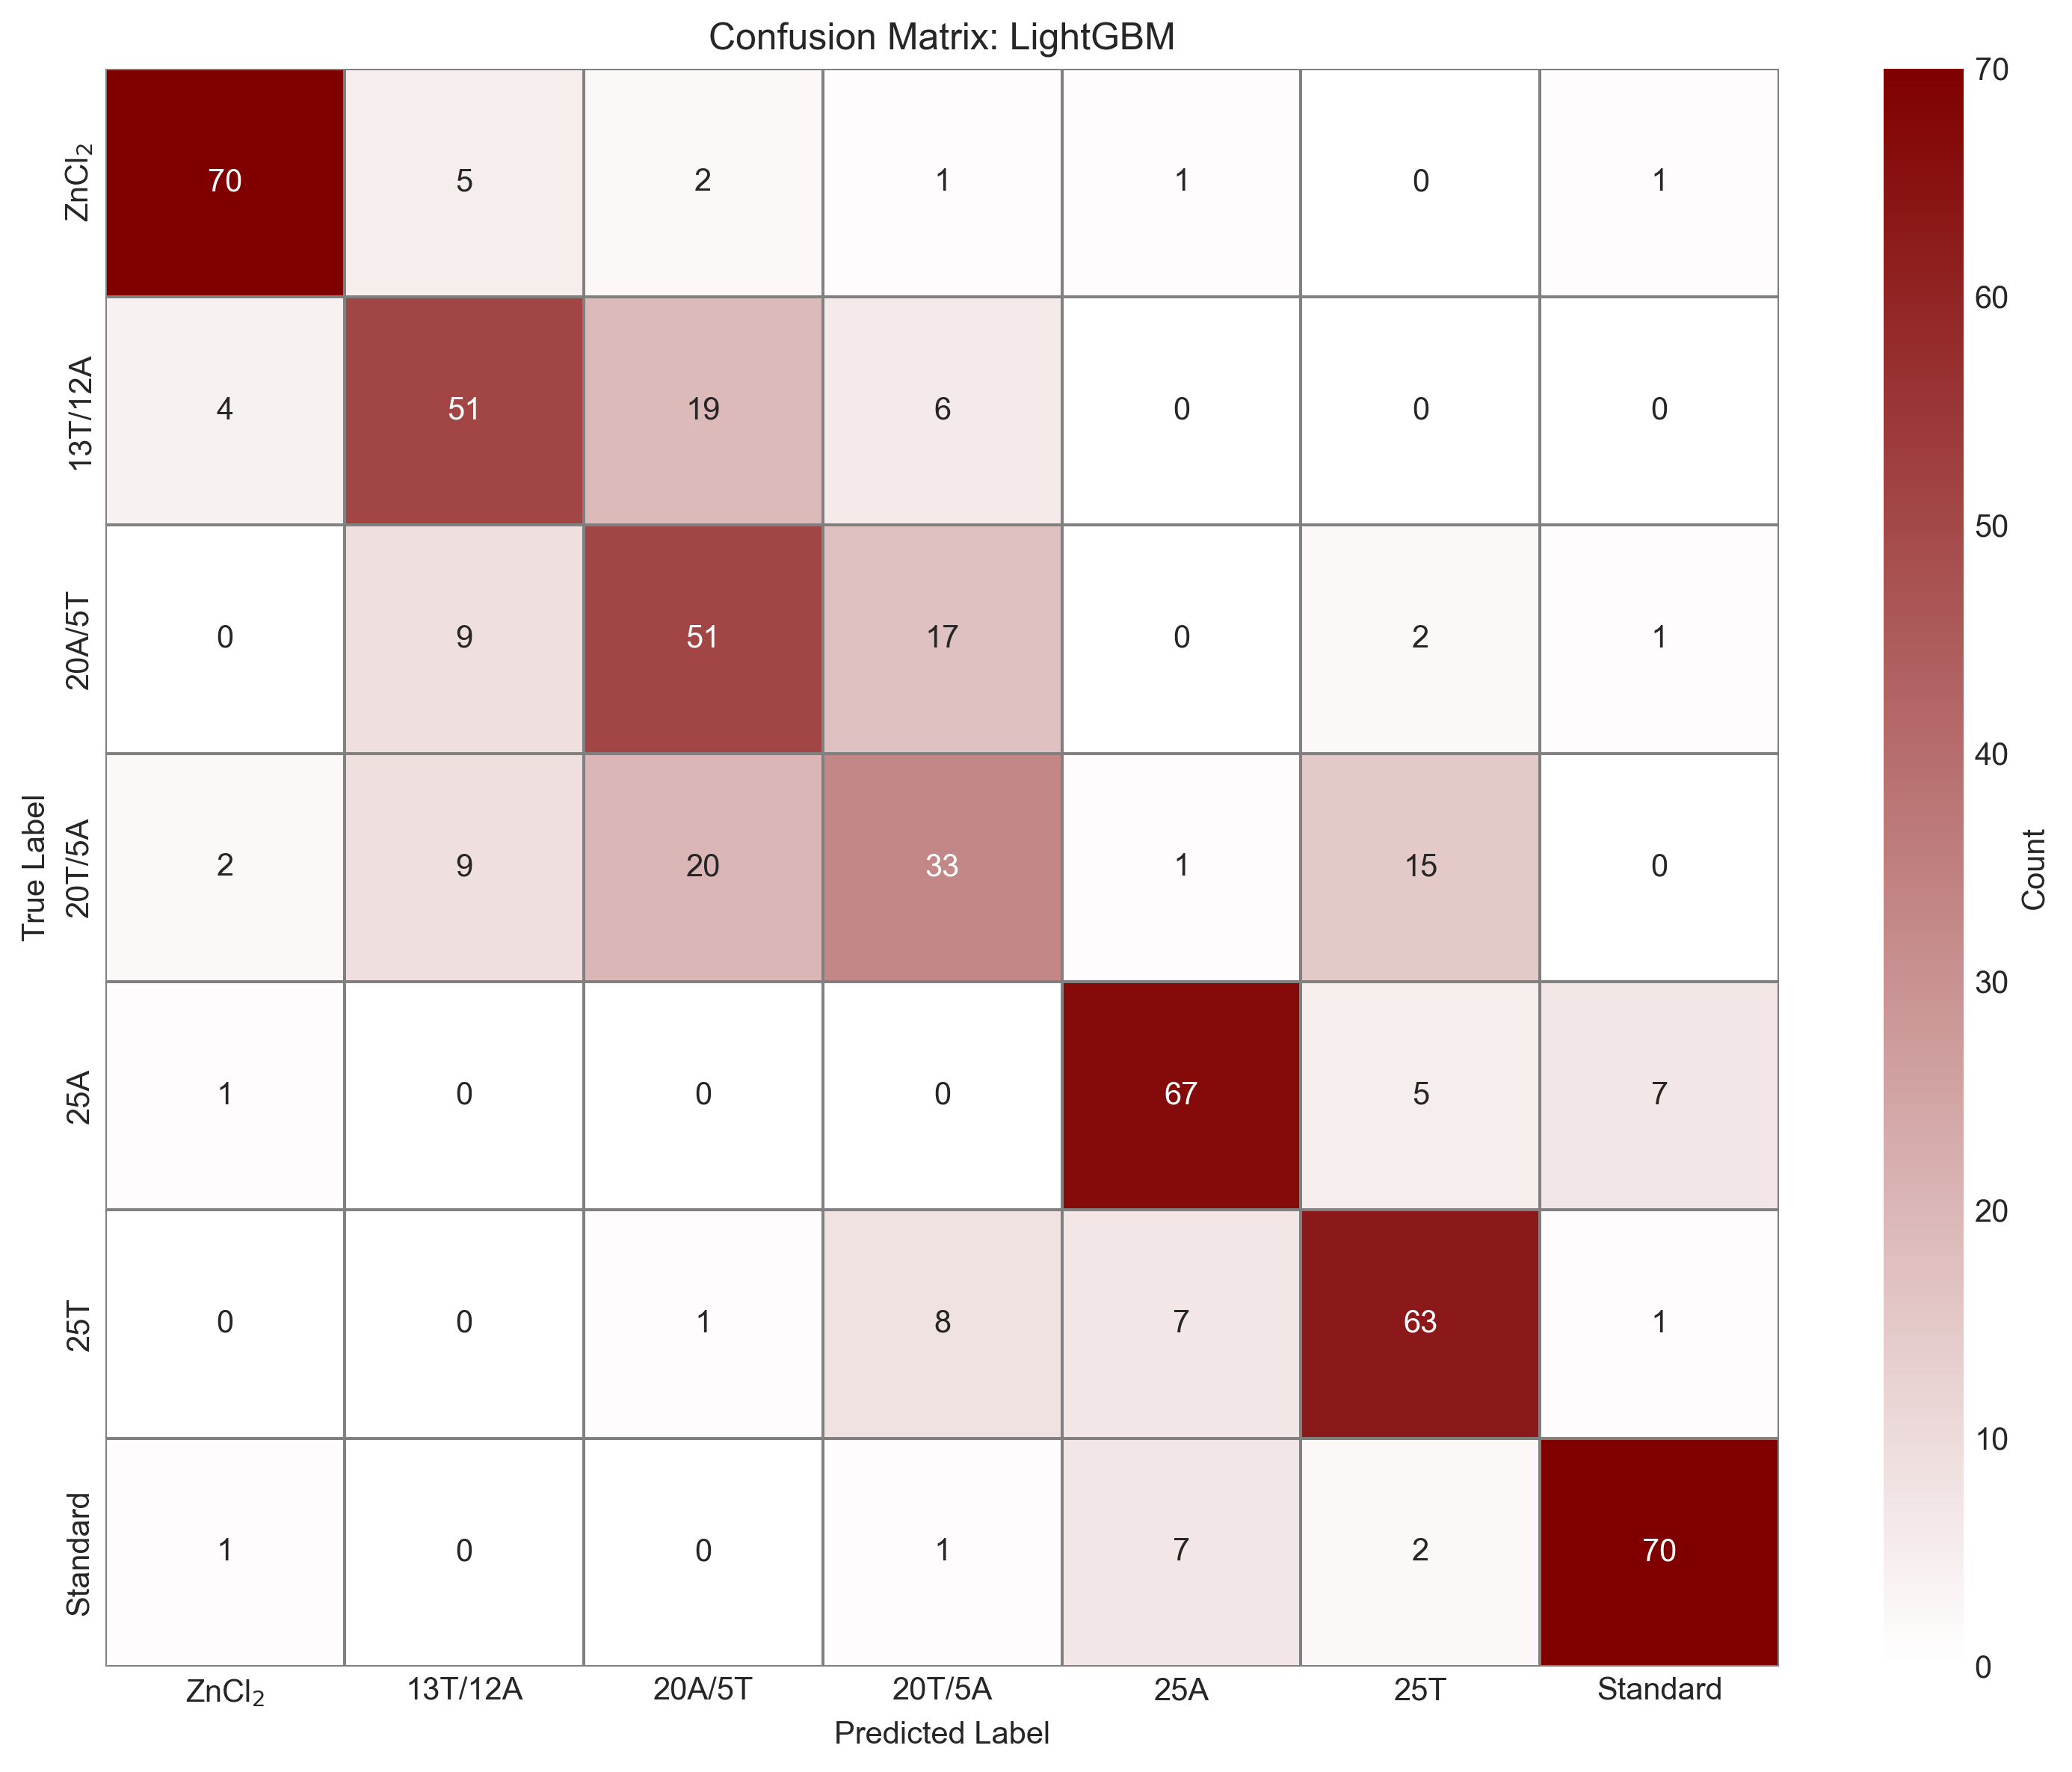

In [11]:
df = pd.read_csv("confusion_matrices/LightGBM_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#800000' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: LightGBM')
plt.tight_layout()

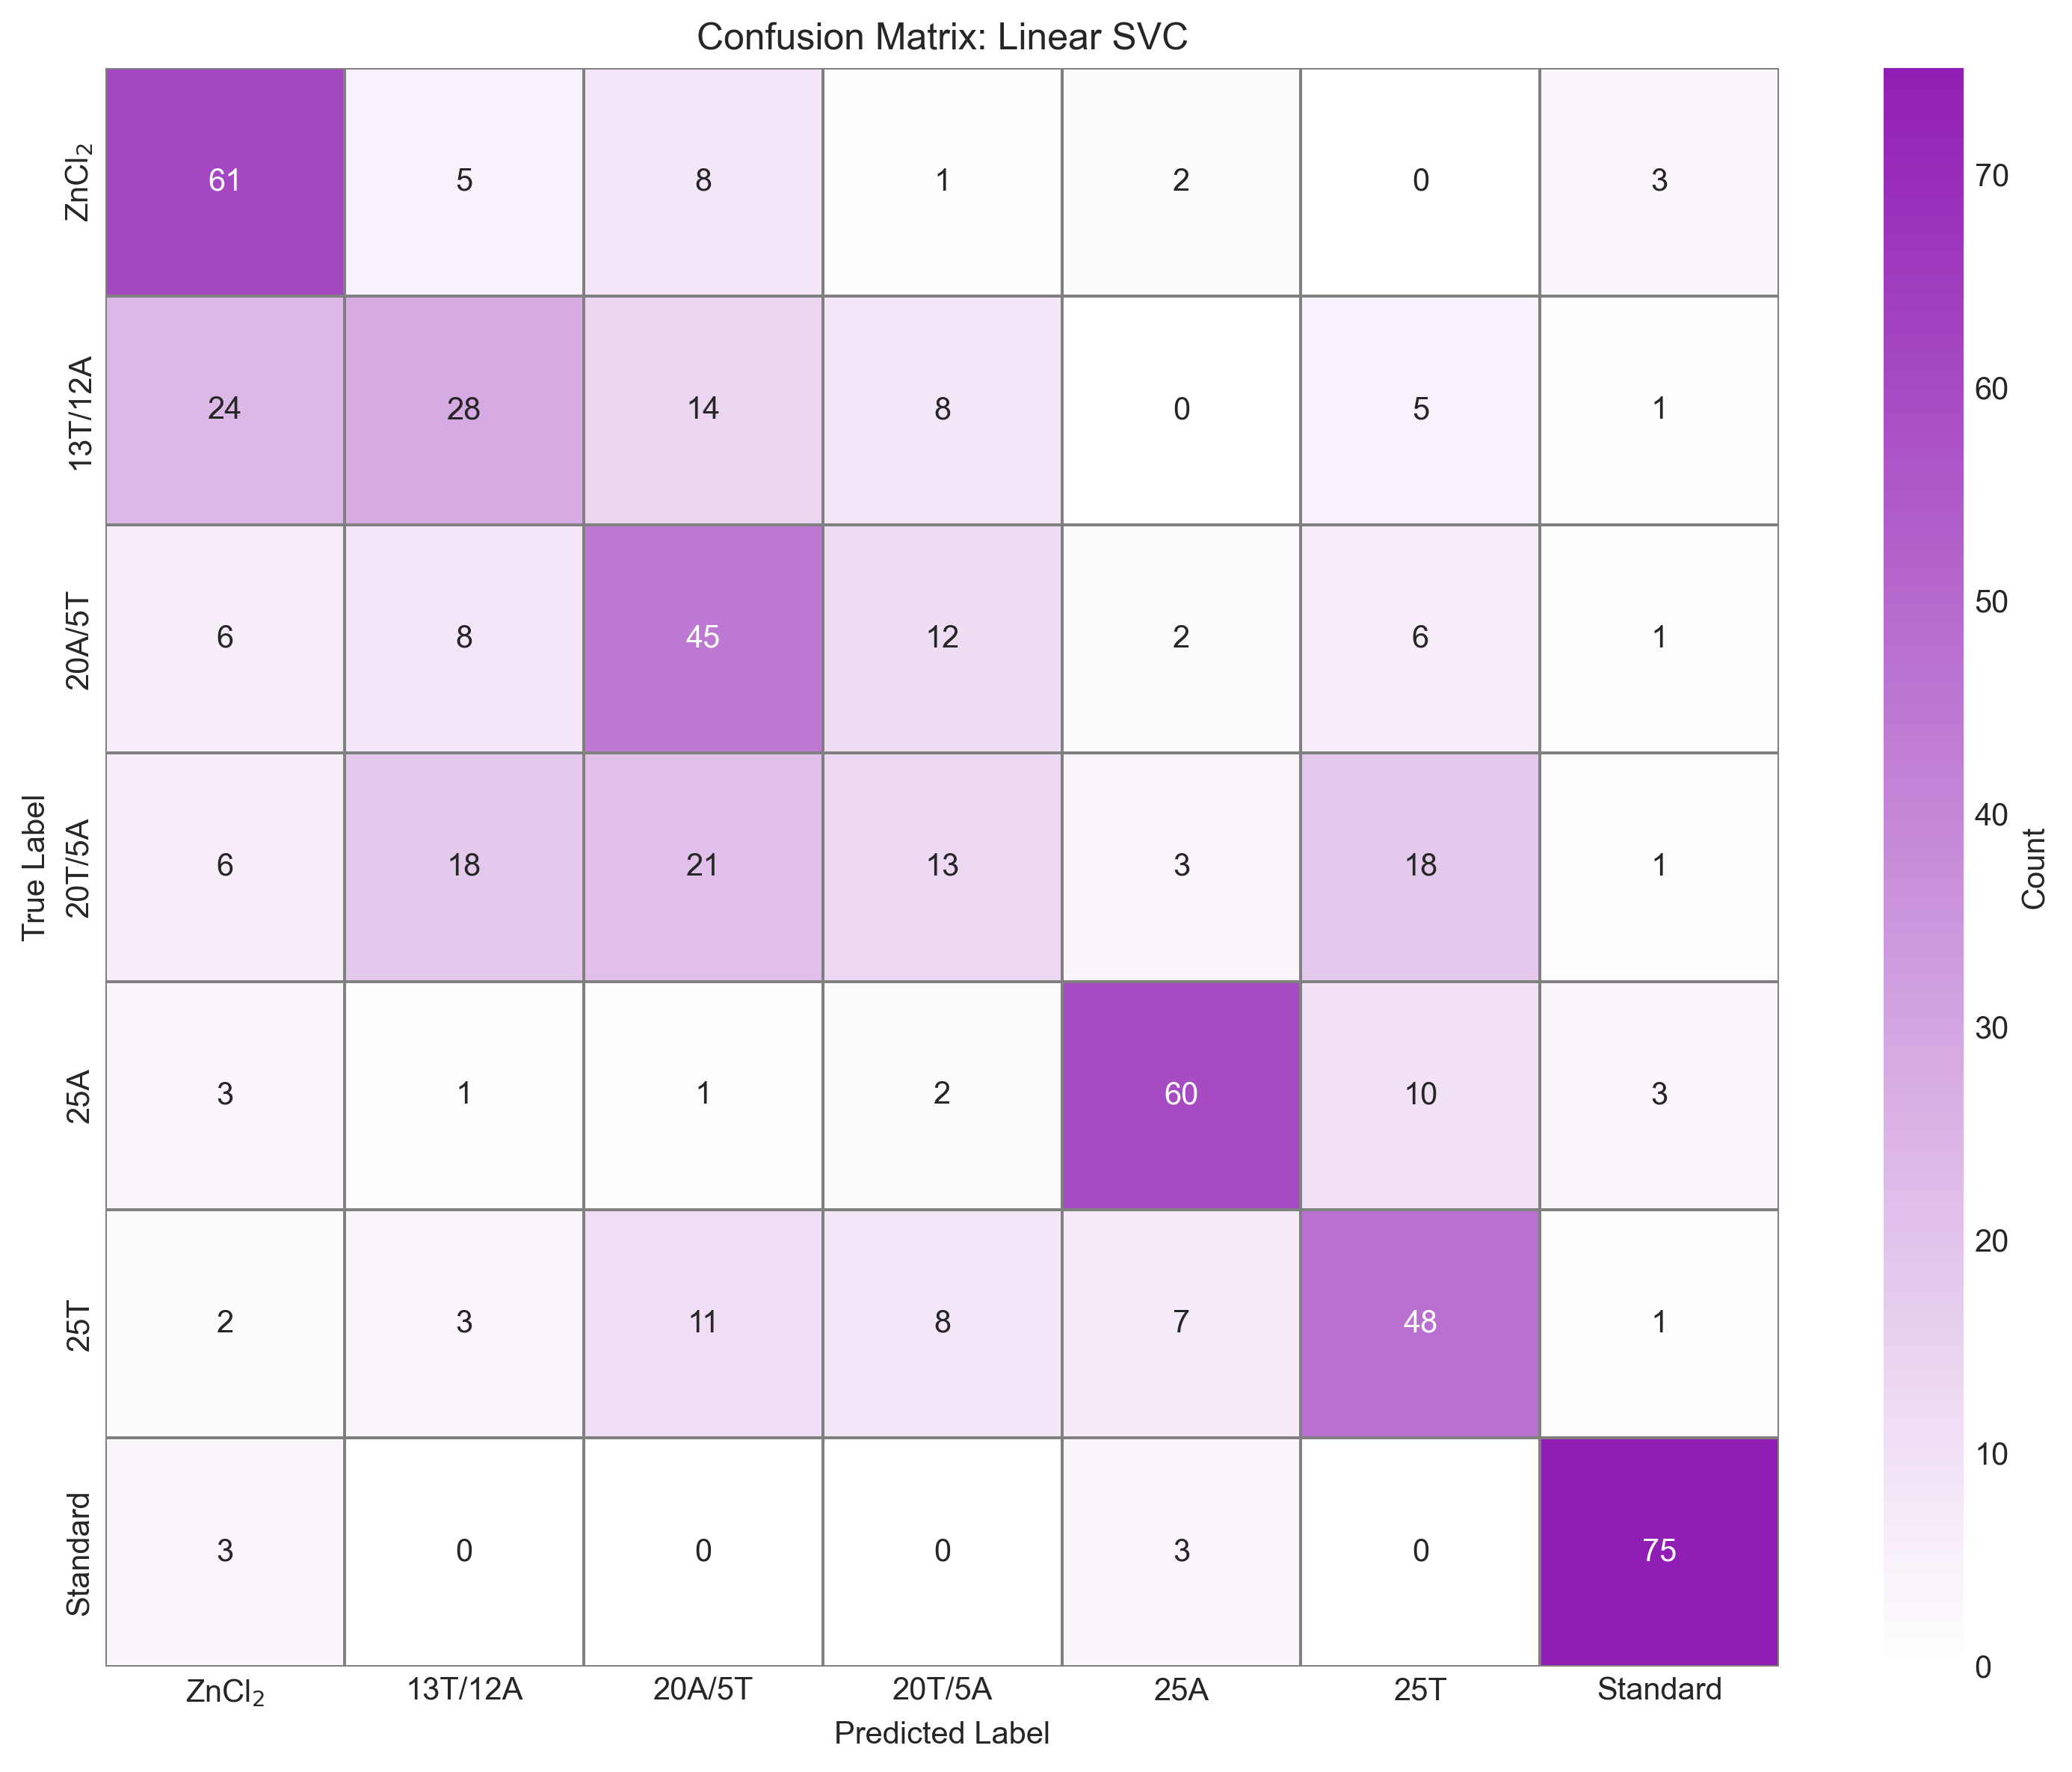

In [12]:
df = pd.read_csv("confusion_matrices/LinearSVC_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#911EB4' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Linear SVC')
plt.tight_layout()

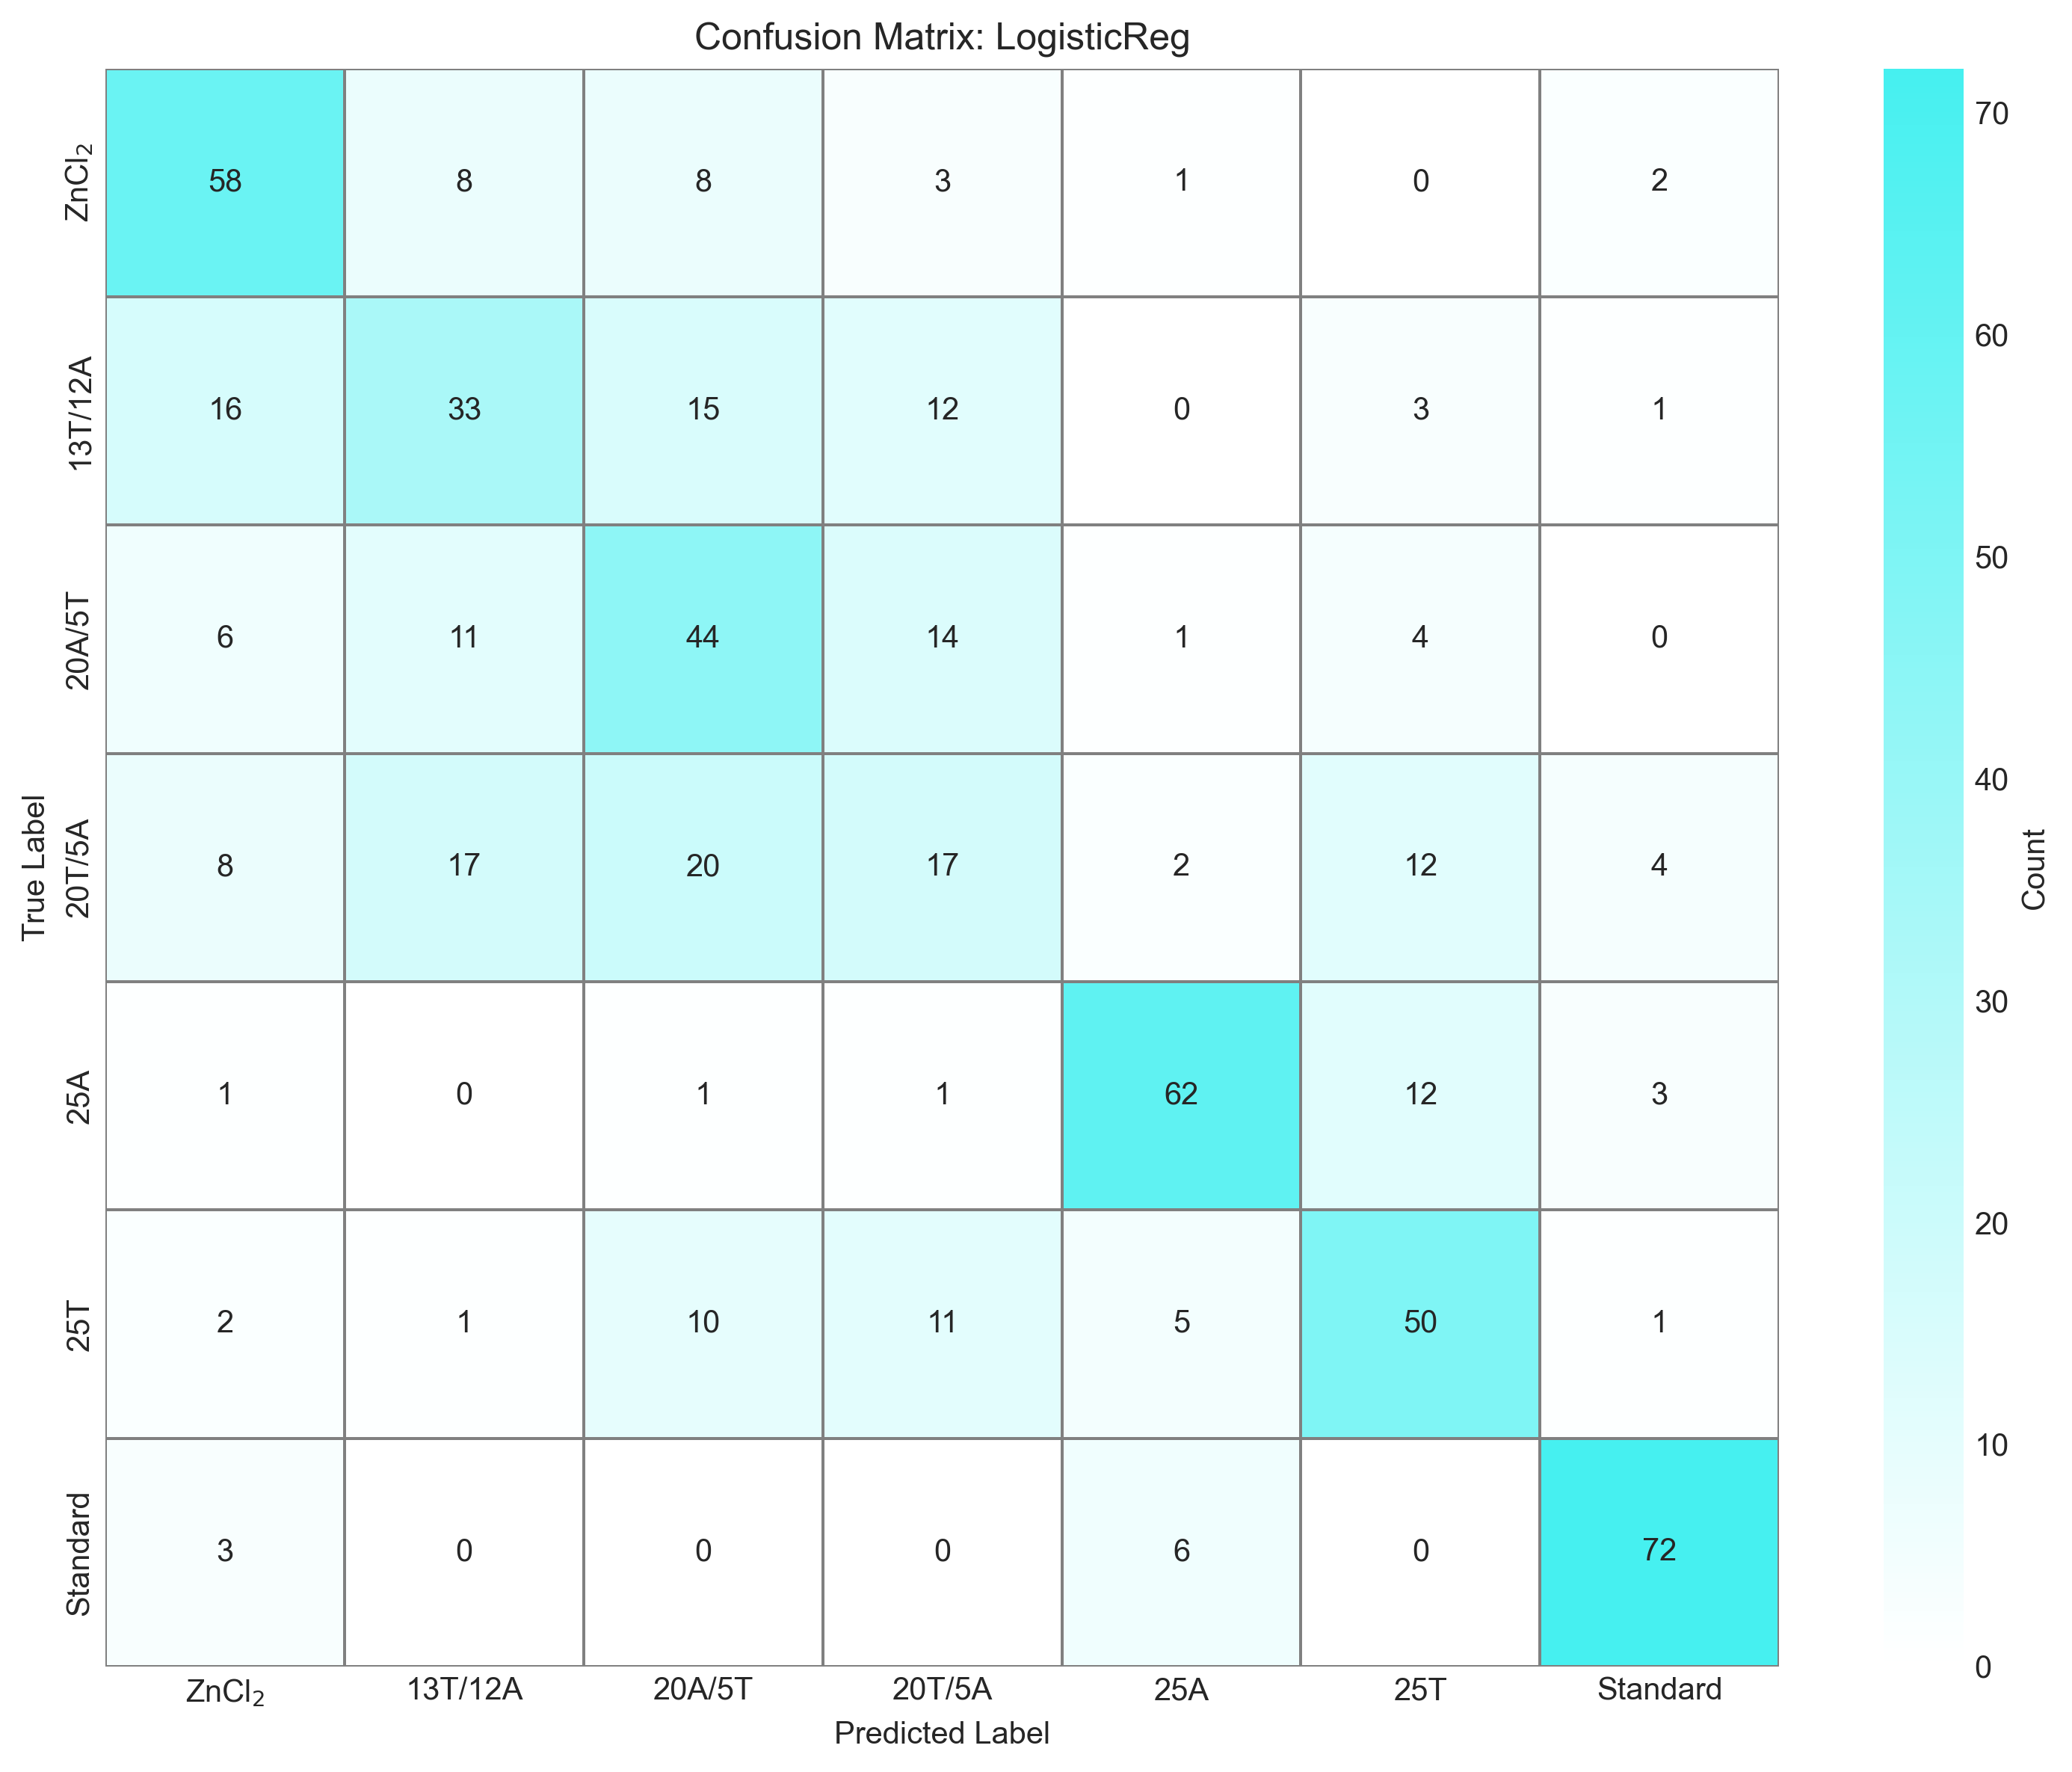

In [13]:
df = pd.read_csv("confusion_matrices/LogisticReg_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#46F0F0' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: LogisticReg')
plt.tight_layout()

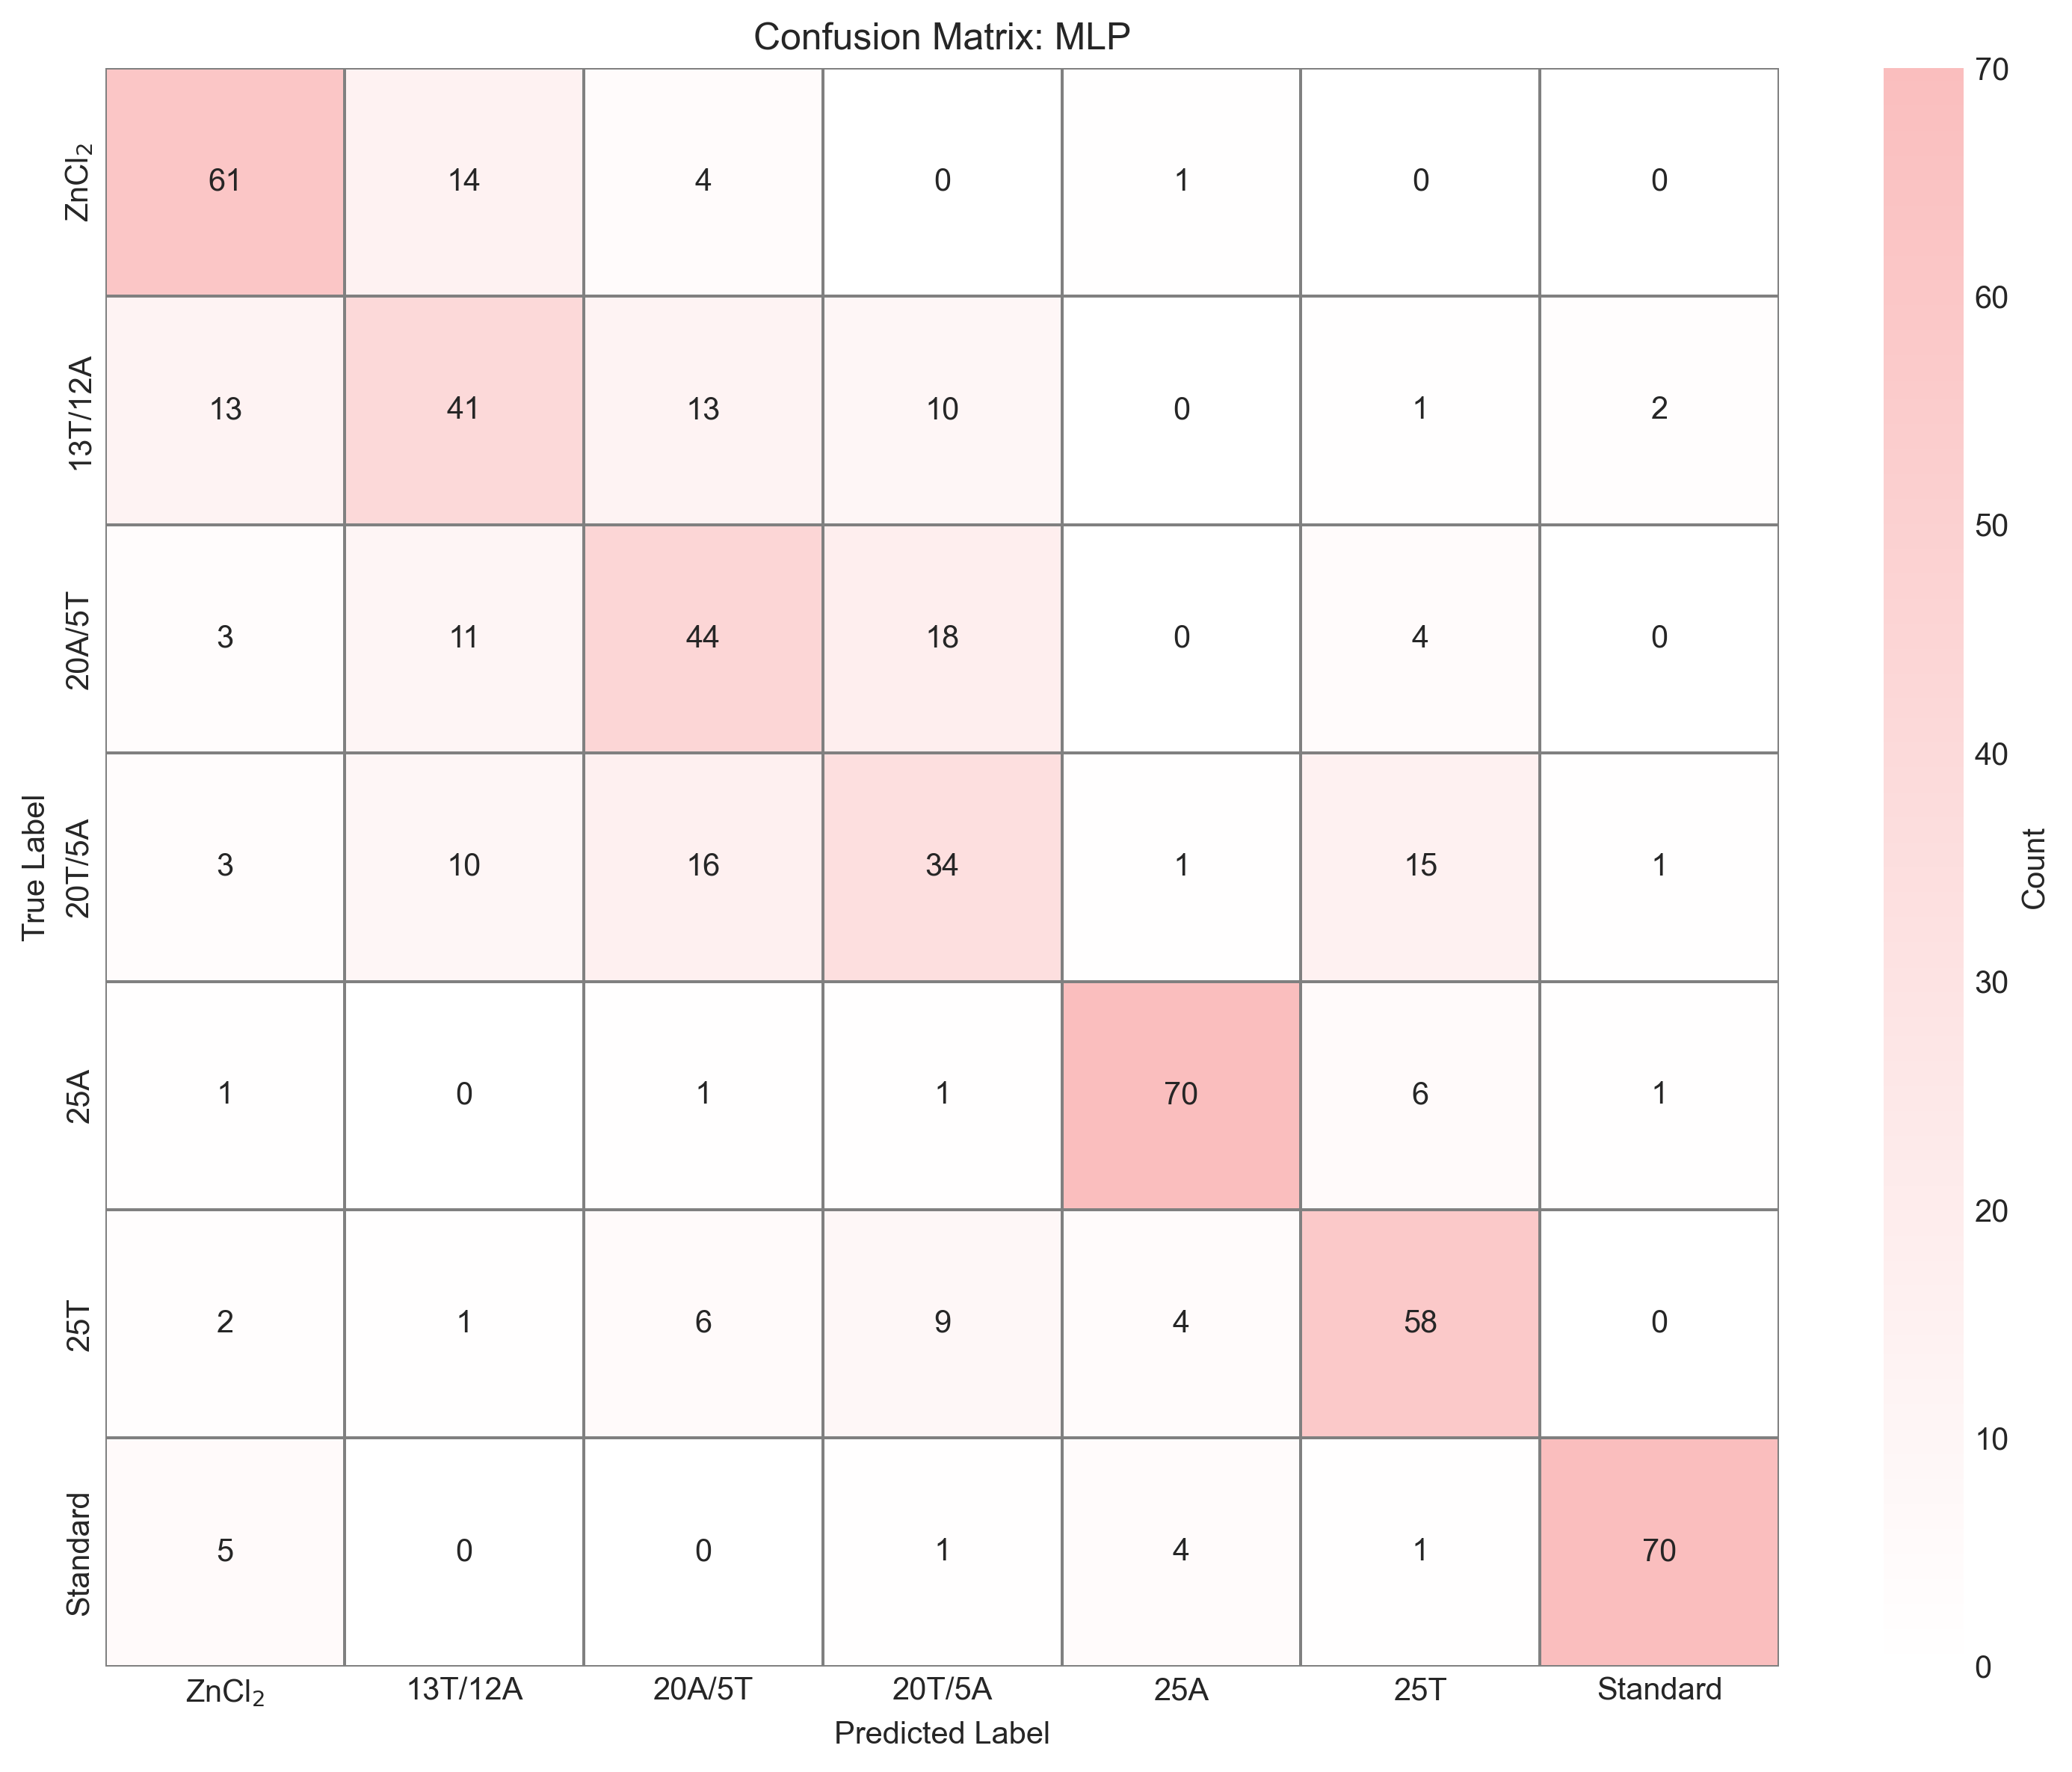

In [14]:
df = pd.read_csv("confusion_matrices/MLP_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#FABEBE' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: MLP')
plt.tight_layout()

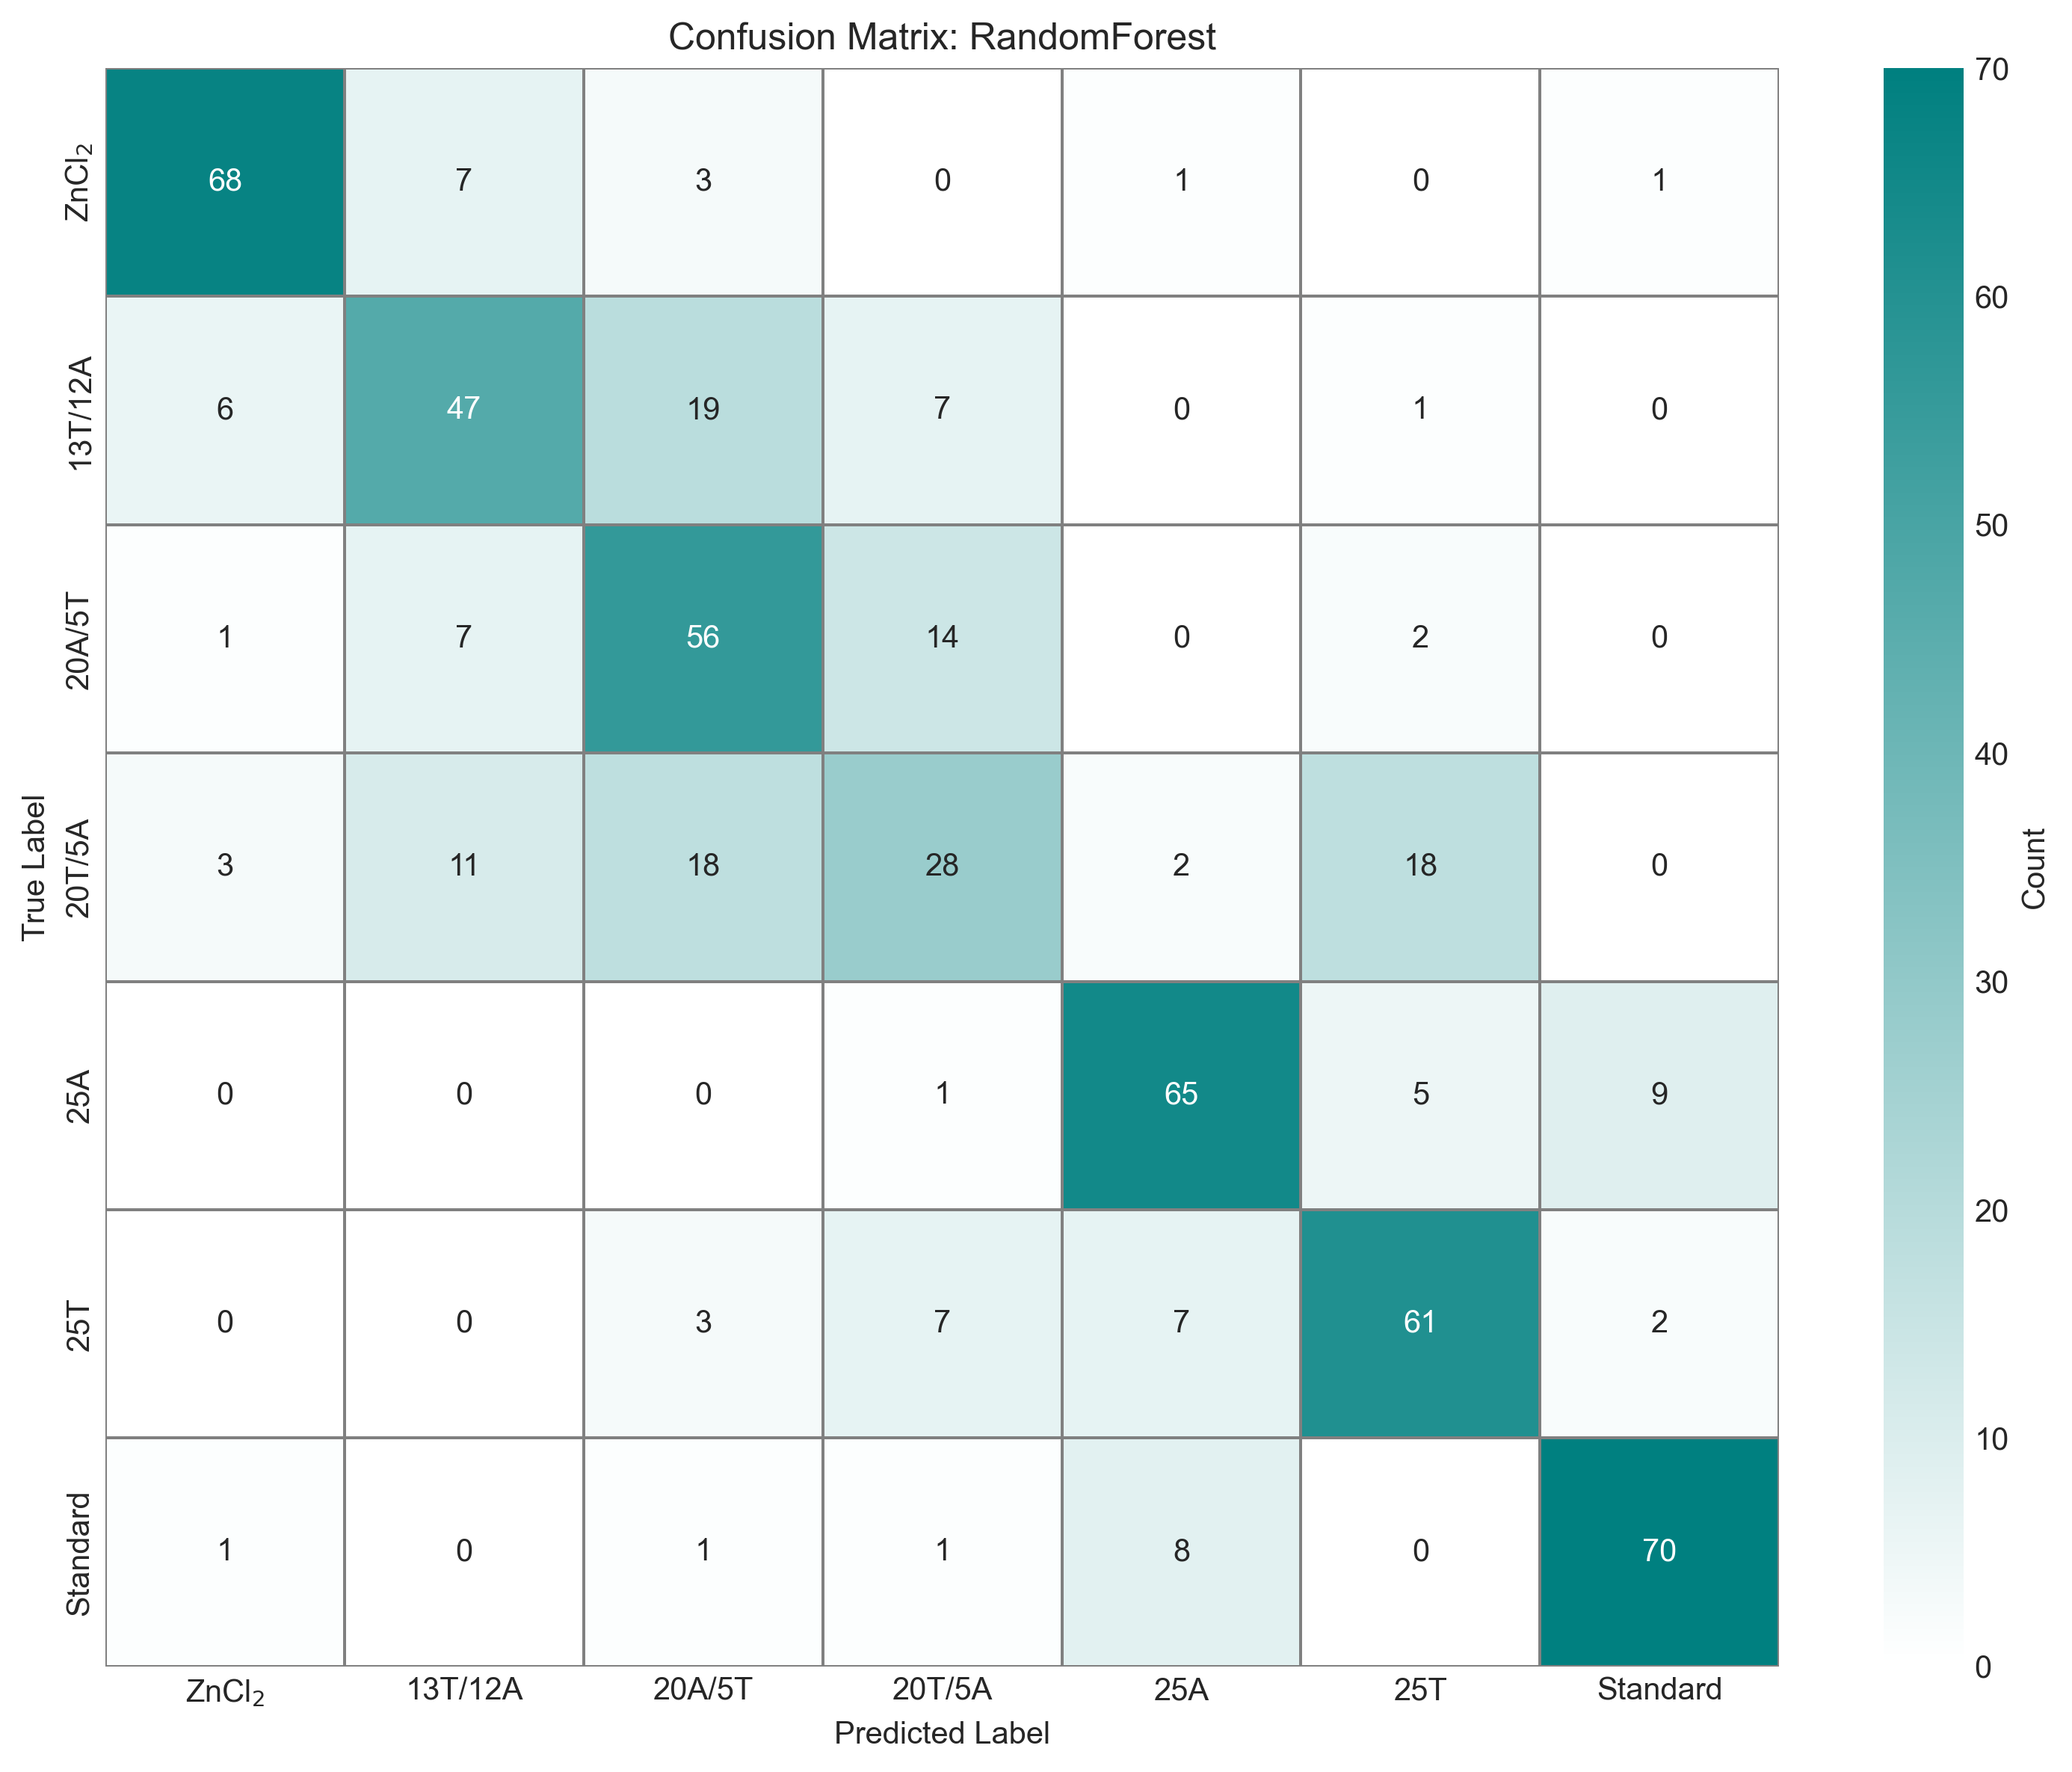

In [15]:
df = pd.read_csv("confusion_matrices/RandomForest_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#008080' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: RandomForest')
plt.tight_layout()

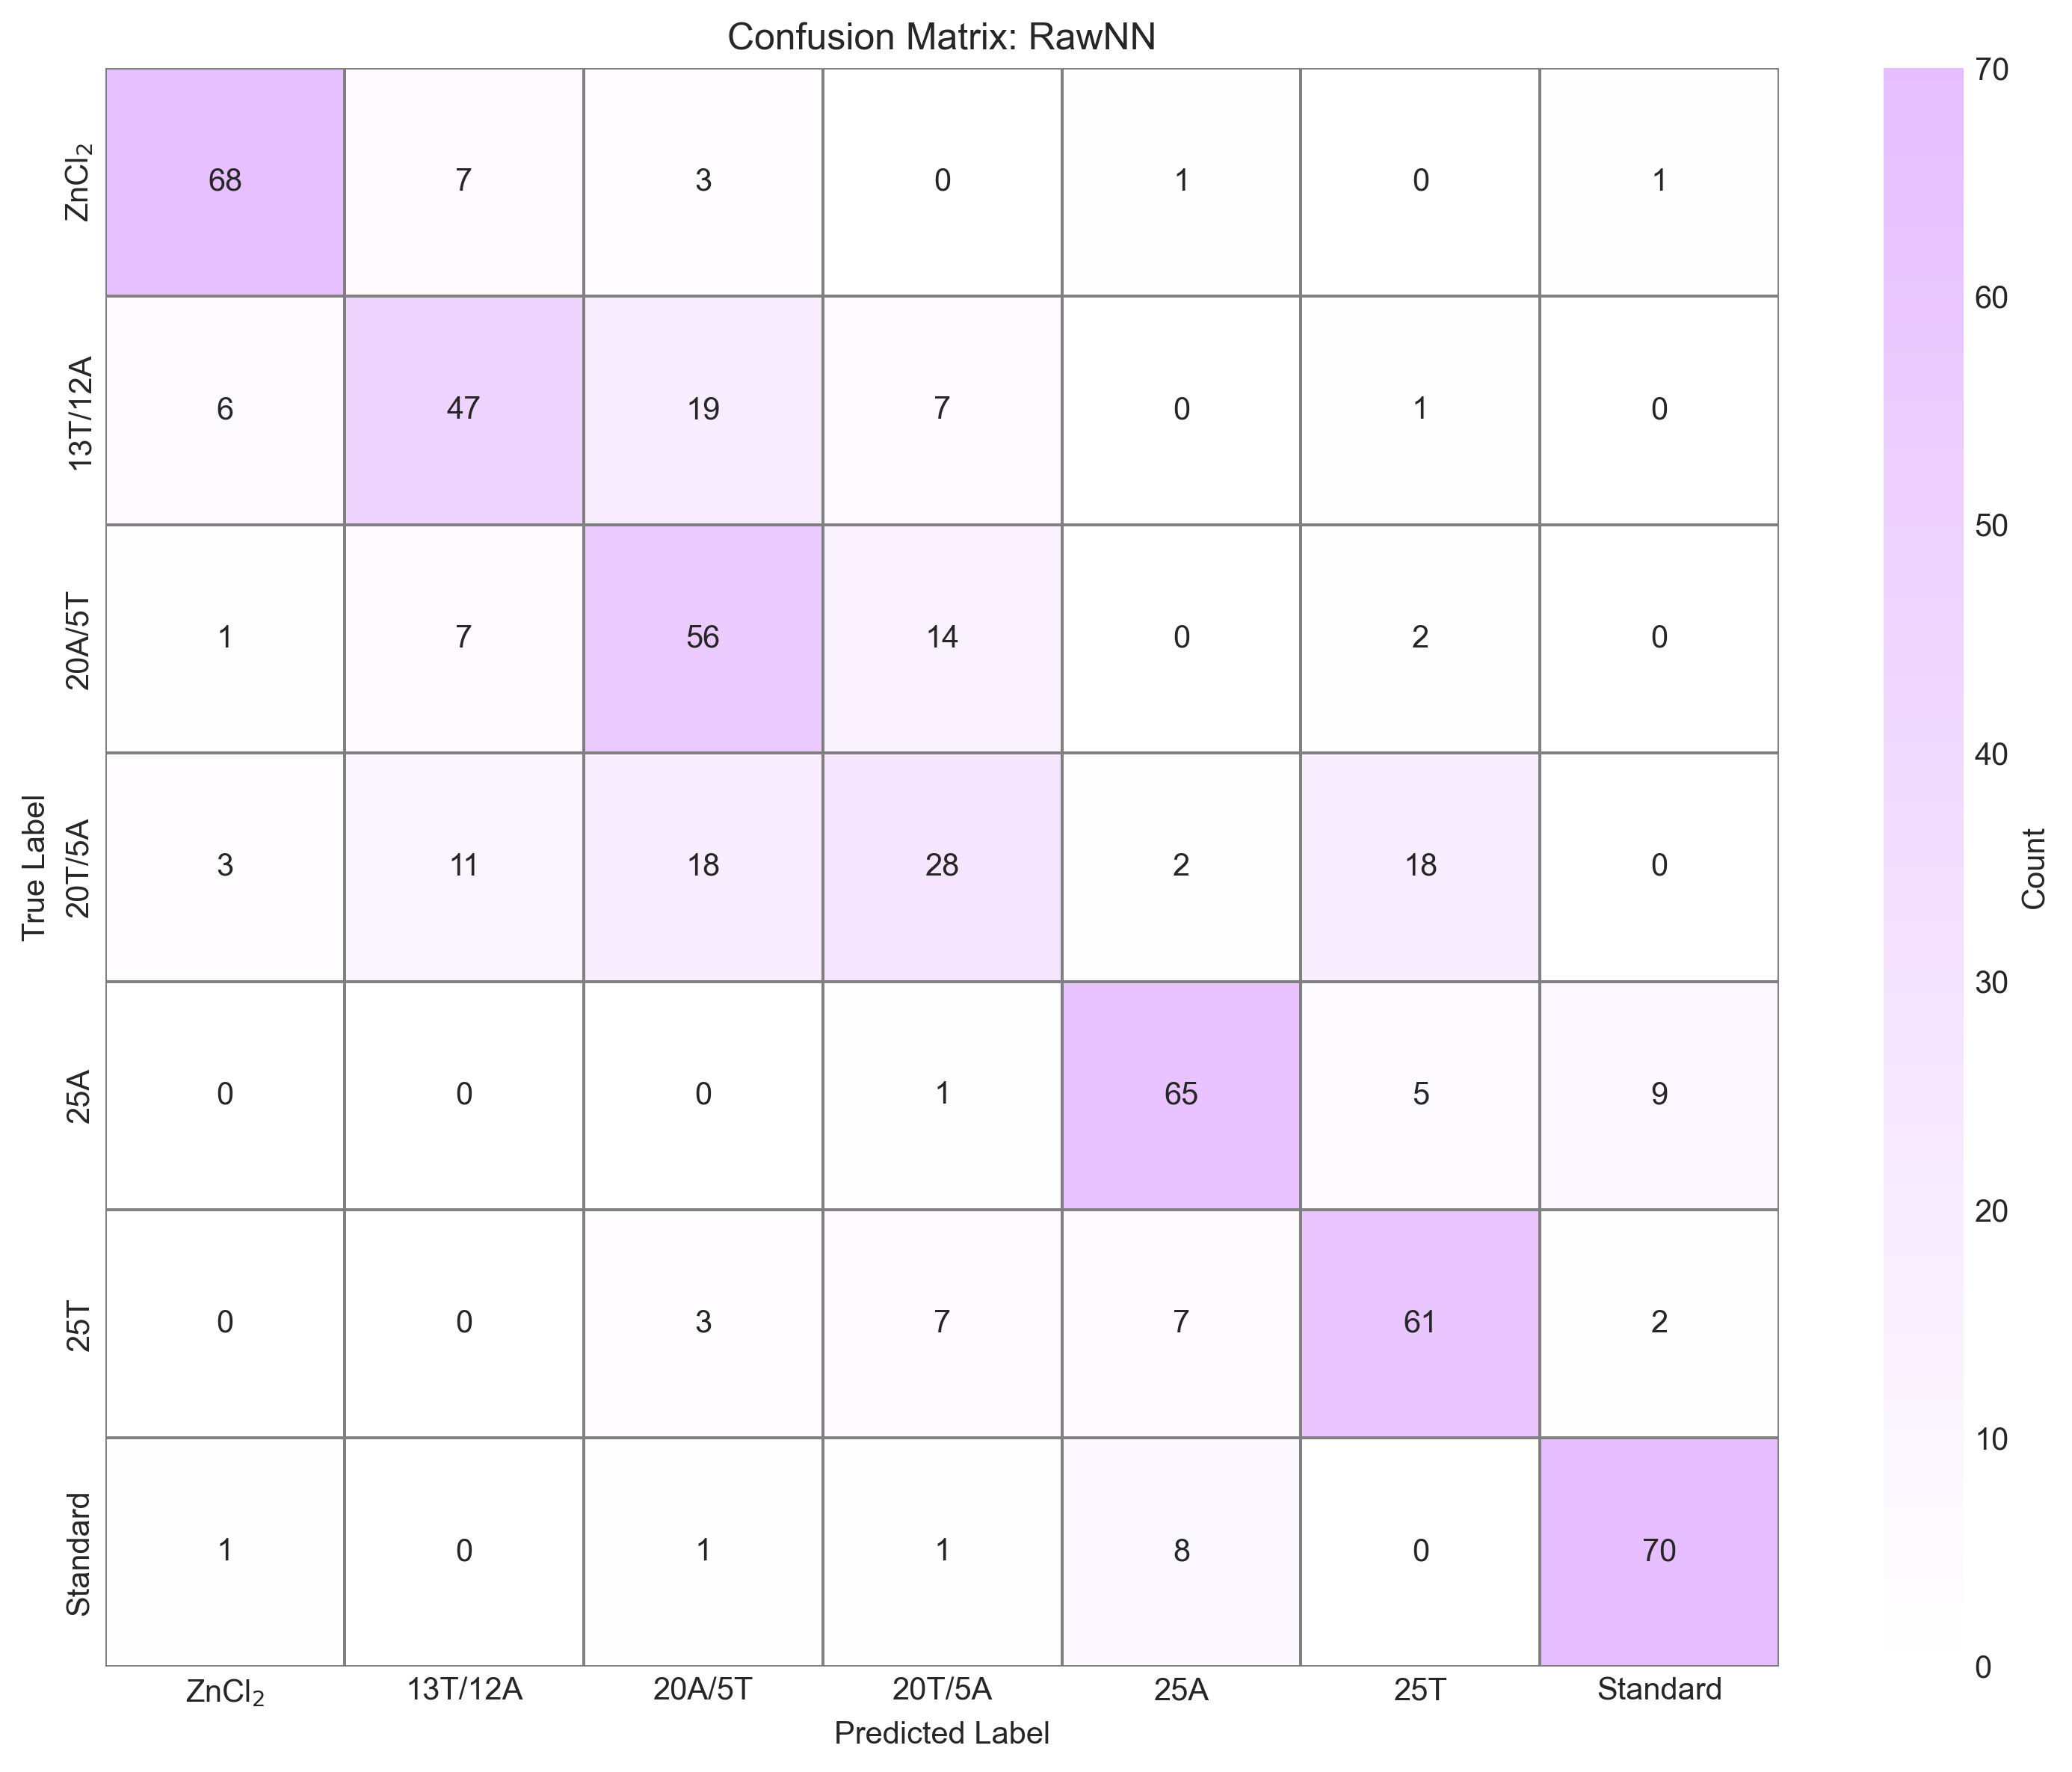

In [16]:
df = pd.read_csv("confusion_matrices/RawNN_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#E6BEFF' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: RawNN')
plt.tight_layout()

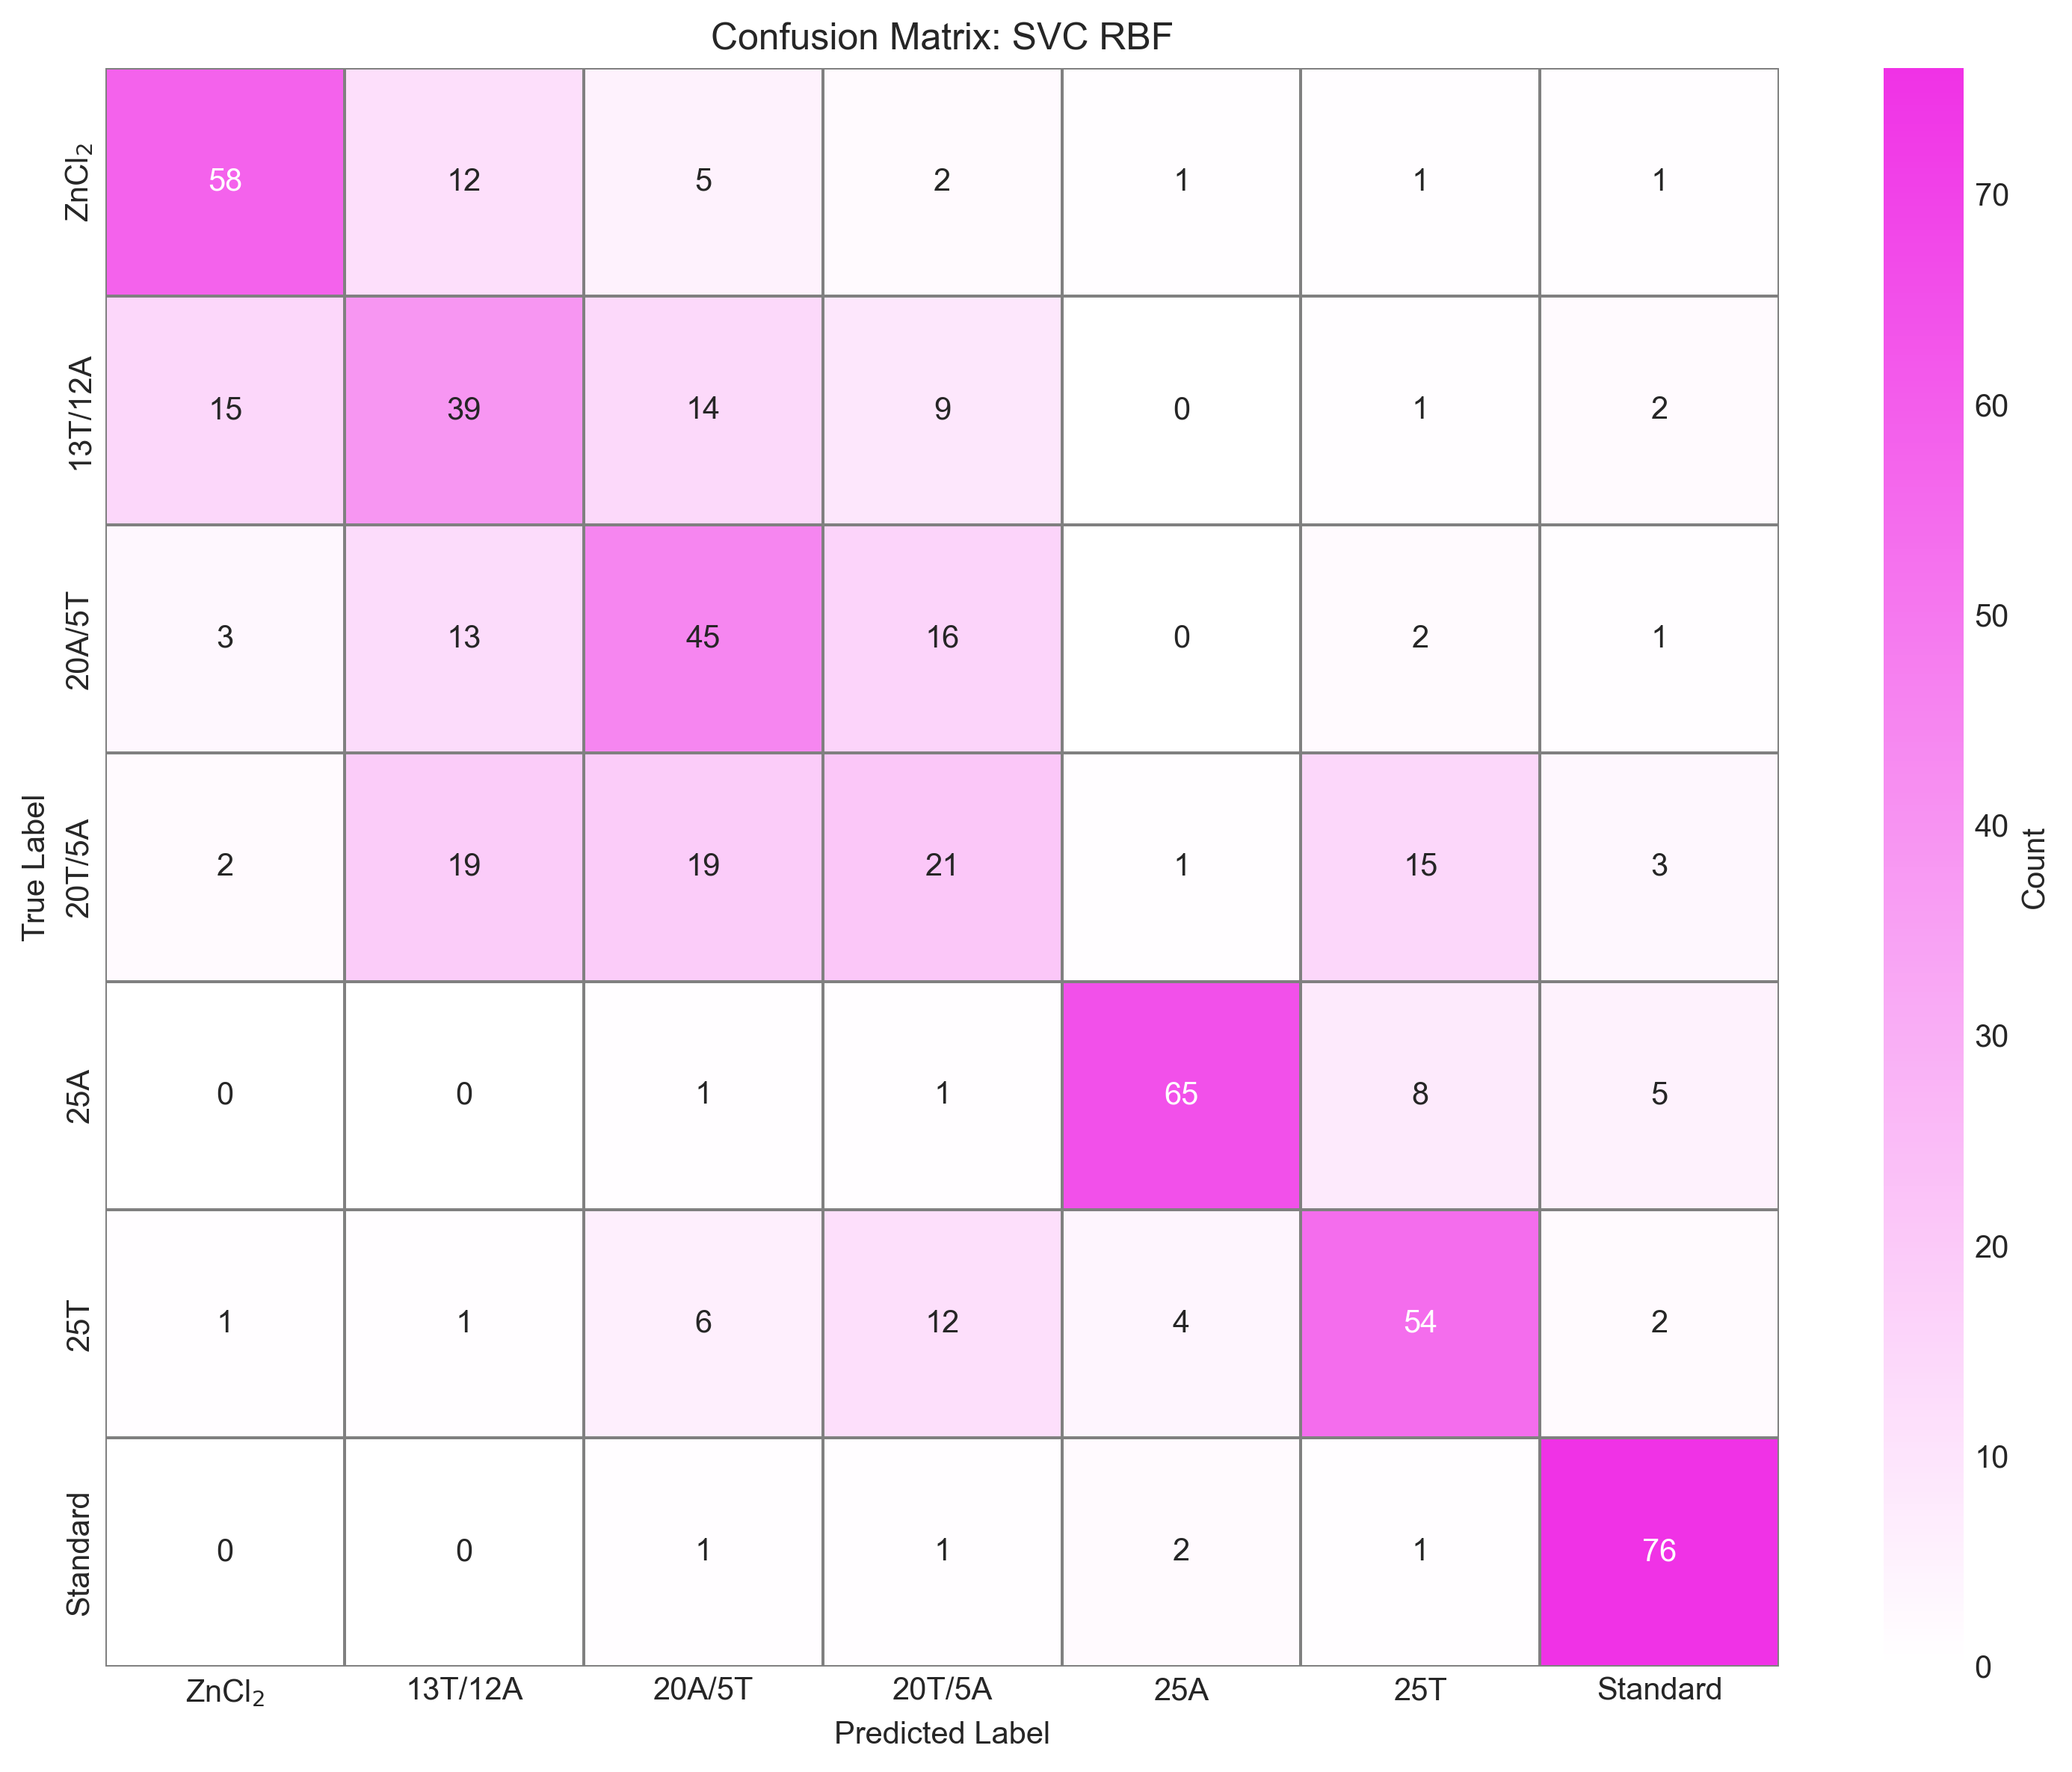

In [17]:
df = pd.read_csv("confusion_matrices/SVC_RBF_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#F032E6' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: SVC RBF')
plt.tight_layout()

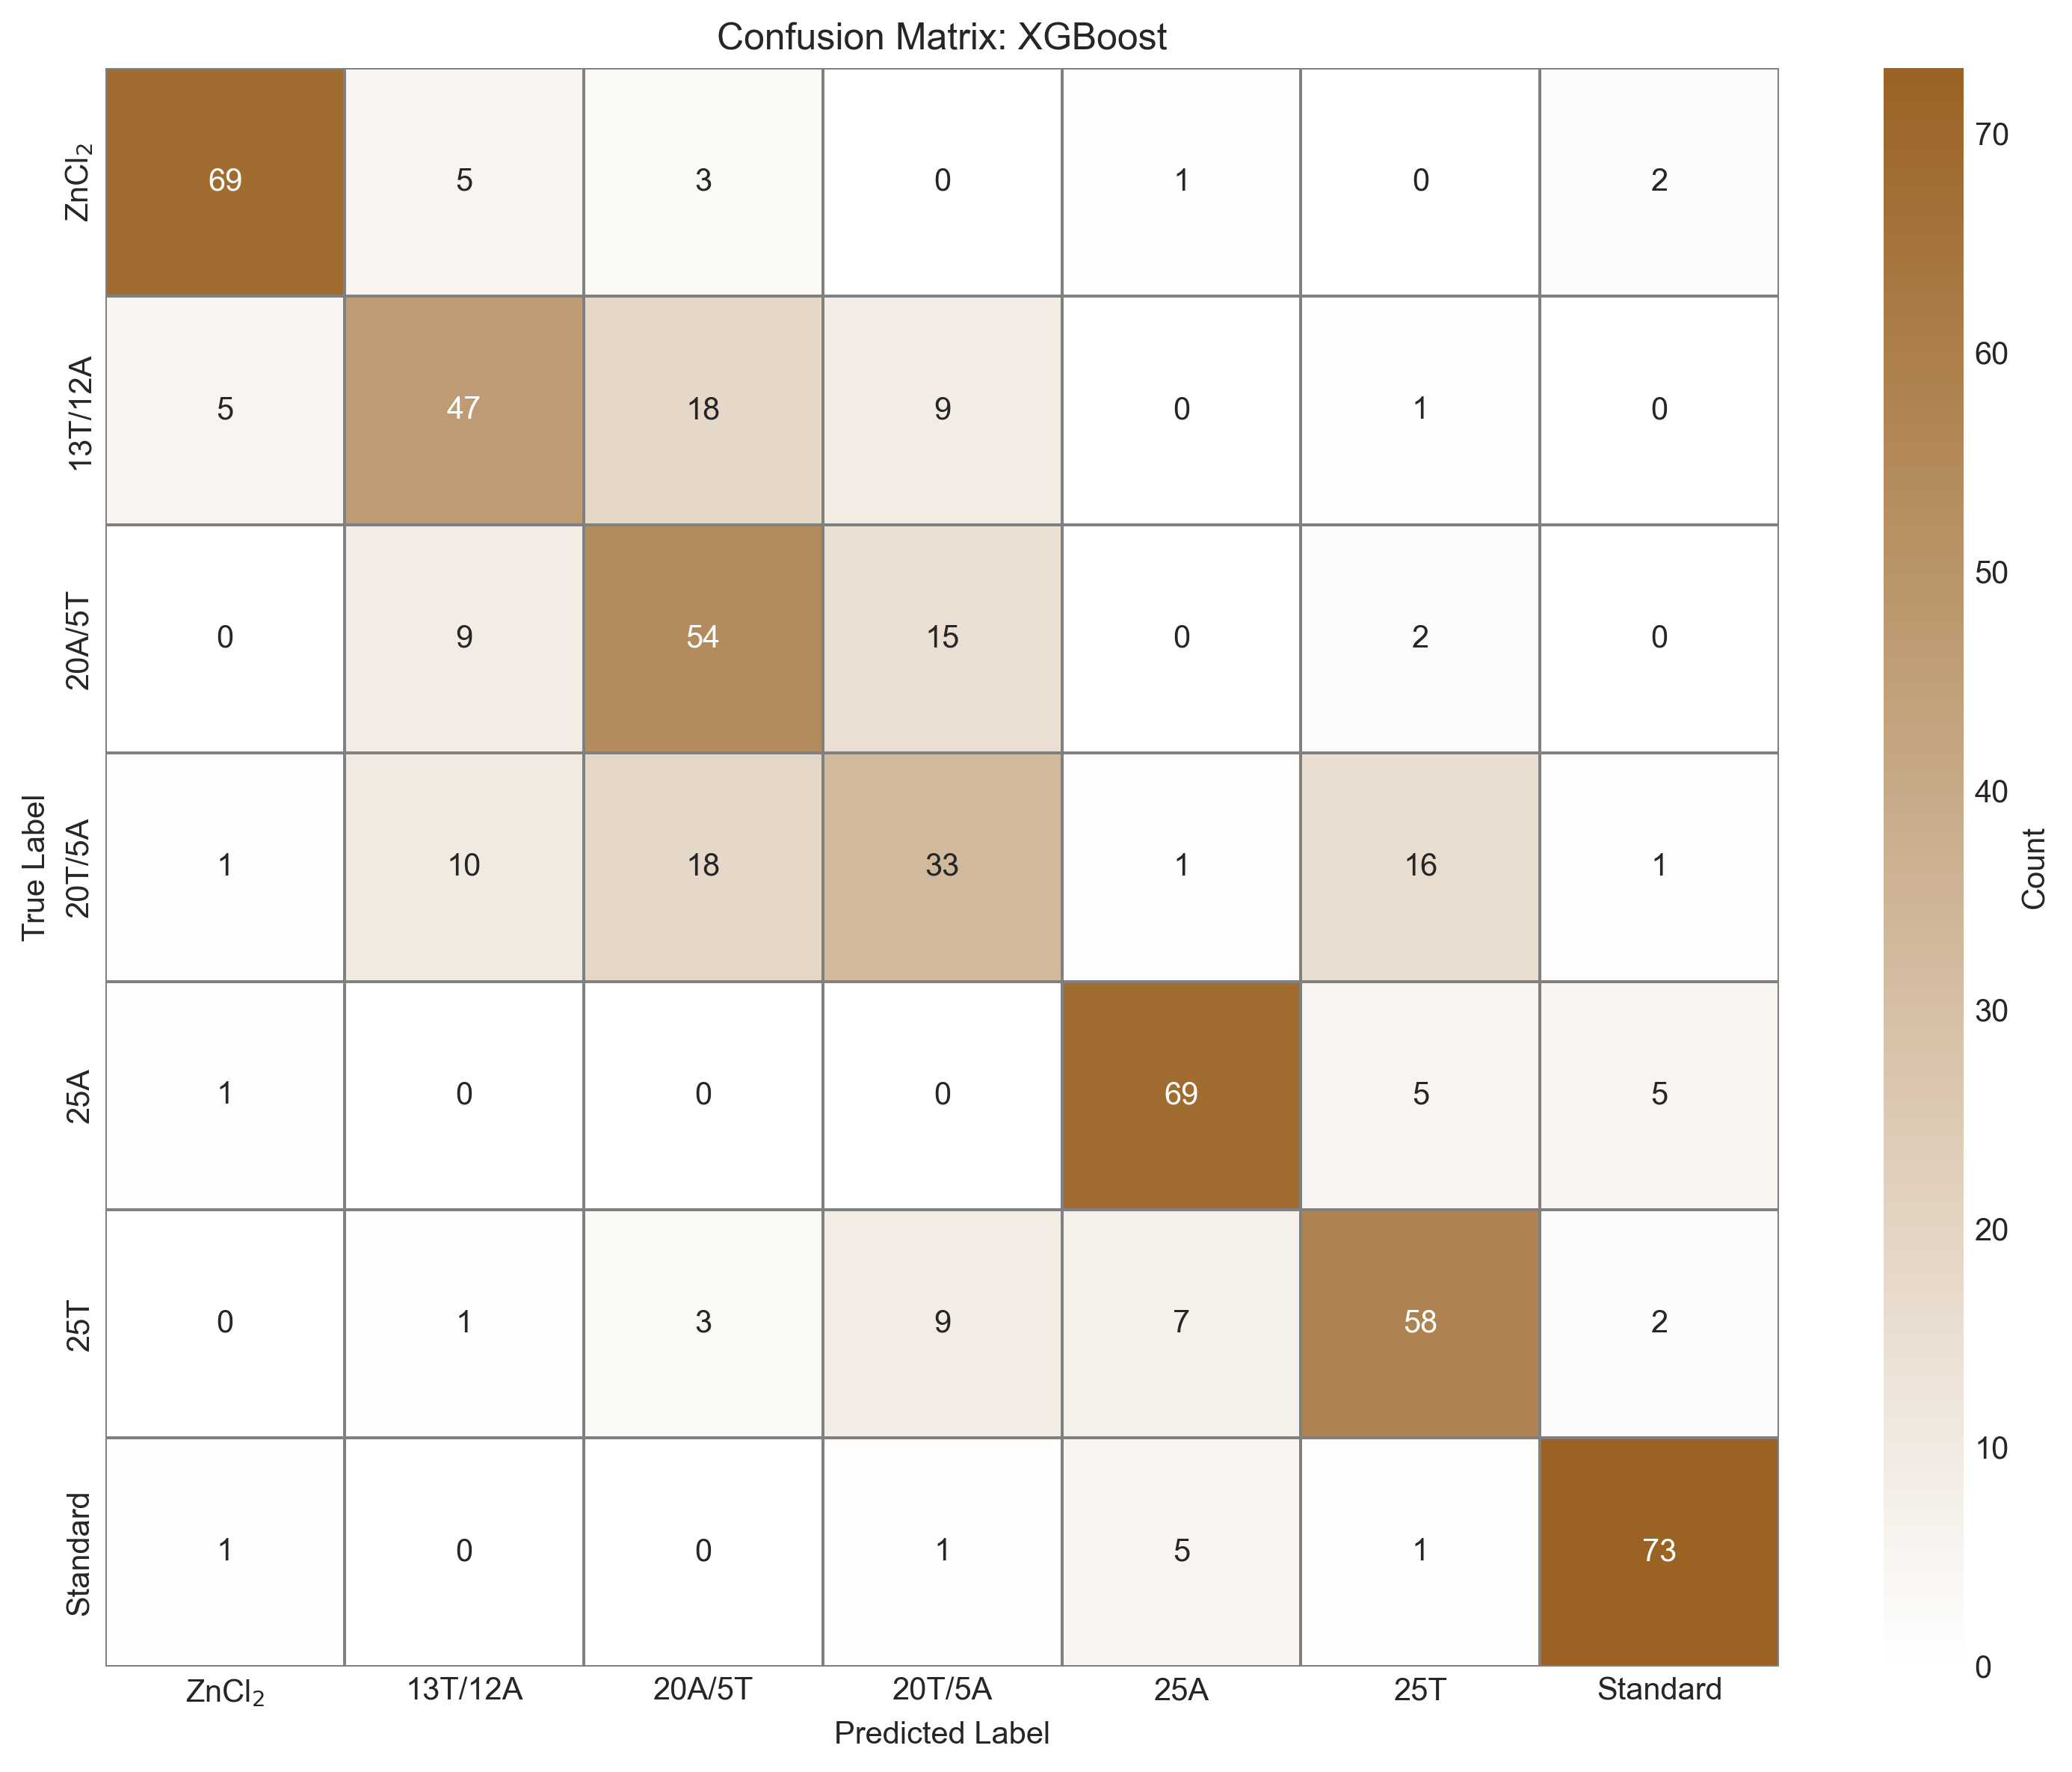

In [18]:
df = pd.read_csv("confusion_matrices/XGBoost_aggregated_cm.csv", index_col=0)
df.columns = df.columns.str.replace('Pred: ', '', regex=False)
df.index = df.index.str.replace('True: ', '', regex=False)

darkest_color_hex = '#9A6324' 
custom_colors = ["#FFFFFF", darkest_color_hex]
cmap_name = 'my_confusion_matrix_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, custom_colors, N=256)

cmap = custom_cmap

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    df.astype(int),
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Count'}
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: XGBoost')
plt.tight_layout()

# FAM Excitation and Emission Spectra

C:\Users\tjwil\AppData\Local\Temp\ipykernel_1480\1108135983.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


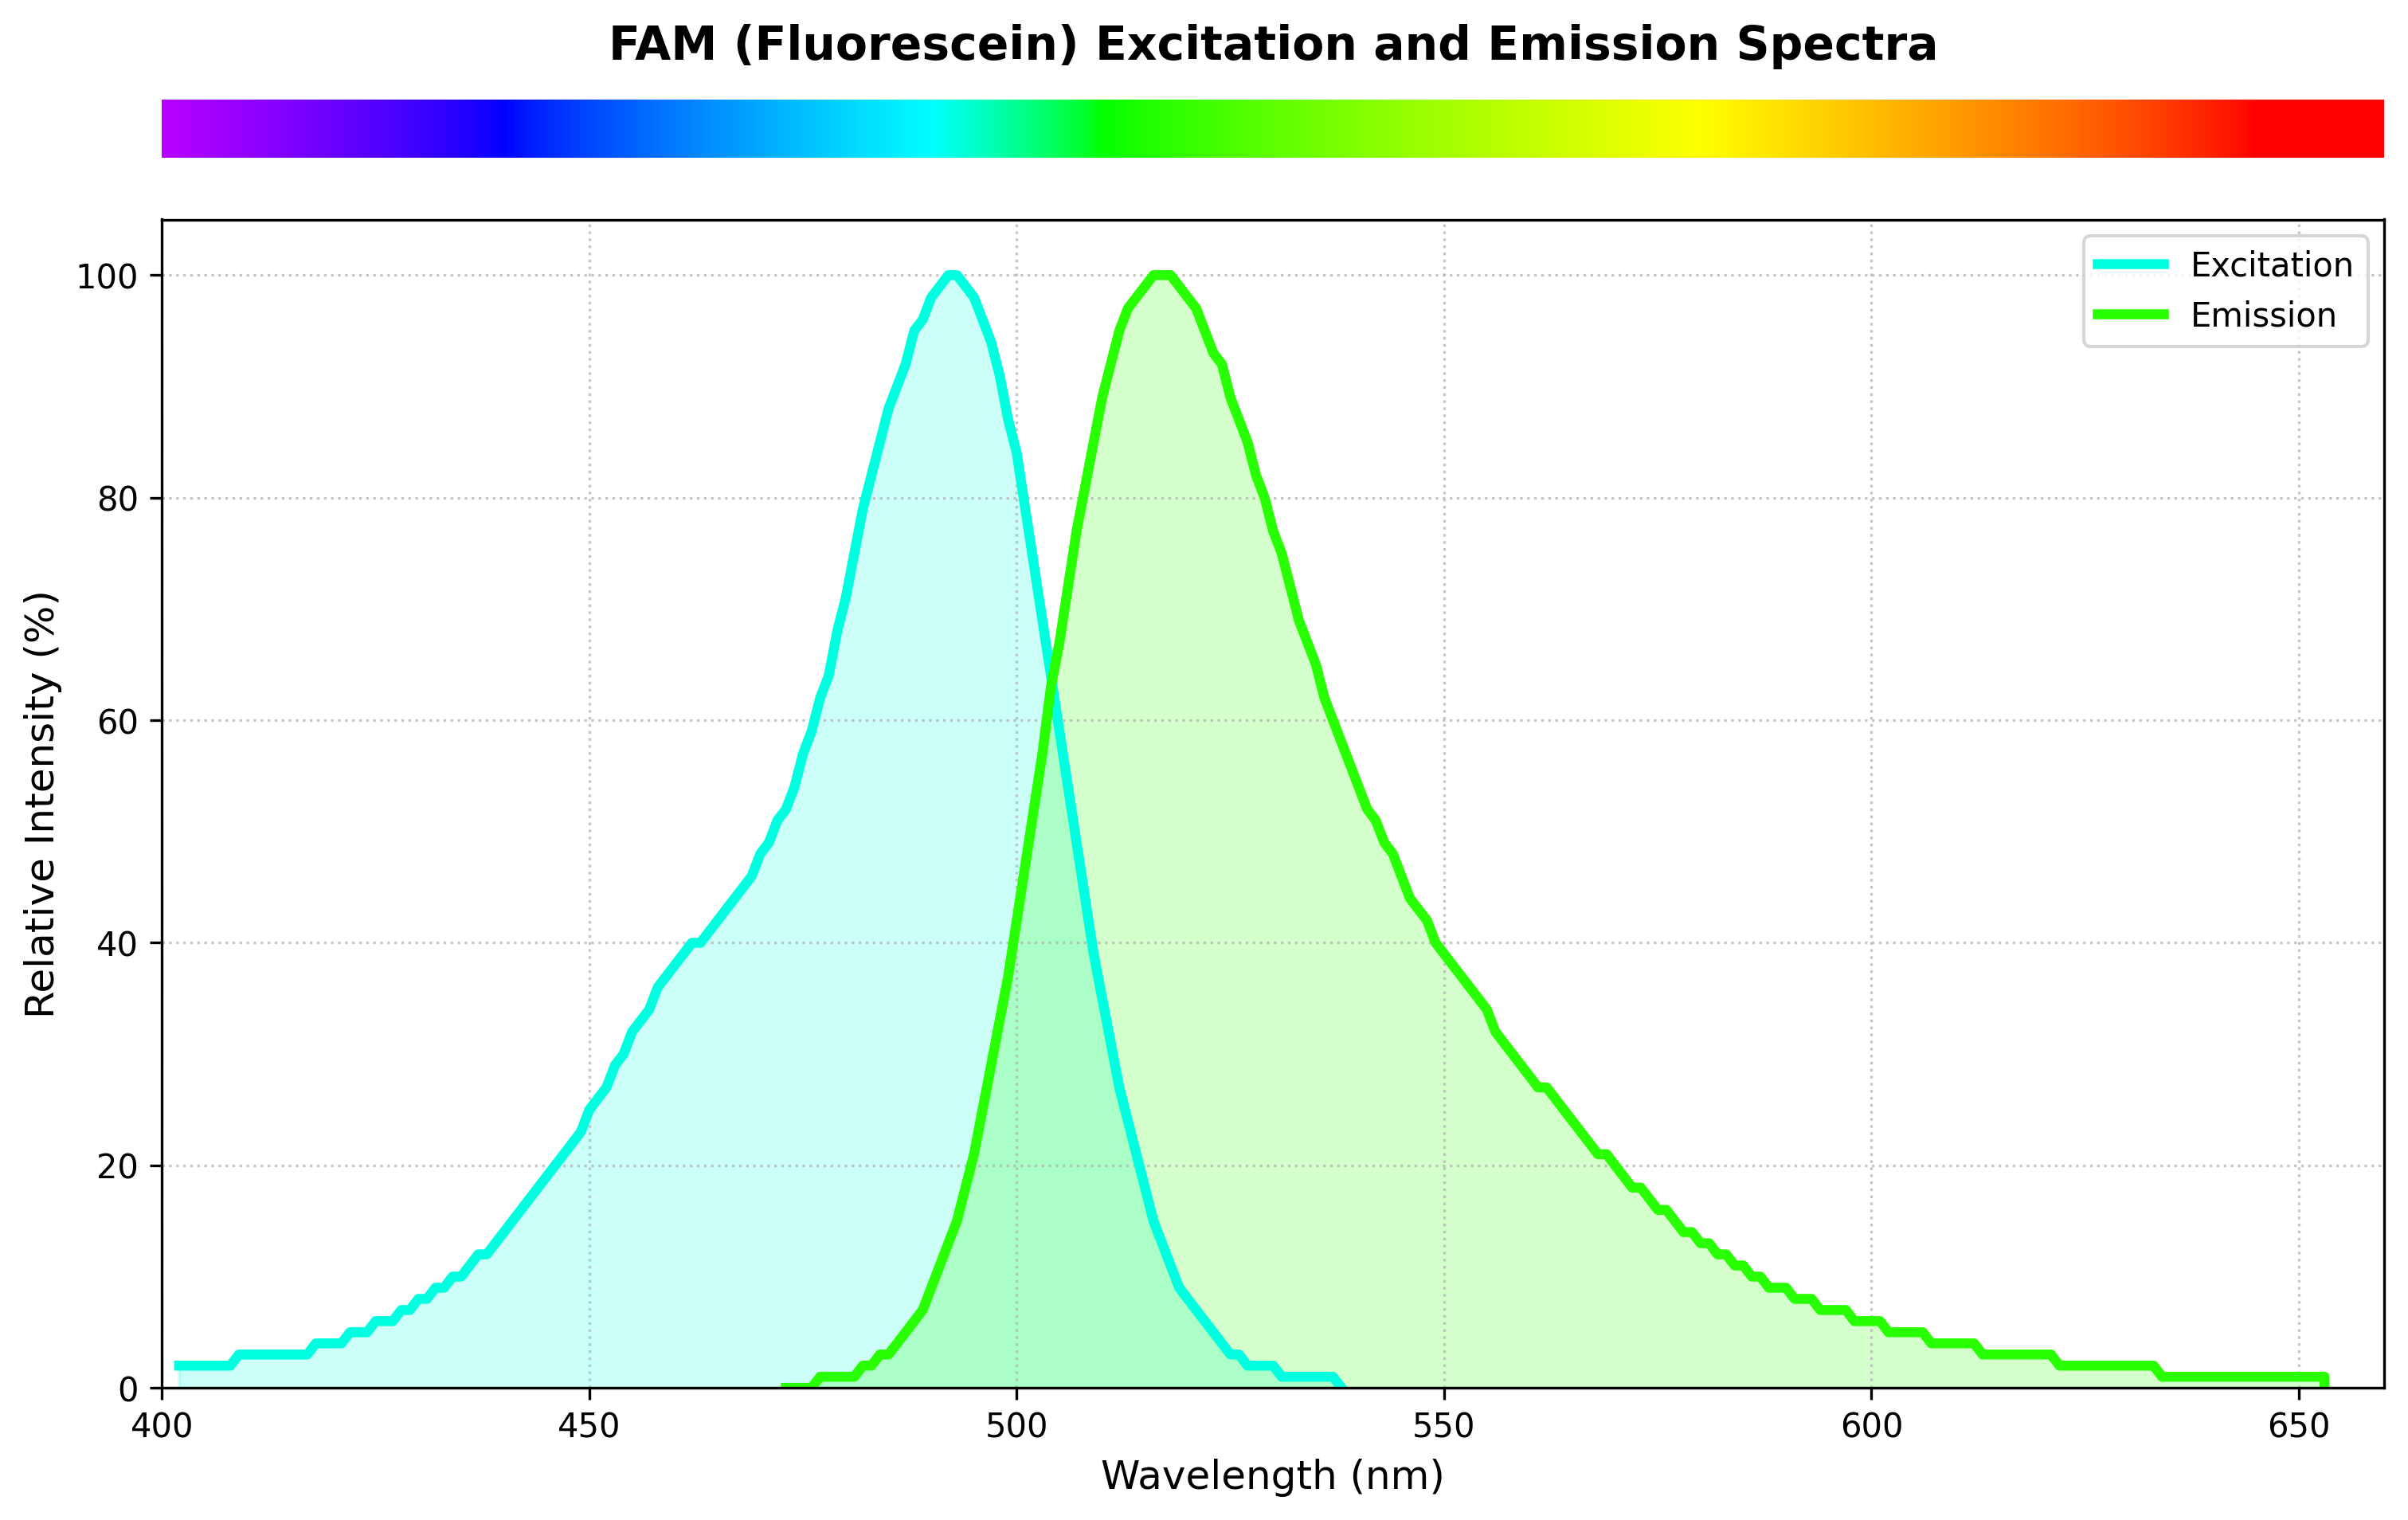

In [ ]:
# Full dataset for FAM
# Excitation data: [wavelength (nm), relative intensity (%)]
excitation = [
    [402, 2], [403, 2], [404, 2], [405, 2], [406, 2], [407, 2], [408, 2], [409, 3], [410, 3], [411, 3], 
    [412, 3], [413, 3], [414, 3], [415, 3], [416, 3], [417, 3], [418, 4], [419, 4], [420, 4], [421, 4], 
    [422, 5], [423, 5], [424, 5], [425, 6], [426, 6], [427, 6], [428, 7], [429, 7], [430, 8], [431, 8], 
    [432, 9], [433, 9], [434, 10], [435, 10], [436, 11], [437, 12], [438, 12], [439, 13], [440, 14], 
    [441, 15], [442, 16], [443, 17], [444, 18], [445, 19], [446, 20], [447, 21], [448, 22], [449, 23], 
    [450, 25], [451, 26], [452, 27], [453, 29], [454, 30], [455, 32], [456, 33], [457, 34], [458, 36], 
    [459, 37], [460, 38], [461, 39], [462, 40], [463, 40], [464, 41], [465, 42], [466, 43], [467, 44], 
    [468, 45], [469, 46], [470, 48], [471, 49], [472, 51], [473, 52], [474, 54], [475, 57], [476, 59], 
    [477, 62], [478, 64], [479, 68], [480, 71], [481, 75], [482, 79], [483, 82], [484, 85], [485, 88], 
    [486, 90], [487, 92], [488, 95], [489, 96], [490, 98], [491, 99], [492, 100], [493, 100], [494, 99], 
    [495, 98], [496, 96], [497, 94], [498, 91], [499, 87], [500, 84], [501, 79], [502, 74], [503, 69], 
    [504, 64], [505, 59], [506, 54], [507, 49], [508, 44], [509, 39], [510, 35], [511, 31], [512, 27], 
    [513, 24], [514, 21], [515, 18], [516, 15], [517, 13], [518, 11], [519, 9], [520, 8], [521, 7], 
    [522, 6], [523, 5], [524, 4], [525, 3], [526, 3], [527, 2], [528, 2], [529, 2], [530, 2], [531, 1], 
    [532, 1], [533, 1], [534, 1], [535, 1], [536, 1], [537, 1], [538, 0]
]

# Emission data: [wavelength (nm), relative intensity (%)]
emission = [
    [473, 0], [474, 0], [475, 0], [476, 0], [477, 1], [478, 1], [479, 1], [480, 1], [481, 1], [482, 2], 
    [483, 2], [484, 3], [485, 3], [486, 4], [487, 5], [488, 6], [489, 7], [490, 9], [491, 11], [492, 13], 
    [493, 15], [494, 18], [495, 21], [496, 25], [497, 29], [498, 33], [499, 37], [500, 42], [501, 47], 
    [502, 52], [503, 57], [504, 63], [505, 67], [506, 72], [507, 77], [508, 81], [509, 85], [510, 89], 
    [511, 92], [512, 95], [513, 97], [514, 98], [515, 99], [516, 100], [517, 100], [518, 100], [519, 99], 
    [520, 98], [521, 97], [522, 95], [523, 93], [524, 92], [525, 89], [526, 87], [527, 85], [528, 82], 
    [529, 80], [530, 77], [531, 75], [532, 72], [533, 69], [534, 67], [535, 65], [536, 62], [537, 60], 
    [538, 58], [539, 56], [540, 54], [541, 52], [542, 51], [543, 49], [544, 48], [545, 46], [546, 44], 
    [547, 43], [548, 42], [549, 40], [550, 39], [551, 38], [552, 37], [553, 36], [554, 35], [555, 34], 
    [556, 32], [557, 31], [558, 30], [559, 29], [560, 28], [561, 27], [562, 27], [563, 26], [564, 25], 
    [565, 24], [566, 23], [567, 22], [568, 21], [569, 21], [570, 20], [571, 19], [572, 18], [573, 18], 
    [574, 17], [575, 16], [576, 16], [577, 15], [578, 14], [579, 14], [580, 13], [581, 13], [582, 12], 
    [583, 12], [584, 11], [585, 11], [586, 10], [587, 10], [588, 9], [589, 9], [590, 9], [591, 8], 
    [592, 8], [593, 8], [594, 7], [595, 7], [596, 7], [597, 7], [598, 6], [599, 6], [600, 6], [601, 6], 
    [602, 5], [603, 5], [604, 5], [605, 5], [606, 5], [607, 4], [608, 4], [609, 4], [610, 4], [611, 4], 
    [612, 4], [613, 3], [614, 3], [615, 3], [616, 3], [617, 3], [618, 3], [619, 3], [620, 3], [621, 3], 
    [622, 2], [623, 2], [624, 2], [625, 2], [626, 2], [627, 2], [628, 2], [629, 2], [630, 2], [631, 2], 
    [632, 2], [633, 2], [634, 1], [635, 1], [636, 1], [637, 1], [638, 1], [639, 1], [640, 1], [641, 1], 
    [642, 1], [643, 1], [644, 1], [645, 1], [646, 1], [647, 1], [648, 1], [649, 1], [650, 1], [651, 1], 
    [652, 1], [653, 1], [653, 0]
]

def wavelength_to_rgb(wavelength):
    """Accurate conversion of wavelength to RGB for peak-matched colouring."""
    gamma = 0.8
    if 380 <= wavelength <= 440:
        red, green, blue = -(wavelength - 440) / (440 - 380), 0.0, 1.0
    elif 440 <= wavelength <= 490:
        red, green, blue = 0.0, (wavelength - 440) / (490 - 440), 1.0
    elif 490 <= wavelength <= 510:
        red, green, blue = 0.0, 1.0, -(wavelength - 510) / (510 - 490)
    elif 510 <= wavelength <= 580:
        red, green, blue = (wavelength - 510) / (580 - 510), 1.0, 0.0
    elif 580 <= wavelength <= 645:
        red, green, blue = 1.0, -(wavelength - 645) / (645 - 580), 0.0
    elif 645 <= wavelength <= 750:
        red, green, blue = 1.0, 0.0, 0.0
    else:
        red, green, blue = 0.0, 0.0, 0.0
    adj = lambda c: ((c) ** gamma) if c > 0 else 0
    return (adj(red), adj(green), adj(blue))

# Extracting curve data
ex_x, ex_y = zip(*excitation)
em_x, em_y = zip(*emission)

# Determine colors at peak wavelengths
color_ex = wavelength_to_rgb(493) 
color_em = wavelength_to_rgb(517)

# Wavelength range for the color bar
x_min, x_max = 400, 660
wavelengths = np.linspace(x_min, x_max, 1000)
spectral_colors = [wavelength_to_rgb(w) for w in wavelengths]

# Create Figure
fig = plt.figure(figsize=(12, 7), dpi=300)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 20], hspace=0.1)

# Color Bar Subplot
ax_col = fig.add_subplot(gs[0])
ax_col.imshow([spectral_colors], extent=[x_min, x_max, 0, 1], aspect='auto')
ax_col.set_axis_off()

# Main Spectra Plot
ax = fig.add_subplot(gs[1])
ax.plot(ex_x, ex_y, label='Excitation', color=color_ex, linewidth=3)
ax.plot(em_x, em_y, label='Emission', color=color_em, linewidth=3)
ax.fill_between(ex_x, ex_y, color=color_ex, alpha=0.2)
ax.fill_between(em_x, em_y, color=color_em, alpha=0.2)

# Formatting and layout fix
# 'y=1.08' pushes the title above the colorbar subplot
ax.set_title('FAM (Fluorescein) Excitation and Emission Spectra', fontsize=14, fontweight='bold', y=1.12)
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Relative Intensity (%)', fontsize=12)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_xlim(x_min, x_max)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()